# Molecular Dynamics Simulations of ROS1 Mutations in Non-Small-Cell Lung Cancer (NSCLC)

## Overview

This notebook presents a comparative molecular dynamics (MD) analysis of ROS1 kinase domain mutants.

The goal is to investigate how specific mutations affect the conformational dynamics of the kinase and potentially influence functional behavior such as inhibitor resistance.

The workflow includes:
- Trajectory preprocessing and alignment
- Principal Component Analysis (PCA)
- Comparative analysis of conformational landscapes
- Structural interpretation of dominant motions

## Objective

The goal of this analysis is to compare the conformational dynamics of ROS1 kinase mutants using molecular dynamics simulations.

To ensure a fair comparison between mutants, trajectories are processed in a consistent and unbiased manner.

Key steps include:
- Removing global motion through alignment
- Selecting relevant atoms (backbone)
- Normalizing trajectory lengths
- Applying PCA to identify dominant motions

This enables meaningful comparison of structural dynamics across mutants.

In [1]:

# importing necessary libraries
import os
import pandas as pd
import numpy as np
import MDAnalysis as mda
import molly
from MDAnalysis.analysis.dssp import DSSP
import matplotlib.patches as patches
import matplotlib.pyplot as plt
from MDAnalysis.lib.distances import calc_dihedrals

from scripts.clustering import run_hdbscan, run_dbscan
from scripts.occupancy import occupancy_from_traj_labels
from scripts.plotting import (
    plot_occupancy_heatmap,
    plot_cluster_population,
    plot_pca_clusters
)

from scripts.ros1_utils import (
    ensure_meta,
    ensure_exists_all,
    build_standard_masks,
    combine_masks,
    traj_frames_atoms,
    principal_axis,
    angle,
)

from scripts.ros1_plots import (
    plot_scree,
    plot_pca_scatter,
    plot_pca_scatter_zoom,
)


from scripts.ros1_align import (
    align_traj_to_ref_by_fit,
    kabsch_R,
)

from scripts.ros1_analysis_helpers import (
    switch_count,
    mean_dwell_frames,
    cohens_d,
    summarize_pair,
    lda_multiclass,
    lda_2class_direction,
    lda_2class_w,
    write_mode_movie_pdb,
    pairwise_ld1_scatter,
    _as_mean_xyz,
    _infer_n_atoms_from_loadings,
    _mean_atom_count,
    _get_sel_idx_from_mask,
    _resolve_sel_idx,
)

from scripts.ros1_clustering import (
    mutant_names_from_F,
    occ_table_from_owner,
    run_cluster_panel_varlen,
    run_cluster_panel_equal,
)

from scripts.ros1_io import (
    subsampled_len,
    get_frame_idx,
    xtc2array_varlen_by_indices,
    selection_keys_and_indices,
    align_traj_to_ref,
)

from scripts.ros1_dihedrals import (
    get_atom_indices_for_resid,
    compute_chi1_deg_for_traj,
)

from scripts.timer import Timer
tim = Timer()

eps = 1e-6
os.makedirs("figures", exist_ok=True)



/homes/lkgyammerah/.venvs/ros1_analysis_env/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
# Forcing notebook to behave as if it is being run from ROS1_analysis/ to prevent errors
if os.path.basename(os.getcwd()) == "analysis":
    os.chdir("..")

print("Working directory:", os.getcwd())

Working directory: /homes/lkgyammerah/ROS1_analysis


In [3]:
# ============================================
# 1) ONE authoritative selection 
# ============================================
selection = "protein and name N CA C O CB CG and not element H"

## Loading Trajectories

Each mutant contains multiple simulation replicas.

All trajectories are loaded and organized into a consistent structure to allow direct comparison.

Each trajectory is represented as:

(n_frames, n_atoms, 3)

This format enables efficient numerical processing for alignment and PCA.

In [4]:
# ============================================
# 2) Auto-detect mutants + build simulation list F 
# ============================================

IGNORE = {
    "__pycache__",
    "orientation_cluster_reps",   
    "figures",
    "plots",
    "tmp",
}

mutants = []
for d in sorted(os.listdir(".")):
    if not os.path.isdir(d): 
        continue
    if d in IGNORE:
        continue
    if os.path.exists(f"{d}/Simulation_1/md-prot.pdb"):
        mutants.append(d)

print("Detected mutants:", mutants)
nrep = 3
F = [f"{mut}/Simulation_{run}" for mut in mutants for run in (1, 2, 3)]
print("Total simulations:", len(F))

Detected mutants: ['C2060G', 'D1988N', 'D2033N', 'D2113G', 'D2113N', 'E1935G', 'E1990G', 'E2020K', 'E2131Q', 'F1994L', 'F2004C', 'F2004L', 'F2004V', 'F2075V', 'G1957A', 'G1971E', 'G2032K', 'G2032R', 'G2048A_NC', 'G2101A', 'H1999Q_NC', 'L1947R', 'L1951R', 'L1982F', 'L1982V', 'L2010M', 'L2026M', 'L2053V_NC', 'L2086F', 'L2155S', 'Q2022P', 'Q2022P_S1986F', 'Q2022P_S1986Y', 'R2078K', 'S1986F', 'S1986Y', 'V2089M', 'V2098I', 'WT']
Total simulations: 117


In [5]:
# =========================
# locking trajectory paths so F never gets overwritten
# =========================

# Save the real paths exactly once
if "F_paths" not in globals():
    assert "F" in globals(), "Define F (list of traj folder strings) first."
    assert isinstance(F, list) and isinstance(F[0], str), "F must be list[str] when saving it."
    F_paths = F.copy()

# Always use F_paths as truth
F = F_paths.copy()

print("[OK] F restored:", type(F), "len(F)=", len(F), "example:", F[0])

[OK] F restored: <class 'list'> len(F)= 117 example: C2060G/Simulation_1


## Frame Normalization

Different simulations may contain different numbers of frames.

To ensure fair comparison:
- All trajectories are truncated to the same number of frames

This prevents bias in statistical analysis and PCA.

The minimum trajectory length across all simulations is used.

In [6]:
# selecting the number of frames based on the minimum across trajectories
stride = 1  

nframes_sub = min(subsampled_len(d) for d in F)
print("[frame_idx_list] Using nframes_sub =", nframes_sub)

frame_idx_list = [get_frame_idx(d) for d in F]

print("[frame_idx_list] built for", len(frame_idx_list), "trajectories.")
print("[frame_idx_list] example first/last:", frame_idx_list[0][0], frame_idx_list[0][-1])

[frame_idx_list] Using nframes_sub = 696
[frame_idx_list] built for 117 trajectories.
[frame_idx_list] example first/last: 0 4000


In [7]:
# ============================================
# 3b) COMMON ATOMS intersection 
#     Building keys by (resid, atomname) within the selection
# ============================================

with tim("Computing COMMON selection atoms across all simulations"):
    all_keysets = []
    all_maps = []

    for d in F:
        keys, k2i = selection_keys_and_indices(d, selection)
        all_keysets.append(keys)
        all_maps.append(k2i)

    common_keys = set.intersection(*all_keysets)
    print("Selection sizes (min/max):", min(len(s) for s in all_keysets), max(len(s) for s in all_keysets))
    print("COMMON atoms kept:", len(common_keys))

    if len(common_keys) == 0:
        raise ValueError("COMMON atom set is empty — selection too strict or inconsistent topologies.")

    # keep a stable order: by resid then atomname
    common_keys_sorted = sorted(list(common_keys), key=lambda x: (x[0], x[1]))

    # per sim: the atom indices to read from xtc (same order for all sims)
    per_sim_indices = []
    for k2i in all_maps:
        idx = [k2i[k] for k in common_keys_sorted]
        per_sim_indices.append(idx)

# Building authoritative meta from the FIRST sim, using the COMMON indices in the SAME order
u0 = mda.Universe(f"{F[0]}/md-prot.pdb")
meta = u0.atoms[per_sim_indices[0]]
natoms = len(meta)
print("Authoritative natoms (common):", natoms)

Selection sizes (min/max): 1627 1630
COMMON atoms kept: 1626
[TIMER] Computing COMMON selection atoms across all simulations: 5.695 s
Authoritative natoms (common): 1626


In [8]:
# ============================================
# 3c) Read all trajectories (variable length, COMMON atoms only)
# ============================================
with tim("Reading all trajectories (true variable length, common atoms only)"):
    traj_xyz = []
    traj_pbc = []
    for d, idx in zip(F, per_sim_indices):
        fi = frame_idx_list[F.index(d)].tolist() 
        xyz, pbc = xtc2array_varlen_by_indices(d, idx, frame_selection=fi)
        traj_xyz.append(xyz)
        traj_pbc.append(pbc)

traj_len = [x.shape[0] for x in traj_xyz]
print("Frames min/max:", min(traj_len), max(traj_len))


[TIMER] Reading all trajectories (true variable length, common atoms only): 87.535 s
Frames min/max: 696 5933


In [9]:
# ============================================
# 4) Standard masks (computed on COMMON meta)
# ============================================
masks = build_standard_masks(meta)

CA = masks["CA"]
BB = masks["BB"]
BODY = masks["BODY"]
resids_atom = masks["resids_atom"]
exists_all = masks["exists_all"]

mode = "BB"
if mode == "CA":
    sele = combine_masks(CA, BODY)
    fit  = combine_masks(CA, BODY)
elif mode == "BB":
    sele = combine_masks(BB, BODY)
    fit  = combine_masks(BB, BODY)
else:
    raise ValueError("mode must be 'CA' or 'BB'")

print("mode:", mode, "sele atoms:", int(sele.sum()), "fit atoms:", int(fit.sum()))

mode: BB sele atoms: 1088 fit atoms: 1088


In [10]:
# ============================================
# 5) DSSP background (WT reference)
# ============================================
r = mda.Universe('WT/Simulation_1/md-prot.pdb', 'WT/Simulation_1/md-prot.pdb').select_atoms('resid 1-291')
with tim("Secondary structure (DSSP)"):
    secondary_structure = ''.join(DSSP(r).run().results.dssp[0]) + '-'
print(secondary_structure)

resids_ca = resids_atom[CA]


[TIMER] Secondary structure (DSSP): 0.120 s
--------HHHEEE-EE-E----EEEEEEEEE--------EEEEEEEEE-----HHHHHHHHHHHHHHH------E--E-EEE------EEEEE-----EHHHHHH----EE--EE---HHHH-HHHHHHHHHHHHHH---EE---------EE----------EEE------EE------EE-------------HHHHH--EE-HHHHHHHHHHHHHHHH-----------HHHHHHH--------------HHHHHHHHHH----------HHHHHHHHHHHH------


/homes/lkgyammerah/.venvs/ros1_analysis_env/lib/python3.13/site-packages/MDAnalysis/analysis/base.py:562: UserWarning: Reader has no dt information, set to 1.0 ps
  self.times[idx] = ts.time


In [11]:
# ============================================
# 6) Plot reference axes cube (E) 
# ============================================
E = np.array((
    0,0,0, 1,0,0,
    0,0,0, 0,1,0,
    0,0,0, 0,0,1,
    1,0,0, 1,1,0,
    1,0,0, 1,0,1,
    0,1,0, 1,1,0,
    0,1,0, 0,1,1,
    0,0,1, 1,0,1,
    0,0,1, 0,1,1,
    1,1,0, 1,1,1,
    1,0,1, 1,1,1,
    0,1,1, 1,1,1,
)).reshape((12, 2, 3)) @ traj_pbc[0][0]
print("E shape:", E.shape)

E shape: (12, 2, 3)


Reference simulation: WT/Simulation_1


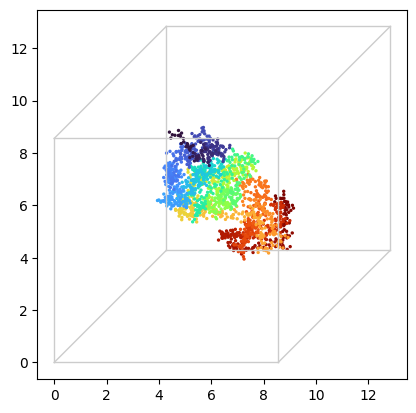

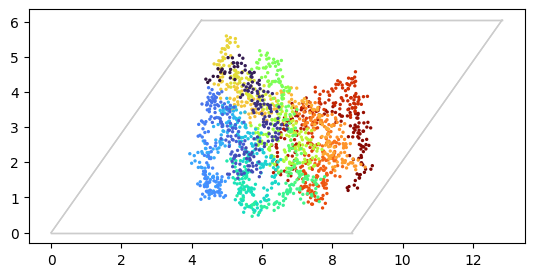

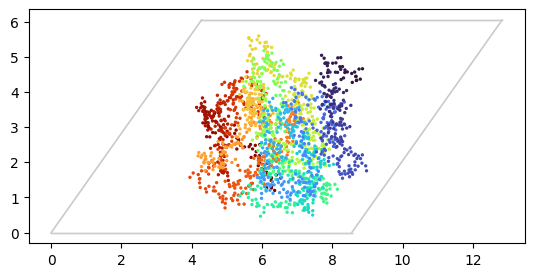

In [12]:
# ============================================
# 7) Reference choice 
# ============================================
ref_sim_index = -3
print("Reference simulation:", F[ref_sim_index])

ref = traj_xyz[ref_sim_index][0].copy()  # (natoms,3) on COMMON atoms

for k in ([0,1], [0,2], [1,2]):
    plt.scatter(*ref[:, k].T, c=-np.arange(len(ref)), cmap='turbo', s=2)
    for e in E:
        plt.plot(*e[:, k].T, c='#ccc', linewidth=1)
    plt.gca().set_aspect('equal')
    plt.show()

In [13]:
# ============================================
# 8) Reference views + alignment (FIXED)
# ============================================

ref_centered = ref - ref[fit].mean(axis=0, keepdims=True)
ref_fit = ref_centered[fit]
ref_fit = ref_fit - ref_fit.mean(axis=0, keepdims=True)  # (nfit,3)

with tim("Aligning ALL trajectories to ONE reference (variable length)"):
    traj_aligned = []
    for xyz in traj_xyz:
        traj_aligned.append(align_traj_to_ref(xyz, fit, ref_fit))


[TIMER] Aligning ALL trajectories to ONE reference (variable length): 51.660 s


[TIMER] RMSD per trajectory (vs own first frame): 14.466 s


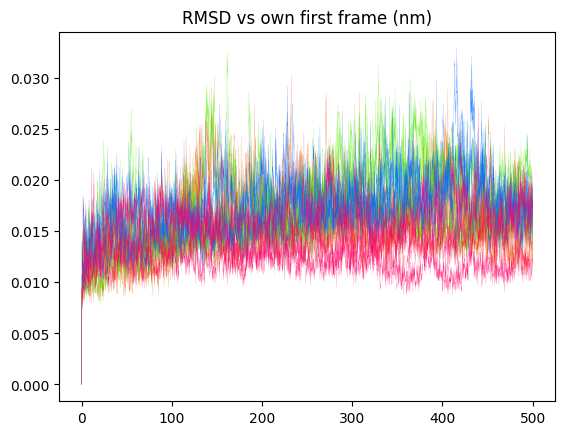

In [14]:
# ============================================
# 9) RMSD vs own first frame (per trajectory)
# ============================================
colors = ('#ee5500', '#55ee00', '#0066ff', '#ff0066')

with tim("RMSD per trajectory (vs own first frame)"):
    rmsd_list = []
    for xyz in traj_aligned:
        x0 = xyz[0, sele]
        dif = xyz[:, sele] - x0[None, :, :]
        r = np.sqrt((dif * dif).sum(axis=(1,2)) / sele.sum()) / 10.0
        rmsd_list.append(r)

for r, c in zip(rmsd_list, np.repeat(colors, 3)):
    t = np.linspace(0, 500, num=len(r))
    plt.plot(t, r, c=c, linewidth=0.1)
plt.title("RMSD vs own first frame (nm)")
plt.show()

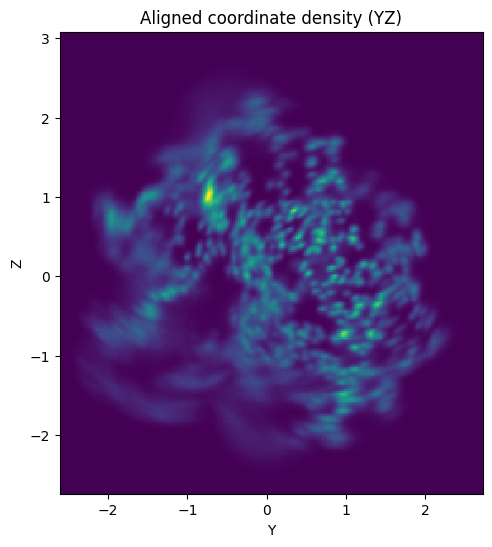

In [15]:
# ============================================
# 10) Plot of all structures aligned (YZ density)
# ============================================
stride_density = 10
YZ_all = []
for xyz in traj_aligned:
    A = xyz[::stride_density, sele, 1:].reshape((-1, 2))
    mask = ~((np.abs(A[:,0]) < 1e-6) & (np.abs(A[:,1]) < 1e-6))
    YZ_all.append(A[mask])
YZ_all = np.vstack(YZ_all)

plt.figure(figsize=(7,6))
plt.hist2d(YZ_all[:,0], YZ_all[:,1], bins=256)
plt.gca().set_aspect('equal')
plt.title("Aligned coordinate density (YZ)")
plt.xlabel("Y")
plt.ylabel("Z")
plt.show()

In [16]:
# ============================================
# 11) RMSF (per traj + overall)
# ============================================
with tim("RMSF per trajectory (variable length)"):
    rmsf_list = []
    for xyz in traj_aligned:
        mean_i = xyz.mean(axis=0, keepdims=True)
        rmsf_i = np.sqrt(((xyz - mean_i)**2).sum(axis=(0,2)) / xyz.shape[0])  # (natoms,)
        rmsf_list.append(rmsf_i)
    rmsf = np.vstack(rmsf_list)
    overall = rmsf.mean(axis=0)

# ============================================
# 11.5) Domain masks
# ============================================
NTL = masks["NTL"]
CTL = masks["CTL"]
CHX = (resids_atom >= 1960) & (resids_atom <= 1975)
PLP = (resids_atom >= 1980) & (resids_atom <= 1990)

[TIMER] RMSF per trajectory (variable length): 9.791 s


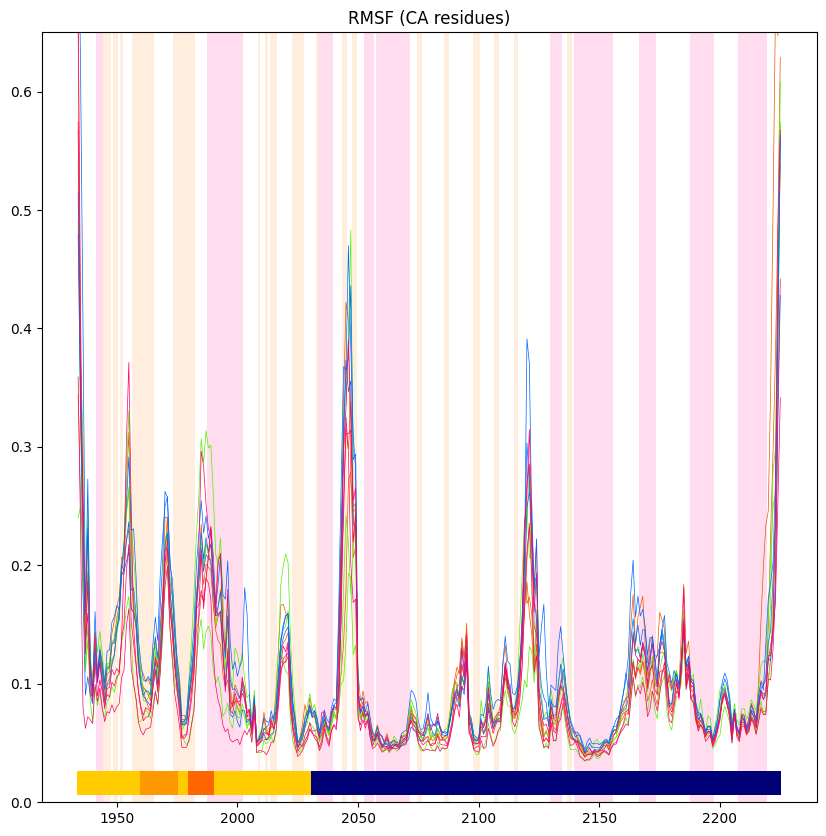

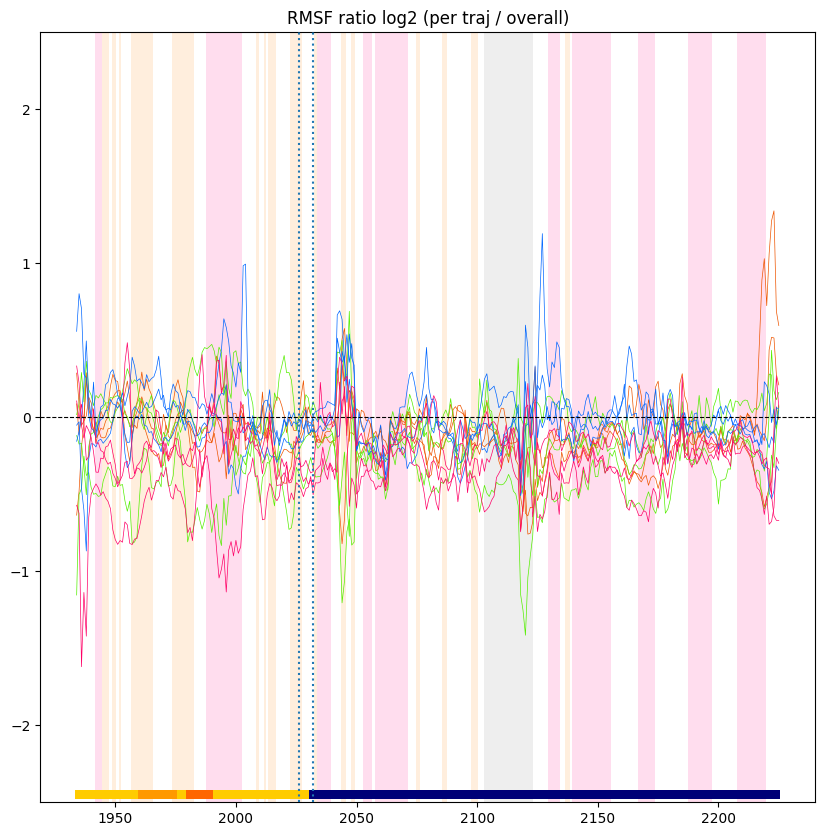

In [17]:
# ============================================
# 12) RMSF plot (CA) + domain band
# ============================================
fig, ax = plt.subplots(figsize=(10, 10))

for s, c in zip(rmsf, np.repeat(colors, 3)):
    ax.plot(resids_atom[CA], s[CA], c=c, linewidth=0.5)

for x, ss in zip(resids_ca, secondary_structure):
    if ss == 'H':
        fc = '#ffddee'
    elif ss == 'E':
        fc = '#ffeedd'
    else:
        fc = 'white'
    ax.add_patch(patches.Rectangle((x - 0.5, 0), 1, 1, facecolor=fc, zorder=0))

ax.set_ylim((0, 0.65))

ymin, ymax = ax.get_ylim()
bar_h = 0.03 * (ymax - ymin)
bar_y = ymin + 0.01 * (ymax - ymin)

for dom_mask, col in ((NTL, '#ffcc00'), (CTL, '#000077'), (CHX, '#ff9900'), (PLP, '#ff6600')):
    dom_ca = np.where(dom_mask & CA)[0]
    if len(dom_ca) == 0:
        continue
    x0 = resids_atom[dom_ca[0]]
    x1 = resids_atom[dom_ca[-1]]
    ax.add_patch(
    patches.Rectangle(
        (x0 - 0.5, bar_y),
        (x1 - x0) + 1,
        bar_h,
        facecolor=col,
        zorder=10
    )
)

plt.title("RMSF (CA residues)")
plt.show()

fig, ax = plt.subplots(figsize=(10, 10))

ratio = rmsf / (overall + 1e-12)   # keep simple broadcasting

ymin, ymax = -2.5, 2.5
ax.set_ylim((ymin, ymax))

for x, ss in zip(resids_ca, secondary_structure):
    fc = '#fde' if ss == 'H' else ('#fed' if ss == 'E' else 'white')
    ax.add_patch(patches.Rectangle((x - 0.5, ymin), 1, ymax - ymin, facecolor=fc, zorder=0))

ax.add_patch(patches.Rectangle((2103, ymin), 20, ymax - ymin, facecolor='#eee', zorder=1))

bar_h = 0.06
bar_y = ymin + 0.02
for dom_mask, col in (NTL, '#ffcc00'), (CTL, '#000077'), (CHX, '#ff9900'), (PLP, '#ff6600'):
    dom_ca = np.where(dom_mask & CA)[0]
    if len(dom_ca) == 0:
        continue
    x0 = resids_atom[dom_ca[0]]
    x1 = resids_atom[dom_ca[-1]]
    ax.add_patch(patches.Rectangle((x0 - 0.5, bar_y), (x1 - x0) + 1, bar_h, facecolor=col, zorder=2))

for s, c in zip(ratio, np.repeat(colors, 3)):
    ax.plot(resids_atom[CA], np.log2(s[CA] + 1e-12), c=c, linewidth=0.5, zorder=5)

ax.axvline(2026, linestyle=':', zorder=6)
ax.axvline(2032, linestyle=':', zorder=6)
ax.axhline(0, color='k', linestyle='--', linewidth=0.8, zorder=6)

plt.title("RMSF ratio log2 (per traj / overall)")
plt.show()




## Global Kinase PCA (ACT-IN)

Principal component analysis was performed on backbone atoms of the kinase domain including the activation loop.  

This analysis captures global conformational motions of the kinase domain and allows comparison of mutant conformational sampling in a reduced dimensional space.

[TIMER] Vectorizing aligned conformations deviations from mean (PCA, variable length): 28.956 s
X shape: (55356, 3264)
[TIMER] Diagonalization (PCA): 8.001 s


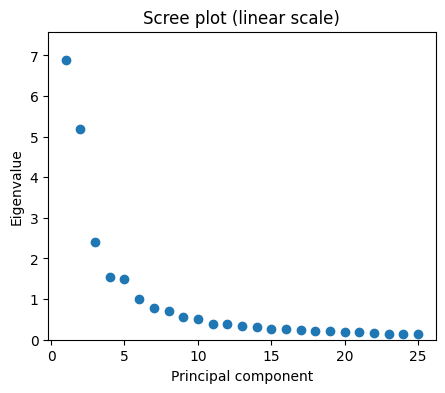

[TIMER] Projections (scores) on first 10 components, scaled to RMSD: 0.884 s


In [18]:
# ============================================
# PCA (Whole kinase incl activation loop) – variable length correct
# ============================================
with tim("Vectorizing aligned conformations deviations from mean (PCA, variable length)"):
    all_frames = []
    for xyz in traj_aligned:
        all_frames.append(traj_frames_atoms(xyz, sele))
    all_frames = np.vstack(all_frames)
    mean = all_frames.mean(axis=0)   # (d,)
    d = mean.size

    P_list = []
    X_list = []
    P_owner = []
    X_owner = []

    for ti, xyz in enumerate(traj_aligned):
        dev = traj_frames_atoms(xyz, sele) - mean
        split_idx = int(0.8 * dev.shape[0])

        P_i = dev[:split_idx]
        X_i = dev[split_idx:]

        if P_i.shape[0]:
            P_list.append(P_i)
            P_owner.append(np.full(P_i.shape[0], ti, dtype=int))
        if X_i.shape[0]:
            X_list.append(X_i)
            X_owner.append(np.full(X_i.shape[0], ti, dtype=int))

    P = np.vstack(P_list) if len(P_list) else np.zeros((0, d))
    X = np.vstack(X_list) if len(X_list) else np.zeros((0, d))
    P_owner = np.concatenate(P_owner) if len(P_owner) else np.zeros((0,), dtype=int)
    X_owner = np.concatenate(X_owner) if len(X_owner) else np.zeros((0,), dtype=int)

print("X shape:", X.shape)

with tim("Diagonalization (PCA)"):
    C = X.T @ (X / len(X))
    evals, loadings = np.linalg.eigh(C)
    idx = np.argsort(evals)[::-1]
    evals = evals[idx]
    loadings = loadings[:, idx]
    
    # scree plot
plot_scree(evals, n=25, title="Scree plot (linear scale)")

ncomponents = 10
scale = np.sqrt(mean.size)

with tim(f"Projections (scores) on first {ncomponents} components, scaled to RMSD"):
    pscores_flat = (P @ loadings[:, :ncomponents]) / scale
    scores_flat  = (X @ loadings[:, :ncomponents]) / scale


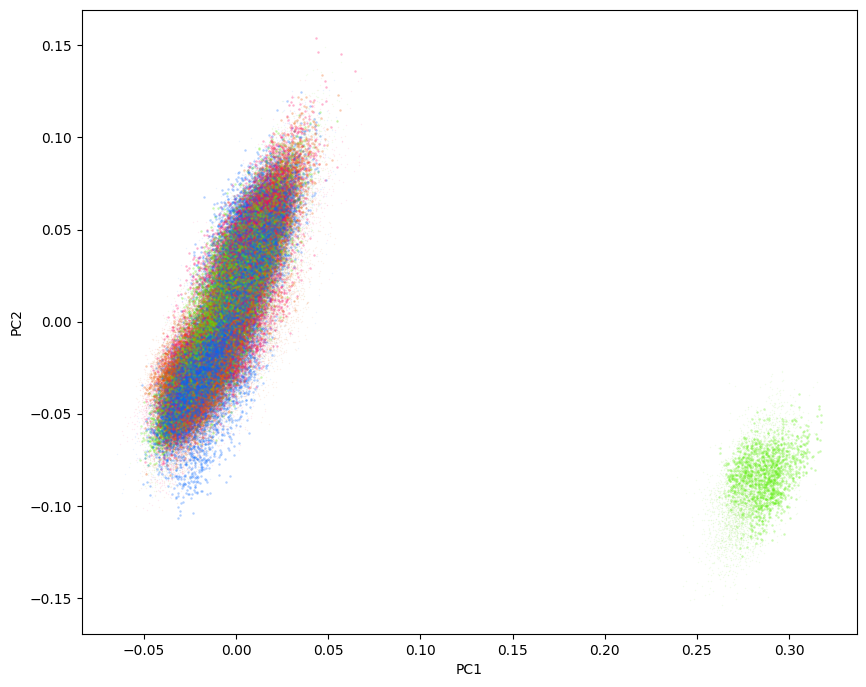

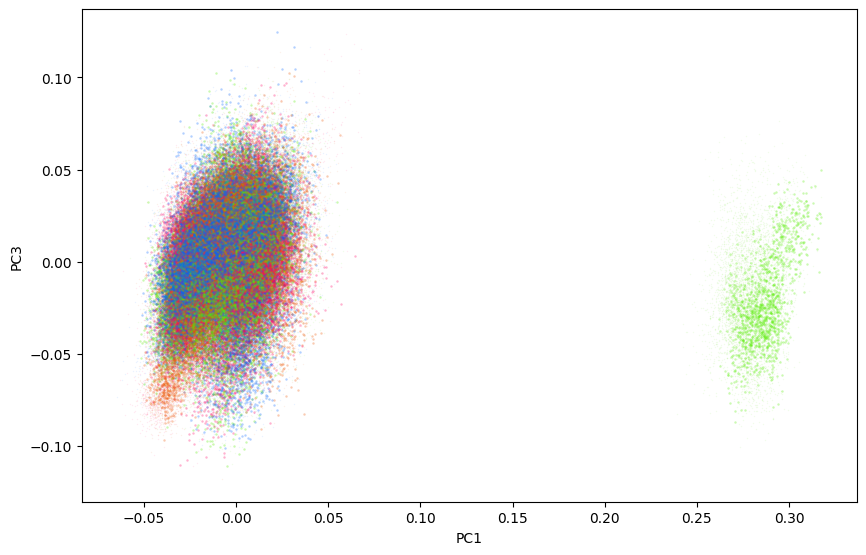

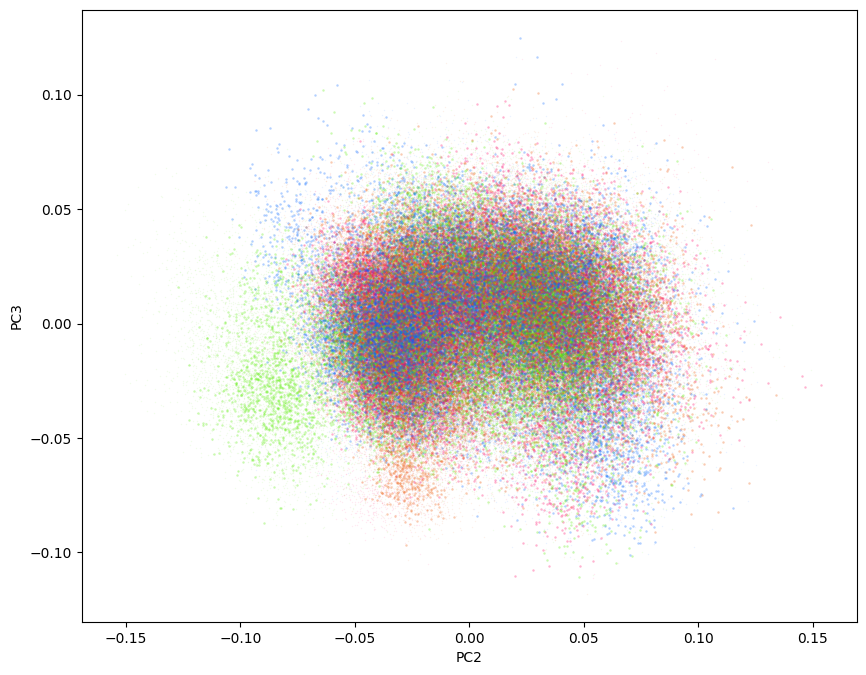

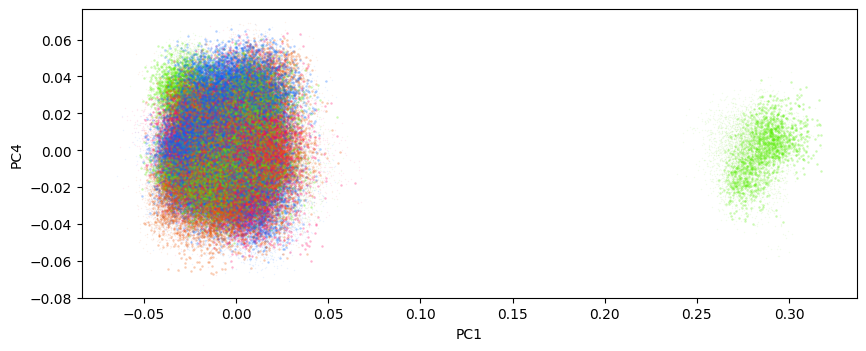

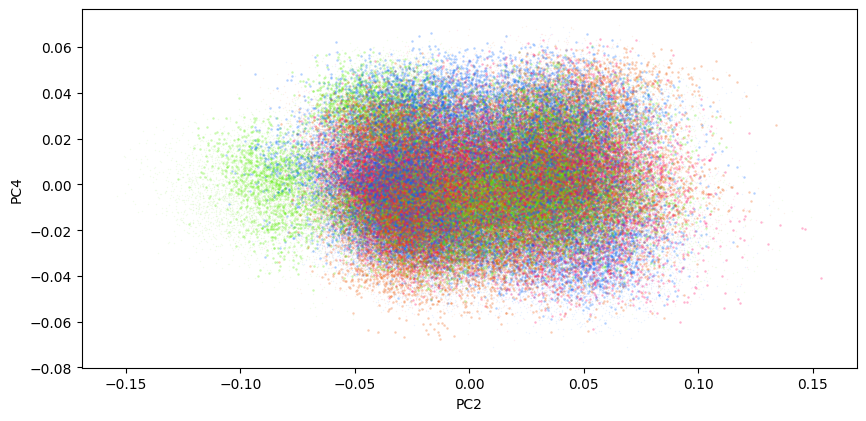

In [19]:
# ============================================
# Colored per mutant scatter (same style)
# ============================================
traj_colors = np.repeat(np.array(colors), nrep, axis=0)
traj_colors = np.tile(traj_colors, int(np.ceil(len(F) / len(traj_colors))))[:len(F)]

stride = 1
pairs = [(0,1), (0,2), (1,2), (0,3), (1,3)]

for a, b in pairs:
    fig, ax = plt.subplots(figsize=(10, 10))

    # early (P): faint
    for ti in range(len(F)):
        mask = (P_owner == ti)
        Zi = pscores_flat[mask]
        ax.scatter(Zi[::stride, a], Zi[::stride, b],
                   s=1, c=[traj_colors[ti]], alpha=0.08, linewidths=0)

    # production (X): stronger
    for ti in range(len(F)):
        mask = (X_owner == ti)
        Zi = scores_flat[mask]
        ax.scatter(Zi[::stride, a], Zi[::stride, b],
                   s=3, c=[traj_colors[ti]], alpha=0.30, linewidths=0)

    ax.set_aspect('equal', adjustable='box')
    ax.set_xlabel(f"PC{a+1}")
    ax.set_ylabel(f"PC{b+1}")
    plt.show()

## Conformational State Clustering

Density-based clustering was applied to PCA coordinates to identify recurrent conformational states sampled during simulations.

Cluster occupancy was then computed for each mutant to quantify differences in conformational preferences.

ACT-IN HDBSCAN clusters: 2
ACT-IN HDBSCAN noise fraction: 0.0
ACT-IN DBSCAN clusters: 2
ACT-IN DBSCAN noise fraction: 0.001372931570200159
ACT-IN occupancy (HDBSCAN primary):


state,0,1
mutant,,
C2060G,0.0,1.0
D1988N,0.0,1.0
D2033N,0.0,1.0
D2113G,0.0,1.0
D2113N,0.0,1.0
E1935G,0.0,1.0
E1990G,0.0,1.0
E2020K,0.0,1.0
E2131Q,0.0,1.0


ACT-IN occupancy (DBSCAN baseline):


state,-1,0,1
mutant,,,
C2060G,0.000416,0.999584,0.000000
D1988N,0.000000,1.000000,0.000000
D2033N,0.003747,0.996253,0.000000
D2113G,0.000000,1.000000,0.000000
D2113N,0.000000,1.000000,0.000000
E1935G,0.002235,0.997765,0.000000
E1990G,0.000000,1.000000,0.000000
E2020K,0.000000,1.000000,0.000000
E2131Q,0.000000,1.000000,0.000000


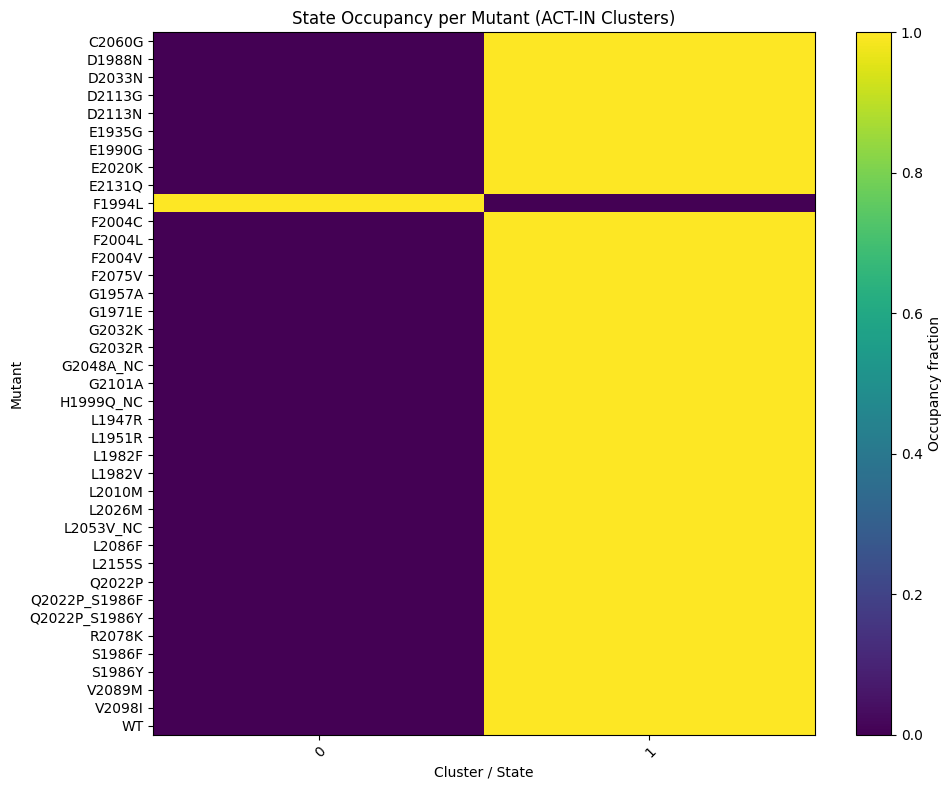

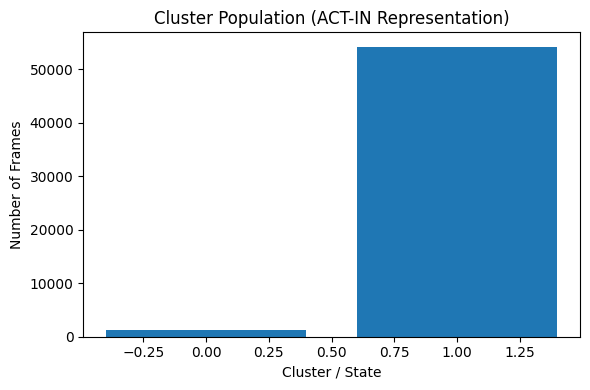

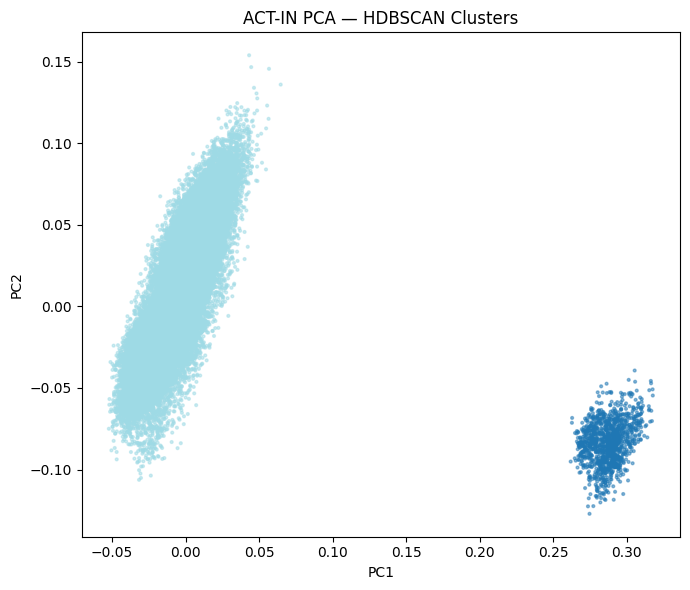

In [20]:
# ============================================================
# ACT-IN clustering + occupancy + heatmap
# ============================================================

ACT_IN_CLUSTER = run_cluster_panel_varlen(
    scores_flat=scores_flat,
    x_owner=X_owner,
    F=F,
    prefix="actin",
    title_prefix="ACT-IN",
    n_pcs=5,
    min_cluster_size=200,
    eps=0.9,
    min_samples=60,
    run_hdbscan=run_hdbscan,
    run_dbscan=run_dbscan,
    plot_occupancy_heatmap=plot_occupancy_heatmap,
    plot_cluster_population=plot_cluster_population,
    plot_pca_clusters=plot_pca_clusters,
    display_fn=display,
)


### Saved ACT-IN Results

Key outputs from the ACT-IN PCA analysis were stored in a dictionary for later reuse in clustering, visualization, and downstream interpretation.

In [21]:
PCA_ACT_IN = {
    "mean": mean.copy(),
    "loadings": loadings.copy(),
    "pscores": pscores_flat.copy(),
    "scores": scores_flat.copy(),
    "P_owner": P_owner.copy(),
    "X_owner": X_owner.copy(),
    "F": np.array(F, dtype=object),
    "sele": sele.copy(),
    "cluster_results": ACT_IN_CLUSTER,
}

## Global Kinase PCA (ACT-OUT)

To focus on the rigid core of the kinase domain, PCA was repeated excluding the activation loop.

Removing the activation loop reduces noise caused by its high flexibility and highlights global domain motions of the kinase core.

ACT-OUT sele atoms: 984 fit atoms: 984
[TIMER] ACT-OUT: aligning all trajectories on fit: 57.805 s


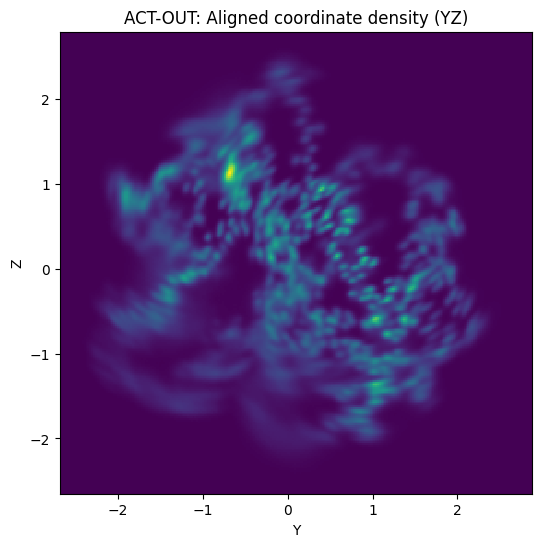

[TIMER] ACT-OUT: vectorizing deviations + building P/X: 27.128 s
ACT-OUT X shape: (55356, 2952)
[TIMER] ACT-OUT: PCA diagonalization: 4.942 s


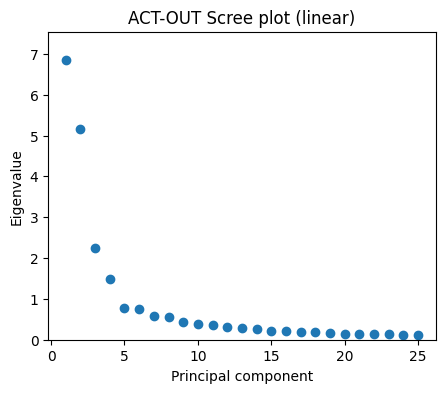

ACT-OUT cumulative variance (first 25):
[0.26 0.45 0.54 0.6  0.62 0.65 0.67 0.7  0.71 0.73 0.74 0.75 0.76 0.77
 0.78 0.79 0.8  0.8  0.81 0.82 0.82 0.83 0.83 0.84 0.84]
[TIMER] ACT-OUT: projections on first 10 PCs: 0.668 s


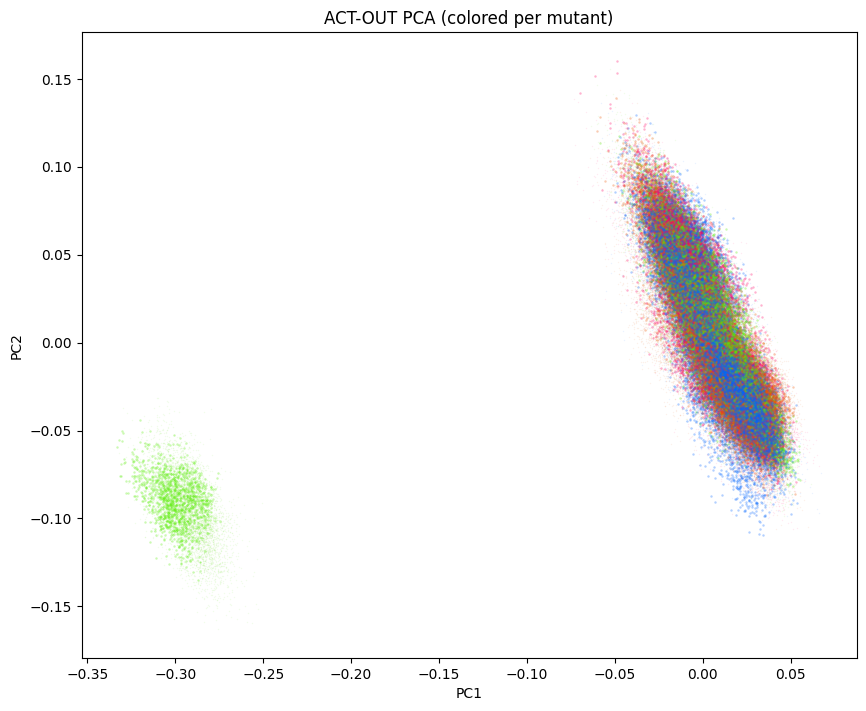

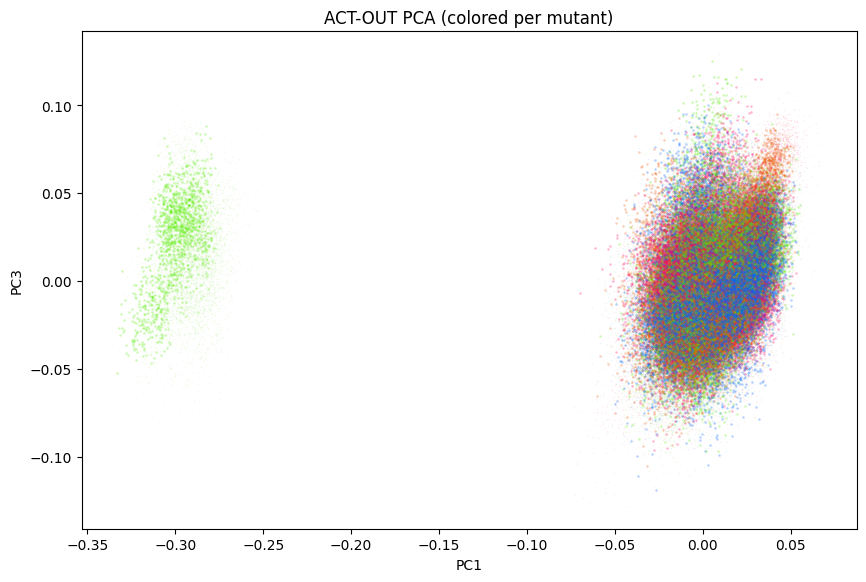

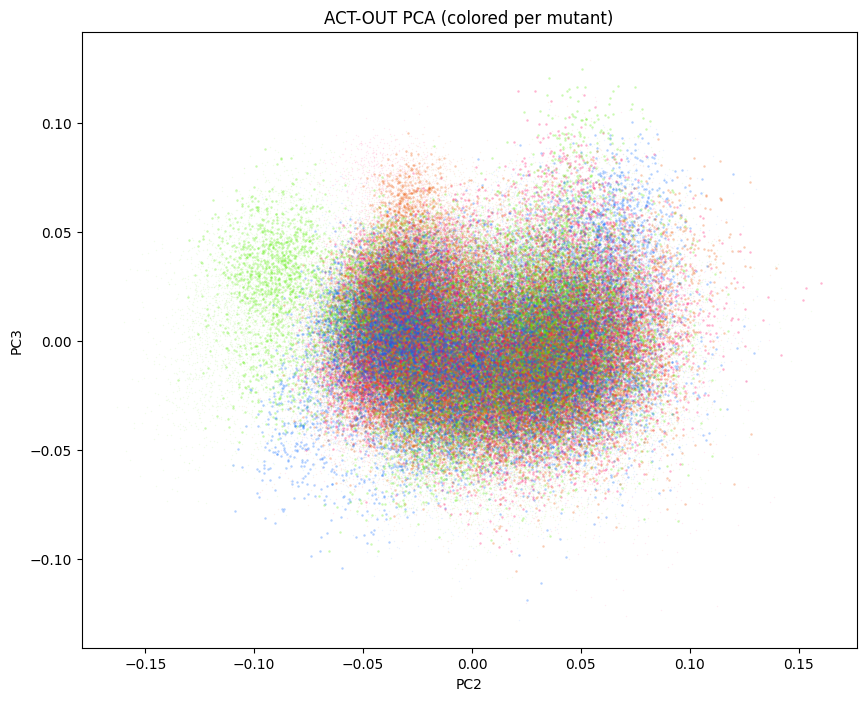

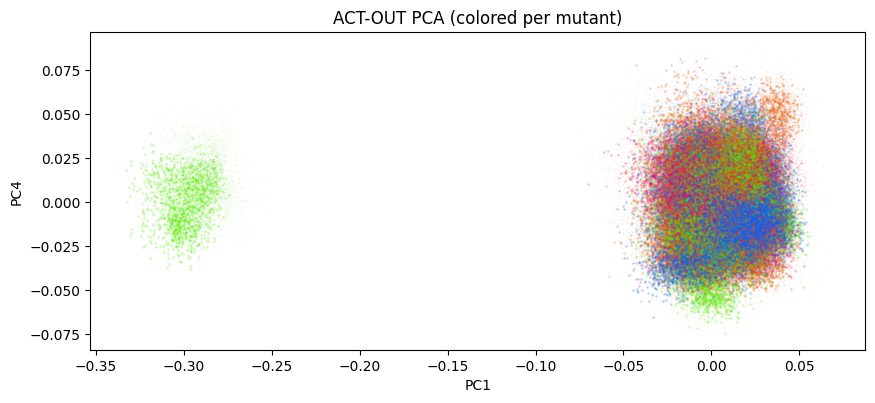

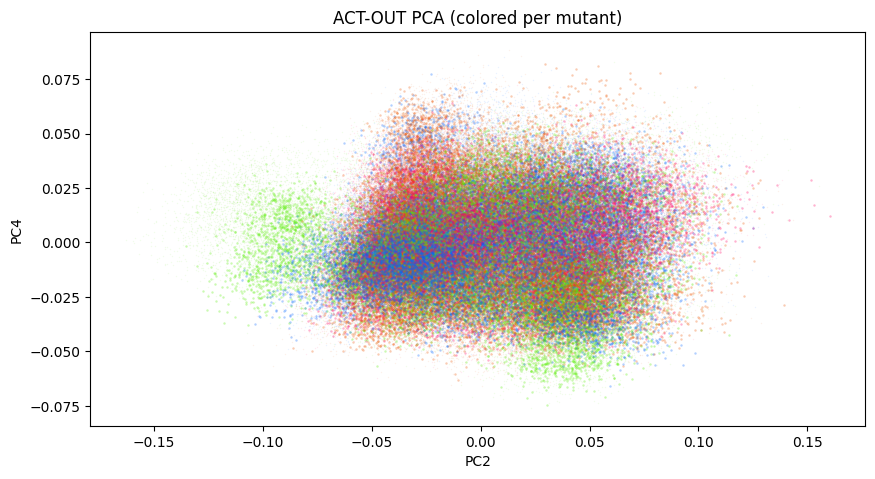

In [22]:
# ============================================================
# PCA on the whole kinase (ACT excluded)
# ============================================================

ACT = masks["ACT"]
BB = masks["BB"]
BODY = masks["BODY"]

sele_actout = combine_masks(BB, BODY, ~ACT)
fit_actout  = sele_actout

print("ACT-OUT sele atoms:", int(sele_actout.sum()), "fit atoms:", int(fit_actout.sum()))

# ---- 3) Re-align trajectories for this PCA selection ----
ref_actout_centered = ref_centered.copy()
ref_fit_actout = ref_actout_centered[fit_actout]
ref_fit_actout = ref_fit_actout - ref_fit_actout.mean(axis=0, keepdims=True)


with tim("ACT-OUT: aligning all trajectories on fit"):
    traj_actout = [align_traj_to_ref_by_fit(xyz, fit_actout, ref_fit_actout) for xyz in traj_aligned]

# ---- 4) Aligned coordinate density ----
plt.figure(figsize=(7,6))
A = []
for xyz in traj_actout:
    a = xyz[:, sele_actout, 1:].reshape((-1, 2))  # YZ
    mask = ~((np.abs(a[:, 0]) < 1e-6) & (np.abs(a[:, 1]) < 1e-6))
    A.append(a[mask])
A = np.vstack(A)

plt.hist2d(A[:, 0], A[:, 1], bins=256)
plt.gca().set_aspect("equal")
plt.title("ACT-OUT: Aligned coordinate density (YZ)")
plt.xlabel("Y")
plt.ylabel("Z")
plt.show()

# ---- 5) Vectorizing deviations and split per trajectory (variable length) ----
with tim("ACT-OUT: vectorizing deviations + building P/X"):
    # building global mean on selected atoms over ALL frames from ALL trajectories
    all_frames = []
    for xyz in traj_actout:
        all_frames.append(traj_frames_atoms(xyz, sele_actout))
    all_frames = np.vstack(all_frames)

    mean_actout = all_frames.mean(axis=0)   # (d,)
    d = mean_actout.size

    P_list, X_list = [], []
    P_owner, X_owner_list = [], []

    for ti, xyz in enumerate(traj_actout):
        dev = traj_frames_atoms(xyz, sele_actout) - mean_actout
        split_idx = int(0.8 * dev.shape[0])

        P_i = dev[:split_idx]
        X_i = dev[split_idx:]

        if P_i.shape[0]:
            P_list.append(P_i)
            P_owner.append(np.full(P_i.shape[0], ti, dtype=int))
        if X_i.shape[0]:
            X_list.append(X_i)
            X_owner_list.append(np.full(X_i.shape[0], ti, dtype=int))

    P_actout = np.vstack(P_list) if len(P_list) else np.zeros((0, d))
    X_actout = np.vstack(X_list) if len(X_list) else np.zeros((0, d))
    P_owner_actout = np.concatenate(P_owner) if len(P_owner) else np.zeros((0,), dtype=int)
    X_owner_actout = np.concatenate(X_owner_list) if len(X_owner_list) else np.zeros((0,), dtype=int)

print("ACT-OUT X shape:", X_actout.shape)

# ---- 6) PCA diagonalization ----
with tim("ACT-OUT: PCA diagonalization"):
    C = X_actout.T @ (X_actout / len(X_actout))
    evals_actout, loadings_actout = np.linalg.eigh(C)
    idx = np.argsort(evals_actout)[::-1]
    evals_actout = evals_actout[idx]
    loadings_actout = loadings_actout[:, idx]

# ---- 7) Scree ----
plot_scree(evals_actout, n=25, title="ACT-OUT Scree plot (linear)")

print("ACT-OUT cumulative variance (first 25):")
print(np.round(np.cumsum(evals_actout[:25]) / evals_actout.sum(), 2))

# ---- 8) PCA projections ----
ncomponents = 10
scale = np.sqrt(mean_actout.size)

with tim(f"ACT-OUT: projections on first {ncomponents} PCs"):
    pscores_flat_actout = (P_actout @ loadings_actout[:, :ncomponents]) / scale
    scores_flat_actout  = (X_actout @ loadings_actout[:, :ncomponents]) / scale

# ---- 9) colored per mutant scatter EXACTLY ----
traj_colors = np.repeat(np.array(colors), nrep, axis=0)
traj_colors = np.tile(traj_colors, int(np.ceil(len(F) / len(traj_colors))))[:len(F)]

stride = 1
pairs = [(0,1), (0,2), (1,2), (0,3), (1,3)]

for a, b in pairs:
    fig, ax = plt.subplots(figsize=(10, 10))

    # early (P): faint
    for ti in range(len(F)):
        m = (P_owner_actout == ti)
        Zi = pscores_flat_actout[m]
        ax.scatter(
            Zi[::stride, a], Zi[::stride, b],
            s=1, c=[traj_colors[ti]], alpha=0.08, linewidths=0
        )

    # production (X): stronger
    for ti in range(len(F)):
        m = (X_owner_actout == ti)
        Zi = scores_flat_actout[m]
        ax.scatter(
            Zi[::stride, a], Zi[::stride, b],
            s=3, c=[traj_colors[ti]], alpha=0.30, linewidths=0
        )

    ax.set_aspect("equal", adjustable="box")
    ax.set_xlabel(f"PC{a+1}")
    ax.set_ylabel(f"PC{b+1}")
    plt.title("ACT-OUT PCA (colored per mutant)")
    plt.show()

ACT-OUT HDBSCAN clusters: 2
ACT-OUT HDBSCAN noise fraction: 0.0
ACT-OUT DBSCAN clusters: 2
ACT-OUT DBSCAN noise fraction: 0.002890382253052966
ACT-OUT occupancy (HDBSCAN primary):


state,0,1
mutant,,
C2060G,1.0,0.0
D1988N,1.0,0.0
D2033N,1.0,0.0
D2113G,1.0,0.0
D2113N,1.0,0.0
E1935G,1.0,0.0
E1990G,1.0,0.0
E2020K,1.0,0.0
E2131Q,1.0,0.0


ACT-OUT occupancy (DBSCAN baseline):


state,-1,0,1
mutant,,,
C2060G,0.010408,0.989592,0.000000
D1988N,0.000000,1.000000,0.000000
D2033N,0.003331,0.996669,0.000000
D2113G,0.000000,1.000000,0.000000
D2113N,0.000000,1.000000,0.000000
E1935G,0.000000,1.000000,0.000000
E1990G,0.000000,1.000000,0.000000
E2020K,0.000000,1.000000,0.000000
E2131Q,0.020781,0.979219,0.000000


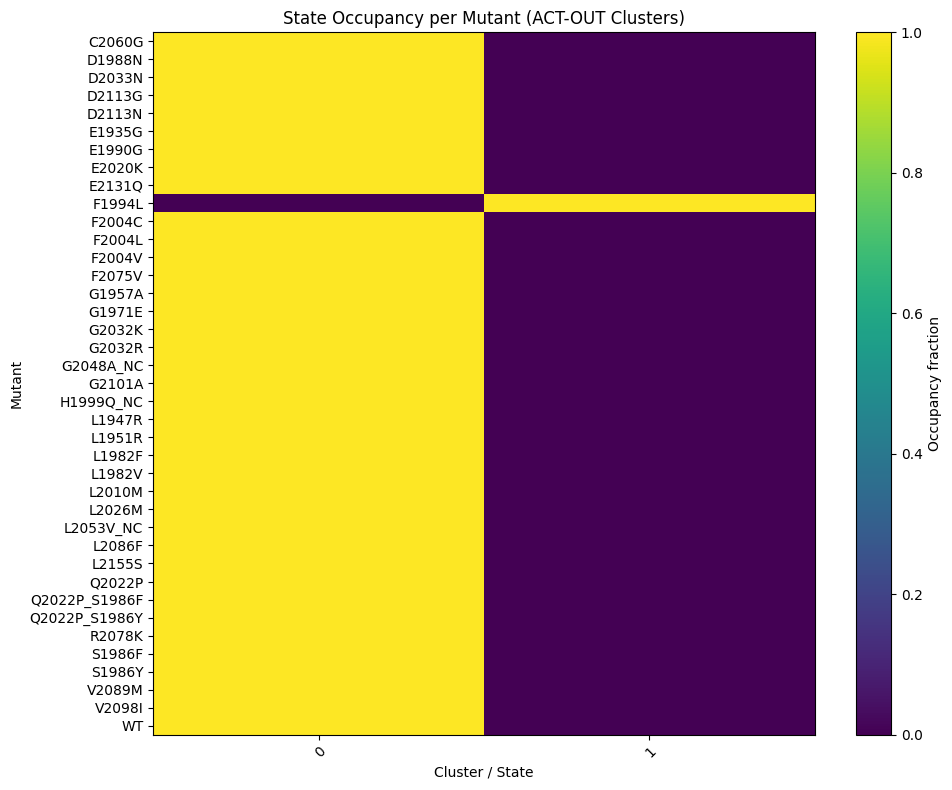

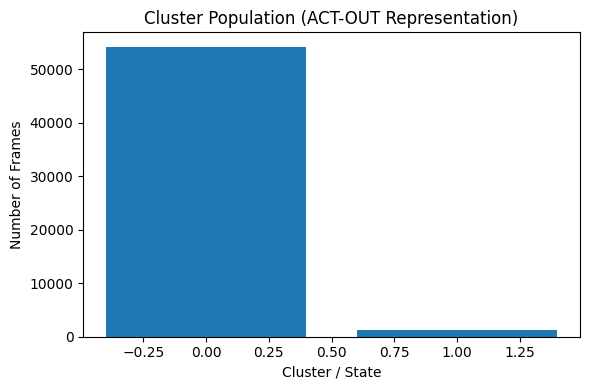

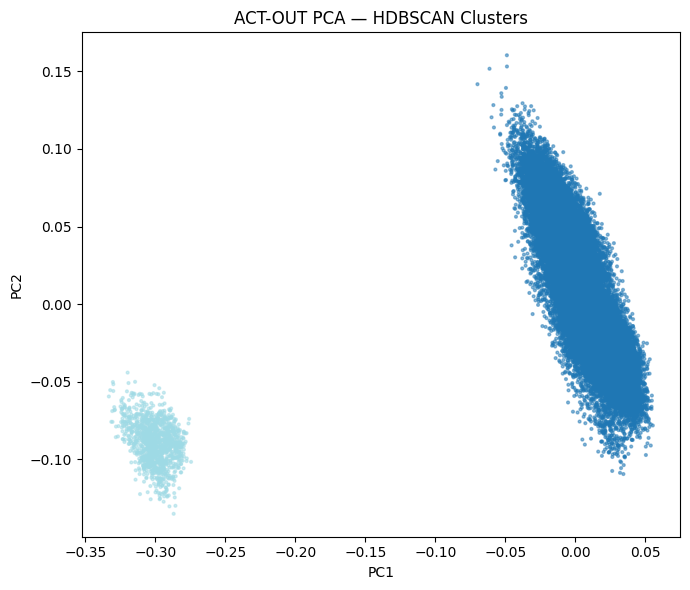

In [23]:
# ============================================================
# ACT-OUT clustering + occupancy + heatmap
# ============================================================

ACT_OUT_CLUSTER = run_cluster_panel_varlen(
    scores_flat=scores_flat_actout,
    x_owner=X_owner_actout,
    F=F,
    prefix="actout",
    title_prefix="ACT-OUT",
    n_pcs=5,
    min_cluster_size=200,
    eps=0.9,
    min_samples=60,
    run_hdbscan=run_hdbscan,
    run_dbscan=run_dbscan,
    plot_occupancy_heatmap=plot_occupancy_heatmap,
    plot_cluster_population=plot_cluster_population,
    plot_pca_clusters=plot_pca_clusters,
    display_fn=display,
)


## N-terminal Lobe PCA (NTL)

Principal component analysis was performed on the N-terminal lobe (NTL) of the kinase domain to isolate conformational variability specific to this regulatory region.

By aligning and analyzing the NTL separately, this section captures mutation-dependent changes in local lobe dynamics that may be masked in whole-kinase PCA.

NTL sele atoms: 388 fit atoms: 388
[TIMER] NTL: aligning all trajectories on fit: 29.509 s


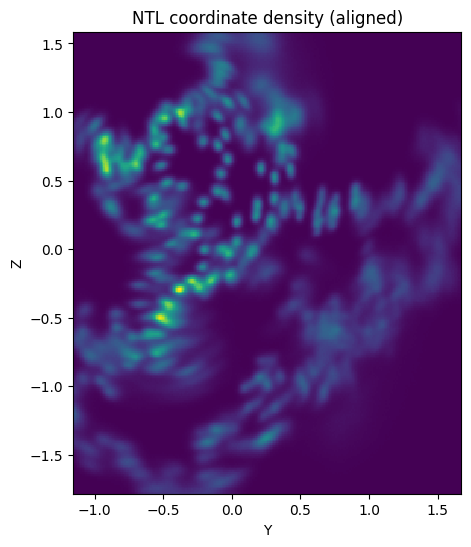

[TIMER] NTL: plotting aligned coordinate density: 18.736 s
[TIMER] NTL: vectorizing deviations + building P/X: 8.575 s
NTL X shape: (55356, 1164)
[TIMER] NTL: diagonalization: 0.768 s


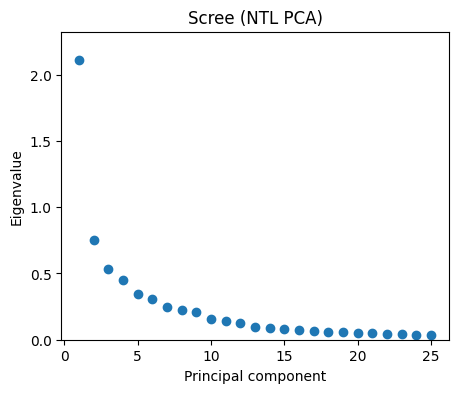

Cumulative variance (top 25):
[0.29 0.39 0.46 0.52 0.57 0.61 0.64 0.67 0.7  0.72 0.74 0.76 0.77 0.78
 0.79 0.8  0.81 0.82 0.83 0.84 0.84 0.85 0.85 0.86 0.87]
[TIMER] NTL: projections on first 10 PCs (scaled to RMSD-like): 0.298 s


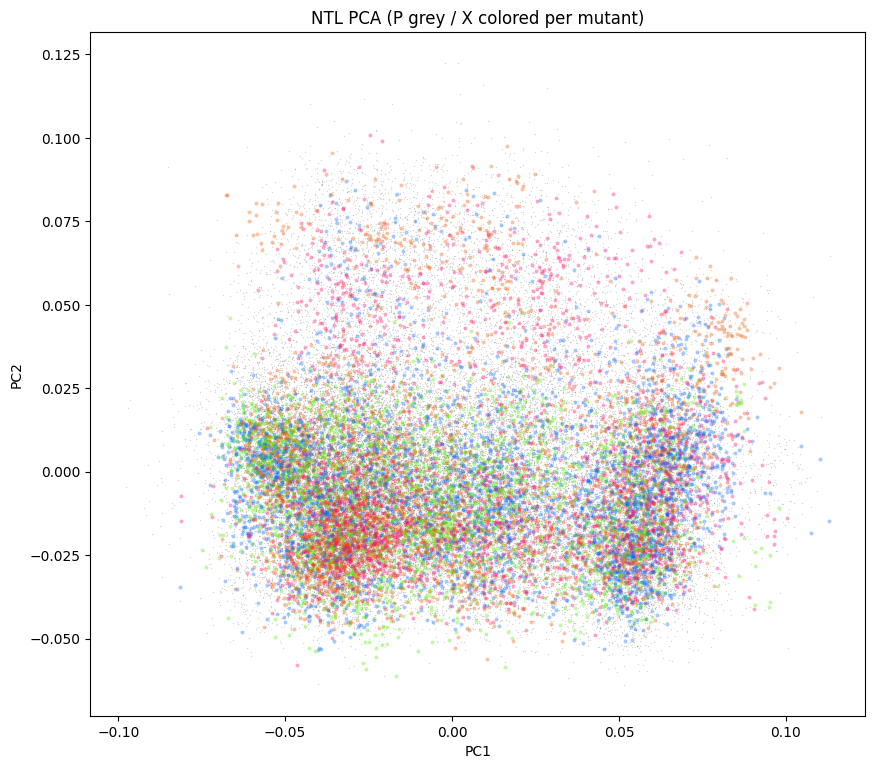

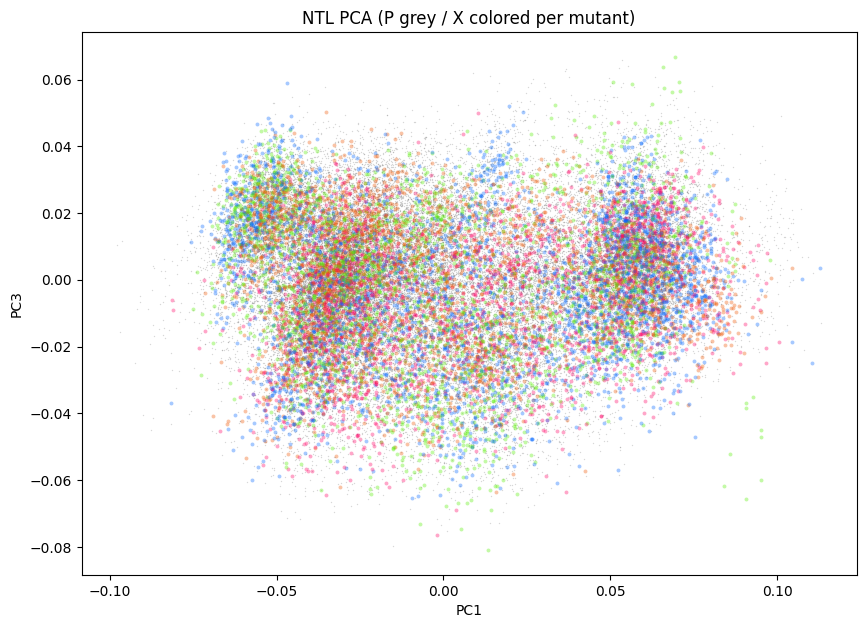

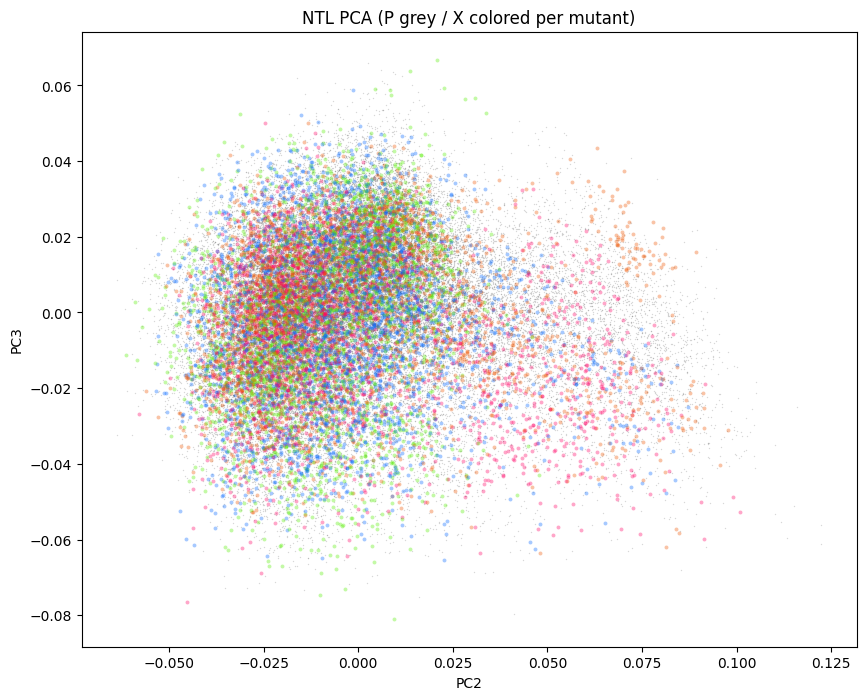

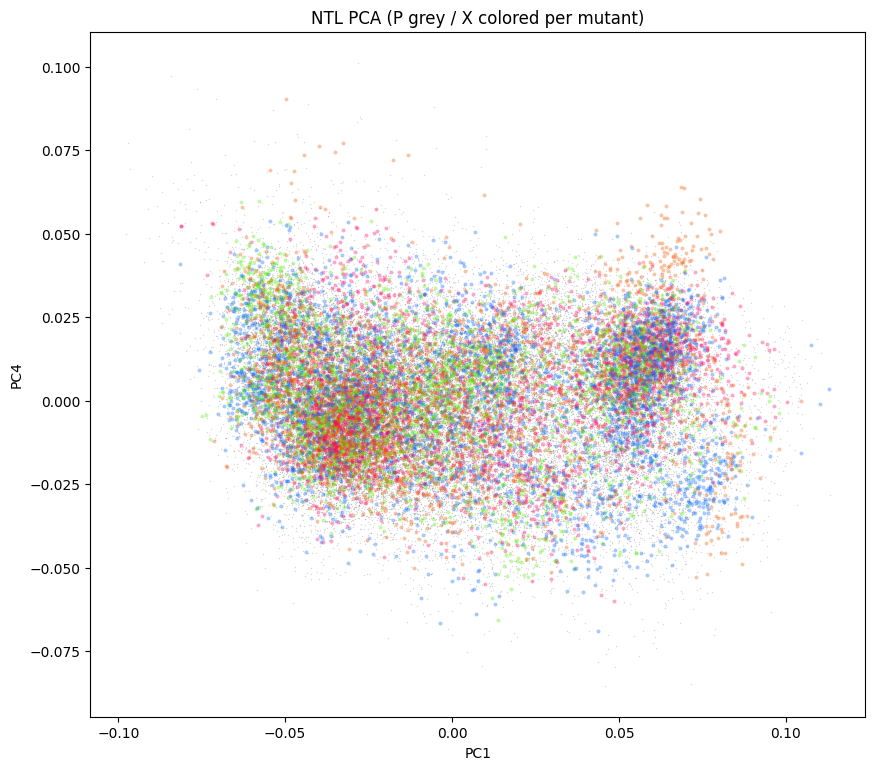

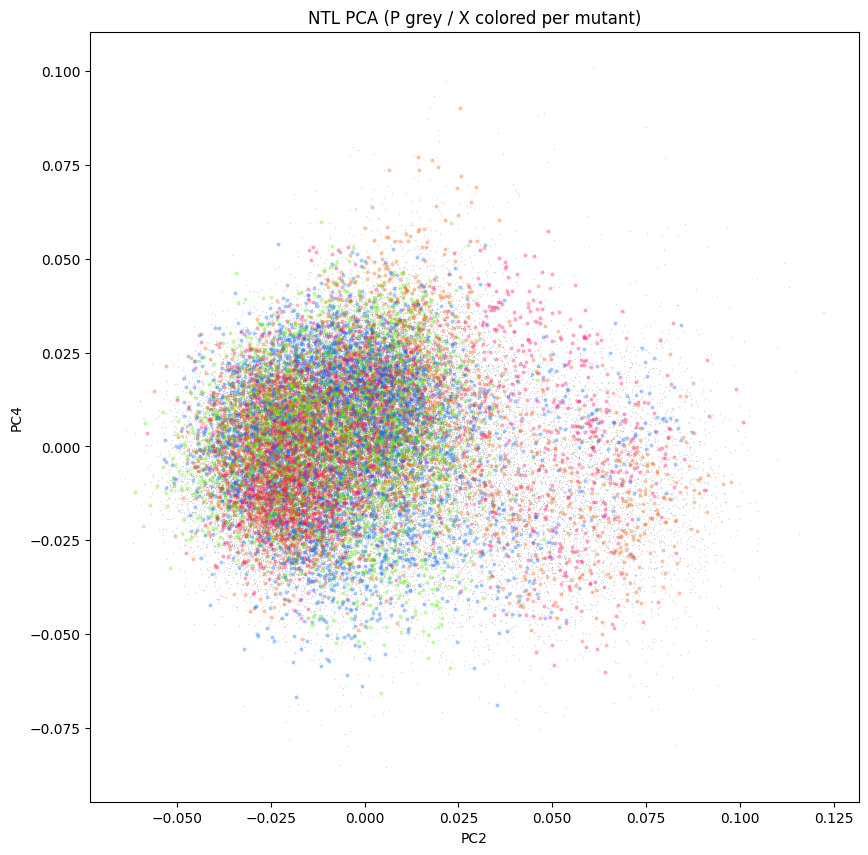

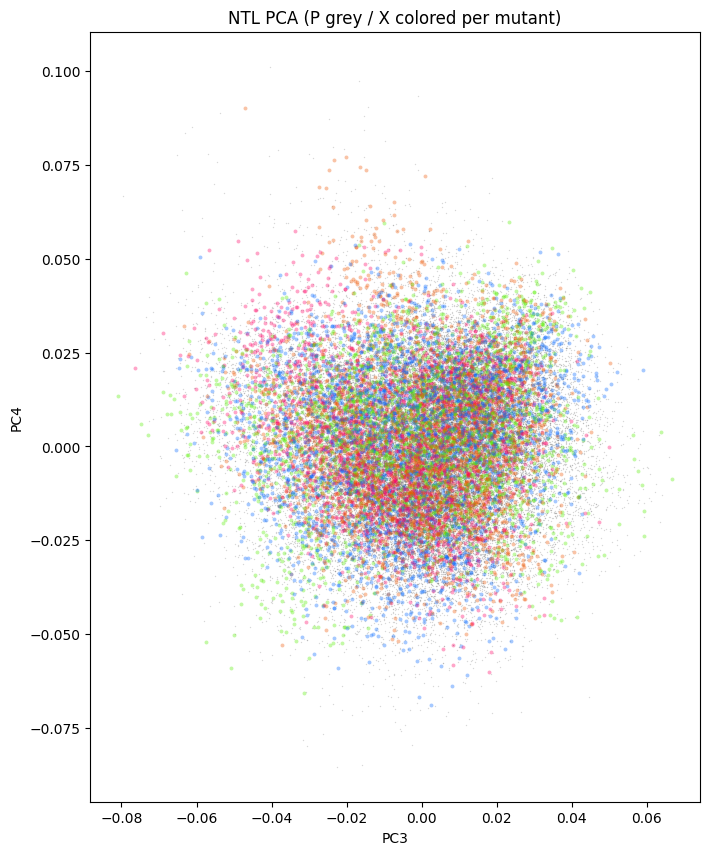

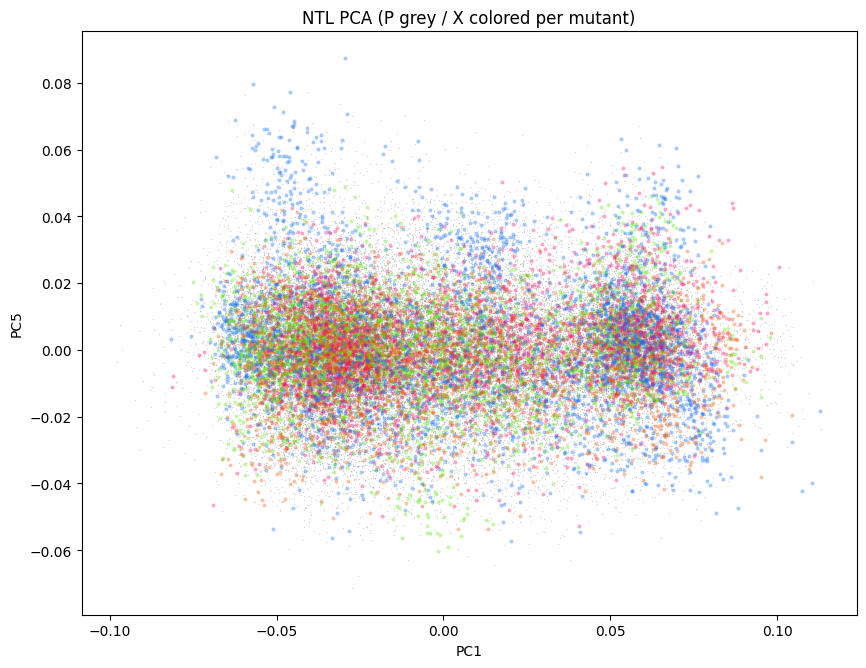

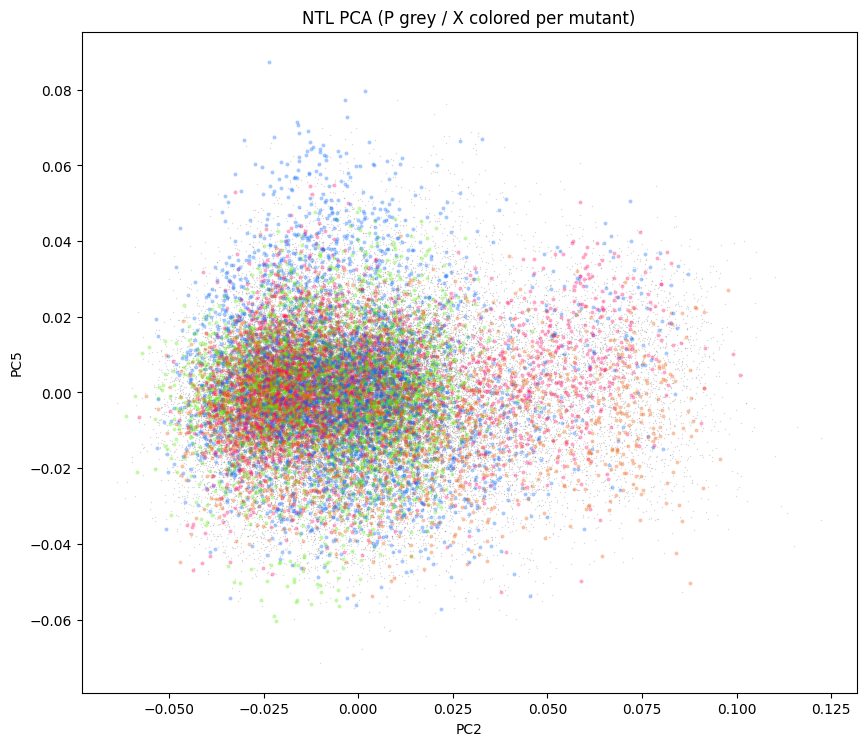

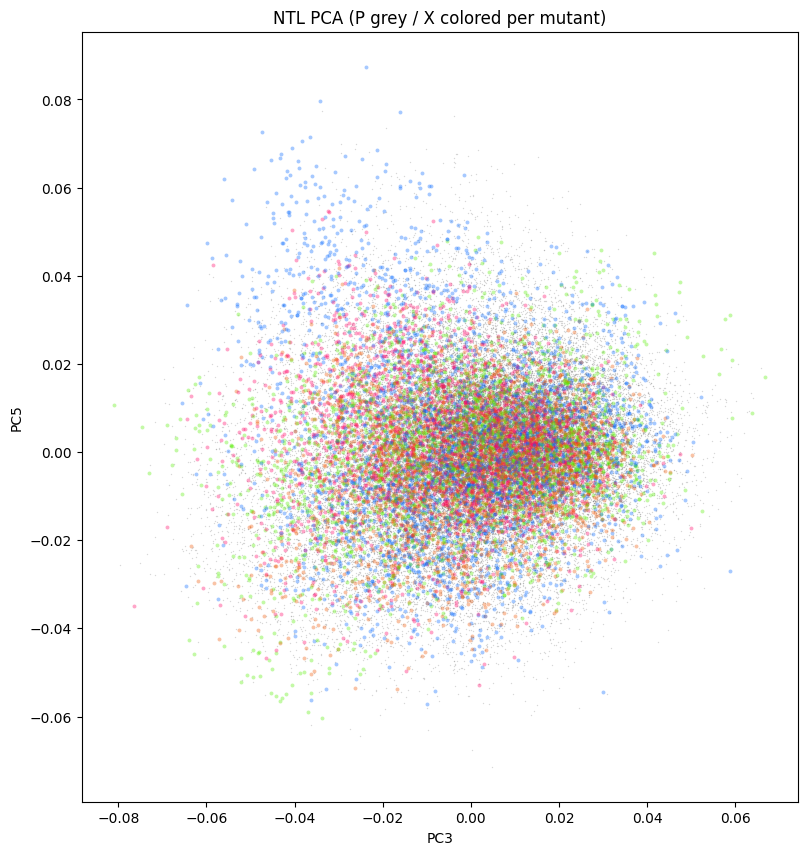

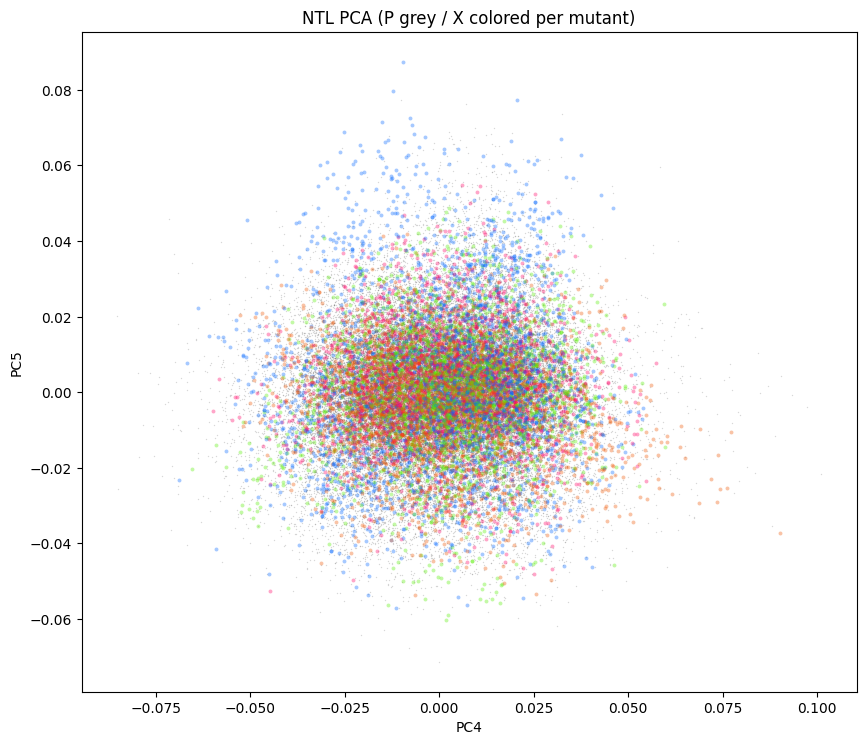

In [24]:
# ============================================================
# NTL PCA
# ============================================================

eps = 1e-6

# -----------------------------
# 0) Selection masks (atom-level)
# -----------------------------
NTL = masks["NTL"]
BB = masks["BB"]

sele_ntl = combine_masks(BB, NTL)
fit_ntl  = sele_ntl

print("NTL sele atoms:", int(sele_ntl.sum()), "fit atoms:", int(fit_ntl.sum()))

# -----------------------------
# 1) Align each trajectory on NTL fit
# -----------------------------
ref_fit_ntl = ref_centered[fit_ntl]
ref_fit_ntl = ref_fit_ntl - ref_fit_ntl.mean(axis=0, keepdims=True)

with tim("NTL: aligning all trajectories on fit"):
    traj_ntl = [align_traj_to_ref_by_fit(xyz, fit_ntl, ref_fit_ntl) for xyz in traj_aligned]

# -----------------------------
# 2) Plot aligned coordinate density (YZ) with auto-zoom
# -----------------------------
with tim("NTL: plotting aligned coordinate density"):
    A = []
    for xyz in traj_ntl:
        a = xyz[:, sele_ntl, 1:].reshape((-1, 2)).astype(np.float32)  # YZ
        mask = ~((np.abs(a[:, 0]) < eps) & (np.abs(a[:, 1]) < eps))
        A.append(a[mask])
    A = np.vstack(A)

    y0, y1 = np.percentile(A[:, 0], [1, 99])
    z0, z1 = np.percentile(A[:, 1], [1, 99])

    plt.figure(figsize=(7, 6))
    plt.hist2d(A[:, 0], A[:, 1], bins=256, range=[[y0, y1], [z0, z1]])
    plt.gca().set_aspect("equal")
    plt.title("NTL coordinate density (aligned)")
    plt.xlabel("Y")
    plt.ylabel("Z")
    plt.show()

# -----------------------------
# 3) Vectorize deviations + split per trajectory (variable length)
# -----------------------------
with tim("NTL: vectorizing deviations + building P/X"):
    # global mean over ALL frames (selected atoms only)
    all_frames = []
    for xyz in traj_ntl:
        all_frames.append(traj_frames_atoms(xyz, sele_ntl))
    all_frames = np.vstack(all_frames)

    mean_ntl = all_frames.mean(axis=0)   # (d,)
    d = mean_ntl.size

    P_list, X_list = [], []
    P_owner, X_owner = [], []

    for ti, xyz in enumerate(traj_ntl):
        dev = traj_frames_atoms(xyz, sele_ntl) - mean_ntl
        split_idx = int(0.8 * dev.shape[0])   # per-trajectory split

        P_i = dev[:split_idx]
        X_i = dev[split_idx:]

        if P_i.shape[0]:
            P_list.append(P_i)
            P_owner.append(np.full(P_i.shape[0], ti, dtype=int))
        if X_i.shape[0]:
            X_list.append(X_i)
            X_owner.append(np.full(X_i.shape[0], ti, dtype=int))

    P = np.vstack(P_list) if len(P_list) else np.zeros((0, d))
    X = np.vstack(X_list) if len(X_list) else np.zeros((0, d))
    P_owner = np.concatenate(P_owner) if len(P_owner) else np.zeros((0,), dtype=int)
    X_owner = np.concatenate(X_owner) if len(X_owner) else np.zeros((0,), dtype=int)

print("NTL X shape:", X.shape)

# -----------------------------
# 4) PCA diagonalization (eigh on covariance)
# -----------------------------
with tim("NTL: diagonalization"):
    C = X.T @ (X / len(X))
    evals, loadings = np.linalg.eigh(C)
    order = np.argsort(evals)[::-1]
    evals = evals[order]
    loadings = loadings[:, order]

plot_scree(evals, n=25, title="Scree (NTL PCA)")

print("Cumulative variance (top 25):")
print(np.round(np.cumsum(evals[:25]) / evals.sum(), 2))

# -----------------------------
# 5) Projections (scores)
# -----------------------------
ncomponents = 10
scale = np.sqrt(mean_ntl.size)

with tim(f"NTL: projections on first {ncomponents} PCs (scaled to RMSD-like)"):
    pscores_flat = (P @ loadings[:, :ncomponents]) / scale
    scores_flat  = (X @ loadings[:, :ncomponents]) / scale

# color per trajectory (same color for 3 replicas)
ntraj = len(F)
traj_colors = np.repeat(np.array(colors), nrep, axis=0)
traj_colors = np.tile(traj_colors, int(np.ceil(ntraj / len(traj_colors))))[:ntraj]

stride = 5
pairs = [(0,1), (0,2), (1,2), (0,3), (1,3), (2,3), (0,4), (1,4), (2,4), (3,4)]

for a, b in pairs:
    fig, ax = plt.subplots(figsize=(10, 10))

    # early frames (P): grey
    ax.scatter(
        pscores_flat[::stride, a], pscores_flat[::stride, b],
        c="#666", s=1, alpha=0.25, linewidths=0
    )

    # production frames (X): colored per trajectory
    for ti in range(ntraj):
        m = (X_owner == ti)
        Zi = scores_flat[m]
        ax.scatter(
            Zi[::stride, a], Zi[::stride, b],
            s=8, c=[traj_colors[ti]], alpha=0.35, linewidths=0
        )

    ax.set_aspect("equal", adjustable="box")
    ax.set_xlabel(f"PC{a+1}")
    ax.set_ylabel(f"PC{b+1}")
    plt.title("NTL PCA (P grey / X colored per mutant)")
    plt.show()

## C-terminal Lobe PCA (CTL)

Principal component analysis was performed on the C-terminal lobe (CTL) of the kinase domain, excluding the activation loop.

This analysis focuses on structural variability within the more rigid catalytic lobe and allows comparison of mutant-dependent conformational shifts in the kinase core.

CTL sele atoms: 675 fit atoms: 675
[TIMER] CTL: aligning all trajectories on fit: 34.768 s


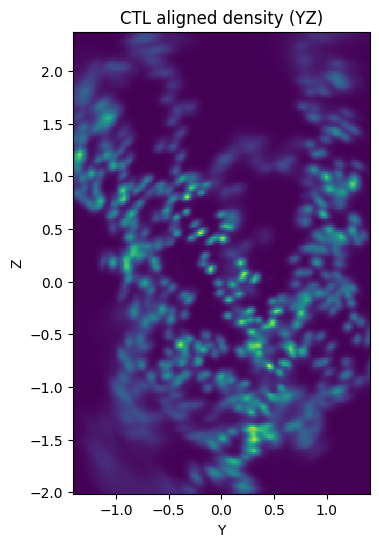

[TIMER] CTL: plotting aligned coordinate density (YZ): 32.505 s
[TIMER] CTL: vectorizing deviations + building P/X: 16.447 s
CTL X shape: (55356, 2025)
[TIMER] CTL: diagonalization: 2.504 s


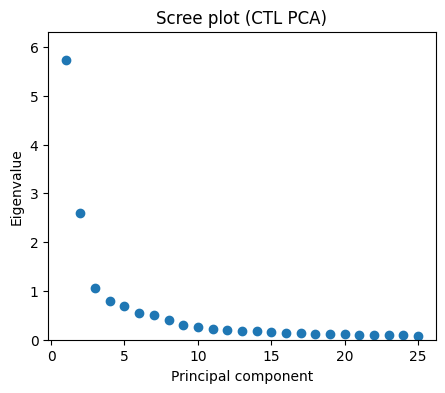

Cumulative variance (top 25):
[0.33 0.48 0.54 0.58 0.62 0.65 0.68 0.7  0.72 0.74 0.75 0.76 0.77 0.78
 0.79 0.8  0.81 0.81 0.82 0.83 0.83 0.84 0.84 0.85 0.85]
[TIMER] CTL: projections on first 10 PCs (scaled RMSD-like): 0.494 s


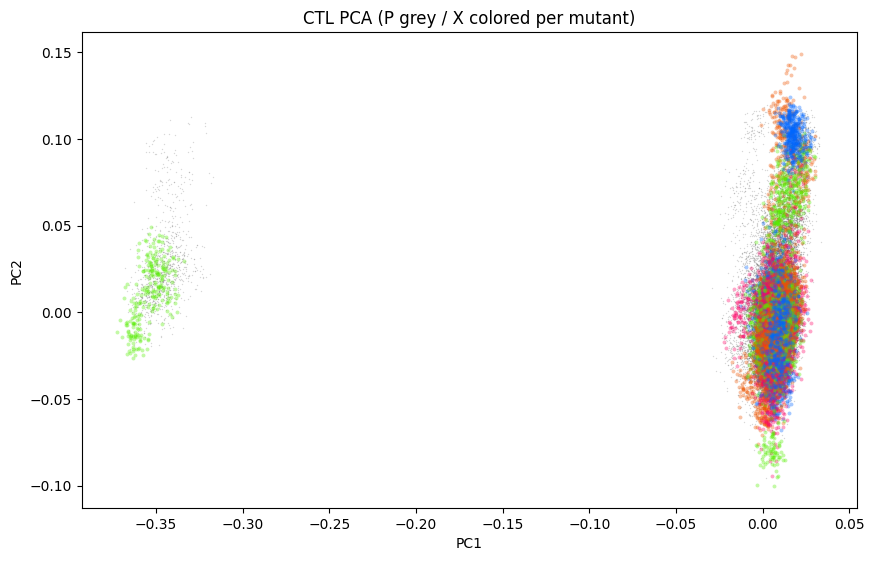

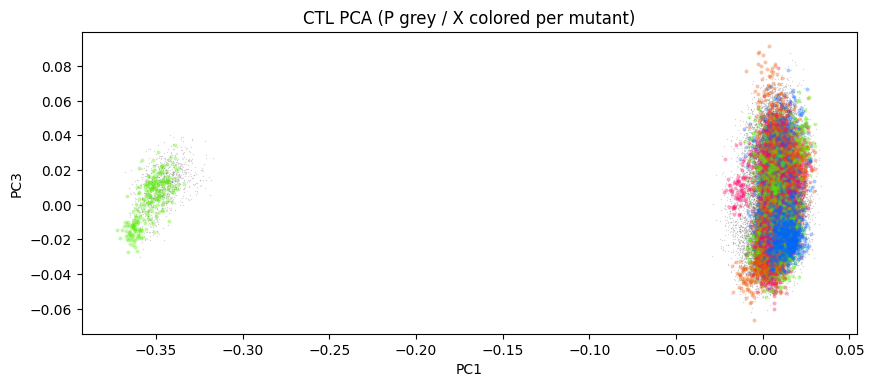

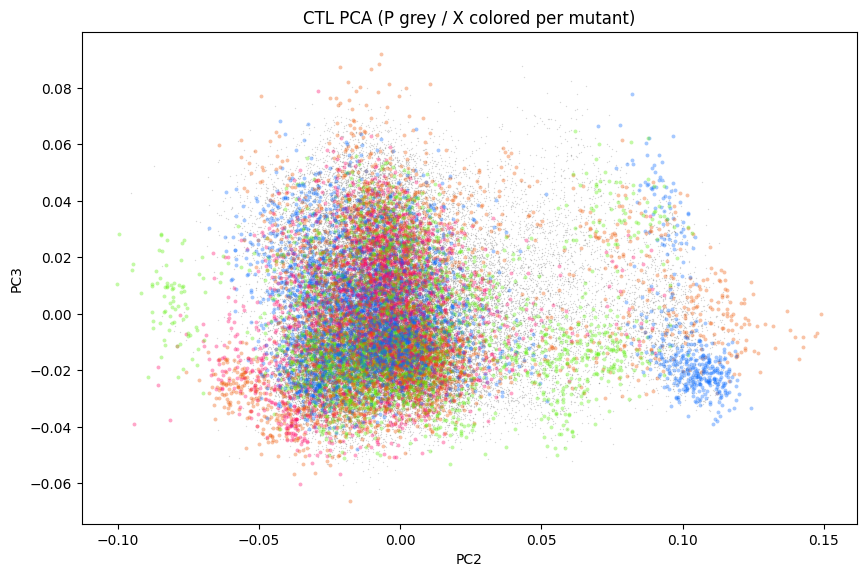

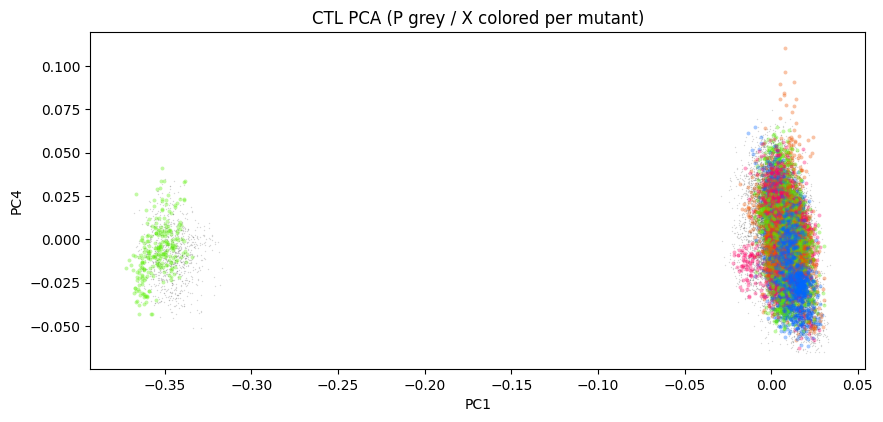

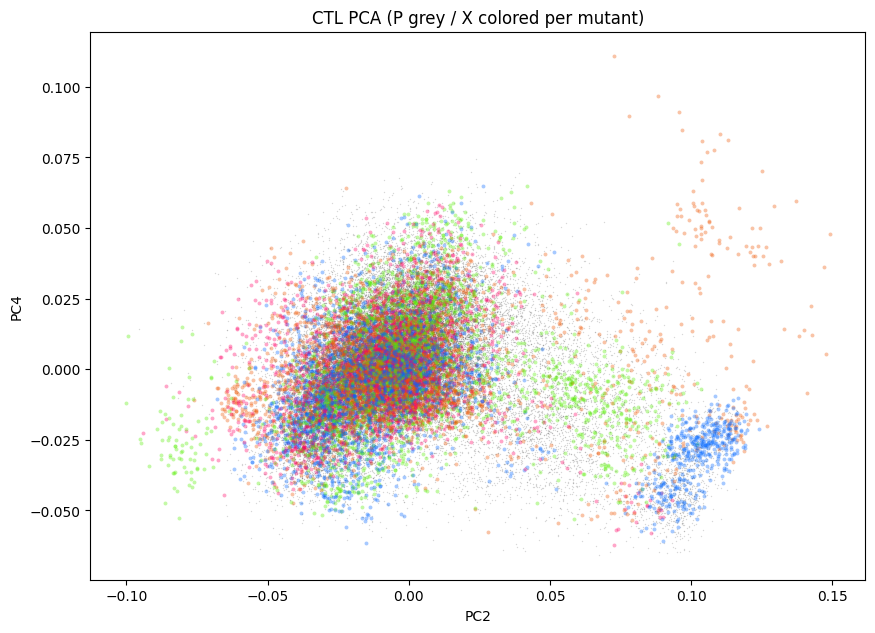

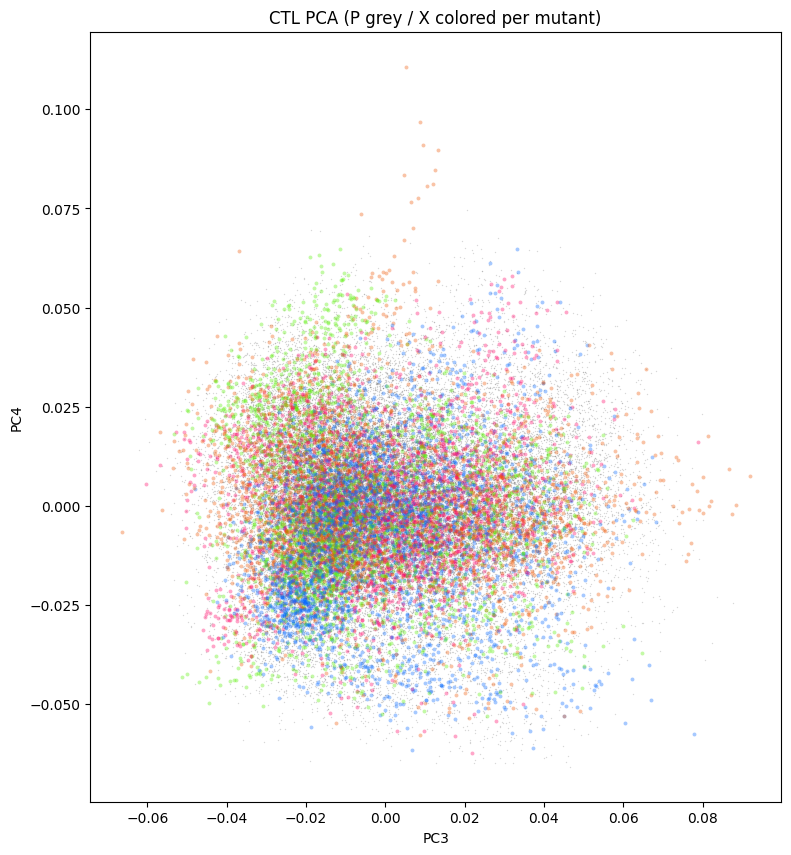

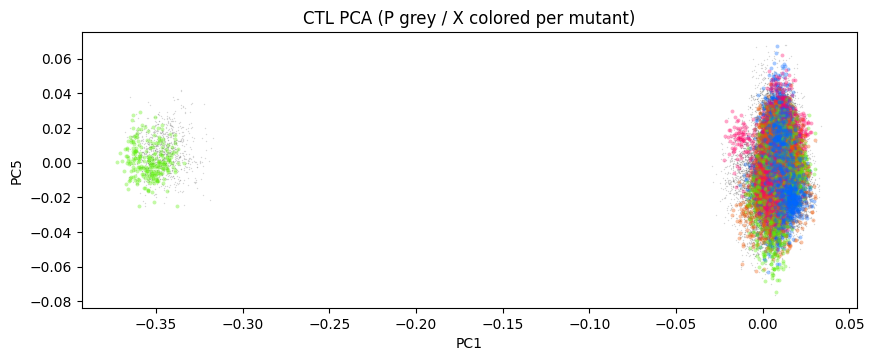

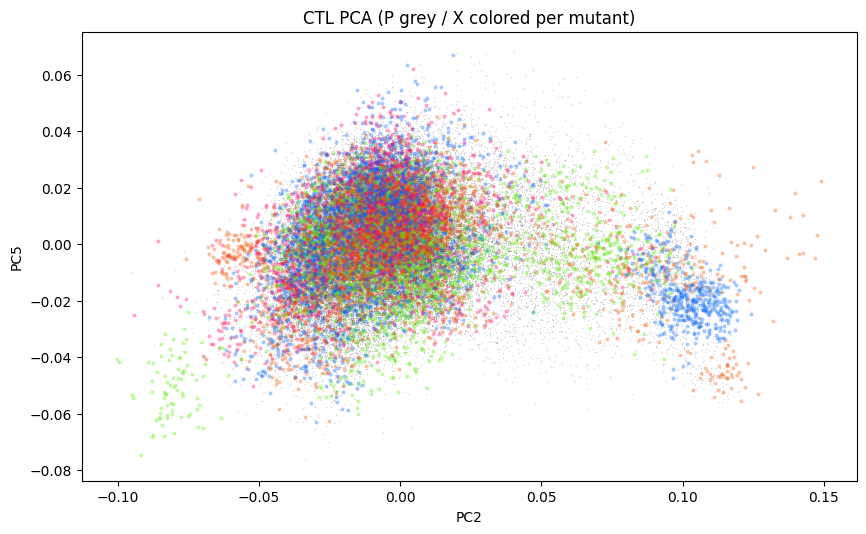

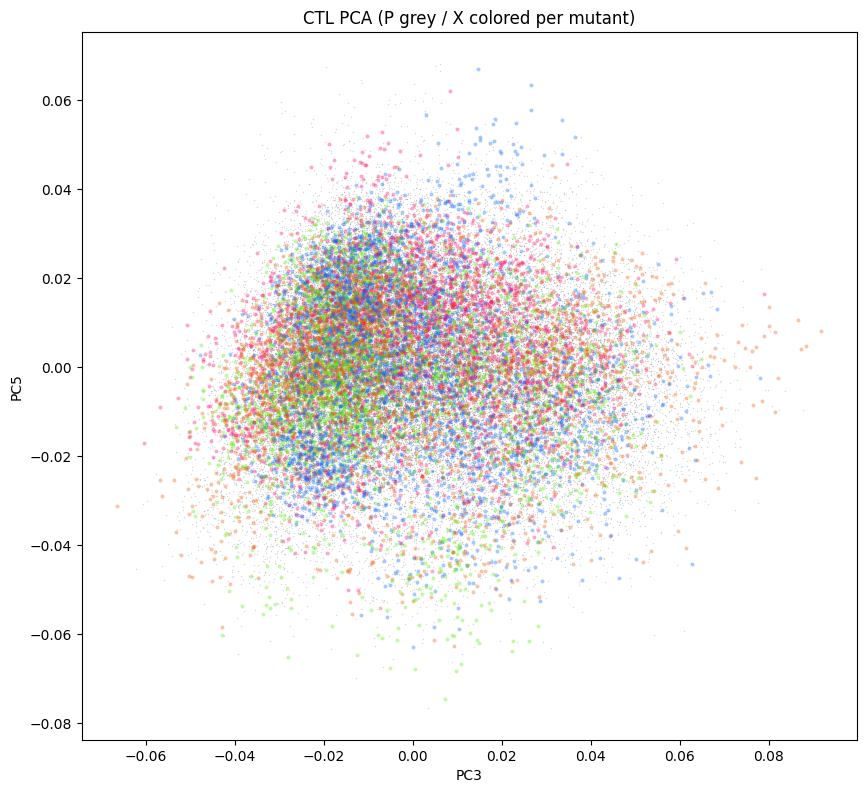

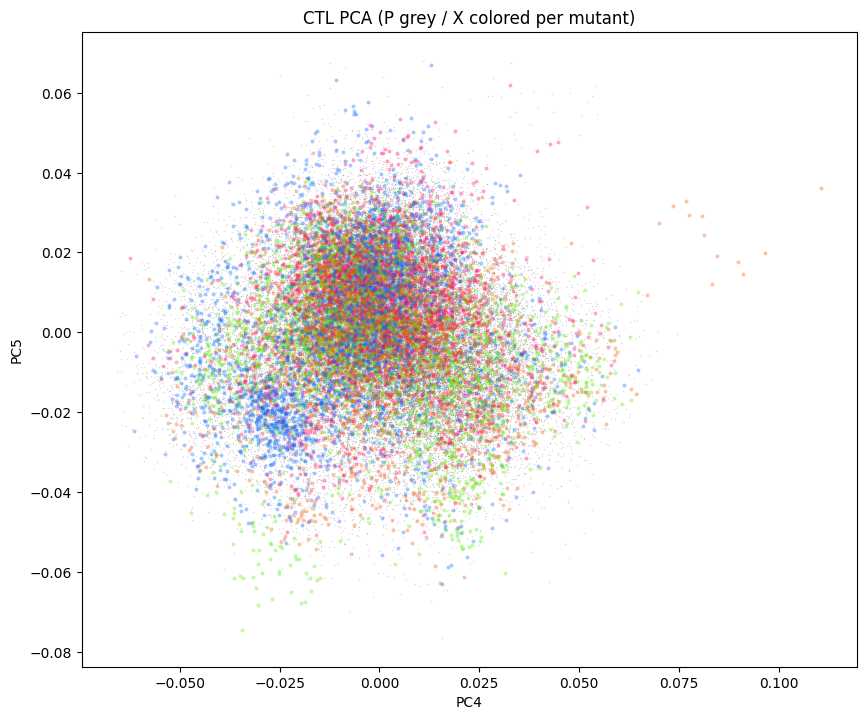

In [25]:
# ============================================================
# PCA on CTL ONLY (C-terminal lobe), ACT excluded
# ============================================================

eps = 1e-6

ACT = masks["ACT"]
CTL = masks["CTL"]
BB = masks["BB"]

sele_ctl = combine_masks(BB, CTL, ~ACT)
fit_ctl  = sele_ctl

print("CTL sele atoms:", int(sele_ctl.sum()), "fit atoms:", int(fit_ctl.sum()))

# -----------------------------
# 1) Align each trajectory on CTL fit (local)
# -----------------------------
ref_fit_ctl = ref_centered[fit_ctl]
ref_fit_ctl = ref_fit_ctl - ref_fit_ctl.mean(axis=0, keepdims=True)

with tim("CTL: aligning all trajectories on fit"):
    traj_ctl = [align_traj_to_ref_by_fit(xyz, fit_ctl, ref_fit_ctl) for xyz in traj_aligned]

# -----------------------------
# 2) Cloud plot (YZ) with auto-zoom
# -----------------------------
with tim("CTL: plotting aligned coordinate density (YZ)"):
    A = []
    for xyz in traj_ctl:
        a = xyz[:, sele_ctl, 1:].reshape((-1, 2)).astype(np.float32)  # YZ
        m = ~((np.abs(a[:, 0]) < eps) & (np.abs(a[:, 1]) < eps))
        A.append(a[m])
    A = np.vstack(A)

    y0, y1 = np.percentile(A[:, 0], [1, 99])
    z0, z1 = np.percentile(A[:, 1], [1, 99])

    plt.figure(figsize=(7, 6))
    plt.hist2d(A[:, 0], A[:, 1], bins=256, range=[[y0, y1], [z0, z1]])
    plt.gca().set_aspect("equal")
    plt.title("CTL aligned density (YZ)")
    plt.xlabel("Y")
    plt.ylabel("Z")
    plt.show()

# -----------------------------
# 3) Vectorize deviations + split per trajectory (variable length)
# -----------------------------
with tim("CTL: vectorizing deviations + building P/X"):
    all_frames = []
    for xyz in traj_ctl:
        all_frames.append(traj_frames_atoms(xyz, sele_ctl))
    all_frames = np.vstack(all_frames)

    mean_ctl = all_frames.mean(axis=0)   # (d,)
    d = mean_ctl.size

    P_list, X_list = [], []
    P_owner, X_owner = [], []

    for ti, xyz in enumerate(traj_ctl):
        dev = traj_frames_atoms(xyz, sele_ctl) - mean_ctl
        split_idx = int(0.8 * dev.shape[0])   # per-trajectory split

        P_i = dev[:split_idx]
        X_i = dev[split_idx:]

        if P_i.shape[0]:
            P_list.append(P_i)
            P_owner.append(np.full(P_i.shape[0], ti, dtype=int))
        if X_i.shape[0]:
            X_list.append(X_i)
            X_owner.append(np.full(X_i.shape[0], ti, dtype=int))

    P_ctl = np.vstack(P_list) if len(P_list) else np.zeros((0, d))
    X_ctl = np.vstack(X_list) if len(X_list) else np.zeros((0, d))
    P_owner_ctl = np.concatenate(P_owner) if len(P_owner) else np.zeros((0,), dtype=int)
    X_owner_ctl = np.concatenate(X_owner) if len(X_owner) else np.zeros((0,), dtype=int)

print("CTL X shape:", X_ctl.shape)

# -----------------------------
# 4) PCA diagonalization (feature covariance)
# -----------------------------
with tim("CTL: diagonalization"):
    C = X_ctl.T @ (X_ctl / len(X_ctl))
    evals, loadings_ctl = np.linalg.eigh(C)
    order = np.argsort(evals)[::-1]
    evals = evals[order]
    loadings_ctl = loadings_ctl[:, order]

# scree plot
plot_scree(evals, n=25, title="Scree plot (CTL PCA)")

print("Cumulative variance (top 25):")
print(np.round(np.cumsum(evals[:25]) / evals.sum(), 2))

# -----------------------------
# 5) Projections (scores)
# -----------------------------
ncomponents = 10
scale = np.sqrt(mean_ctl.size)

with tim(f"CTL: projections on first {ncomponents} PCs (scaled RMSD-like)"):
    pscores_flat_ctl = (P_ctl @ loadings_ctl[:, :ncomponents]) / scale
    scores_flat_ctl  = (X_ctl @ loadings_ctl[:, :ncomponents]) / scale

# color per trajectory (same color for 3 replicas)
ntraj = len(F)
traj_colors = np.repeat(np.array(colors), nrep, axis=0)
traj_colors = np.tile(traj_colors, int(np.ceil(ntraj / len(traj_colors))))[:ntraj]

stride = 5
pairs = [(0,1), (0,2), (1,2), (0,3), (1,3), (2,3), (0,4), (1,4), (2,4), (3,4)]

for a, b in pairs:
    fig, ax = plt.subplots(figsize=(10, 10))

    # early (P): grey
    ax.scatter(
        pscores_flat_ctl[::stride, a], pscores_flat_ctl[::stride, b],
        c="#666", s=1, alpha=0.25, linewidths=0
    )

    # production (X): colored by trajectory
    for ti in range(ntraj):
        m = (X_owner_ctl == ti)
        Zi = scores_flat_ctl[m]
        ax.scatter(
            Zi[::stride, a], Zi[::stride, b],
            s=8, c=[traj_colors[ti]], alpha=0.35, linewidths=0
        )

    ax.set_aspect("equal", adjustable="box")
    ax.set_xlabel(f"PC{a+1}")
    ax.set_ylabel(f"PC{b+1}")
    plt.title("CTL PCA (P grey / X colored per mutant)")
    plt.show()

## Activation Loop PCA with Active/Inactive Labels

The activation loop is one of the most important regulatory regions of protein kinases and often adopts conformations associated with active or inactive states.

This section analyzes activation loop conformational variability using PCA and compares the resulting structural space with active/inactive state labels to assess whether mutants preferentially sample functionally distinct loop conformations.

ACT atoms: 141
[TIMER] A-loop: aligning all trajectories on ACT fit: 24.896 s


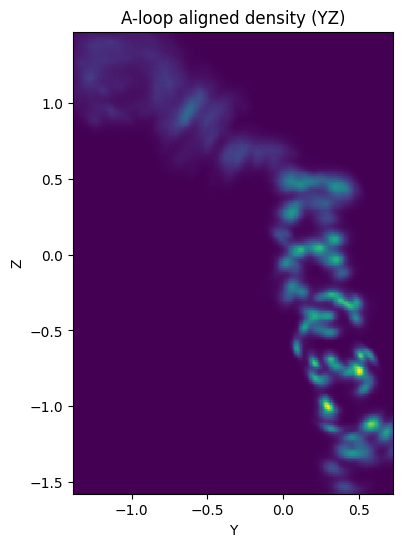

[TIMER] A-loop: cloud plot (YZ): 5.004 s
[TIMER] A-loop: vectorizing deviations + building P/X: 3.310 s
A-loop X shape: (55356, 312)


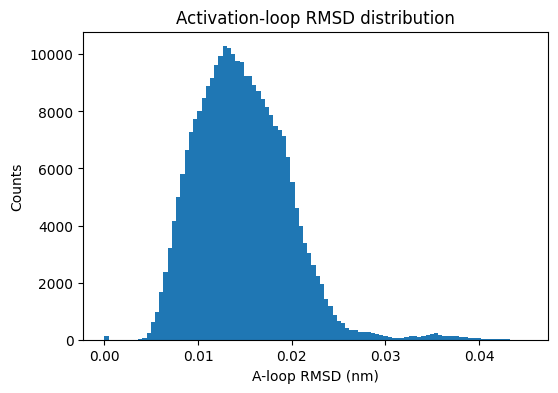

Threshold (nm): 0.25
Fraction inactive-like (overall): 0.0
[TIMER] A-loop: diagonalization: 0.059 s


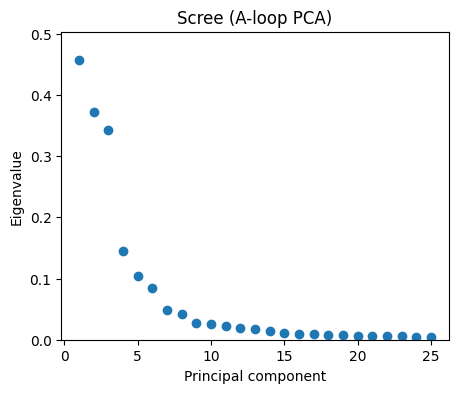

[TIMER] A-loop: projections on first 10 PCs (scaled RMSD-like): 0.027 s


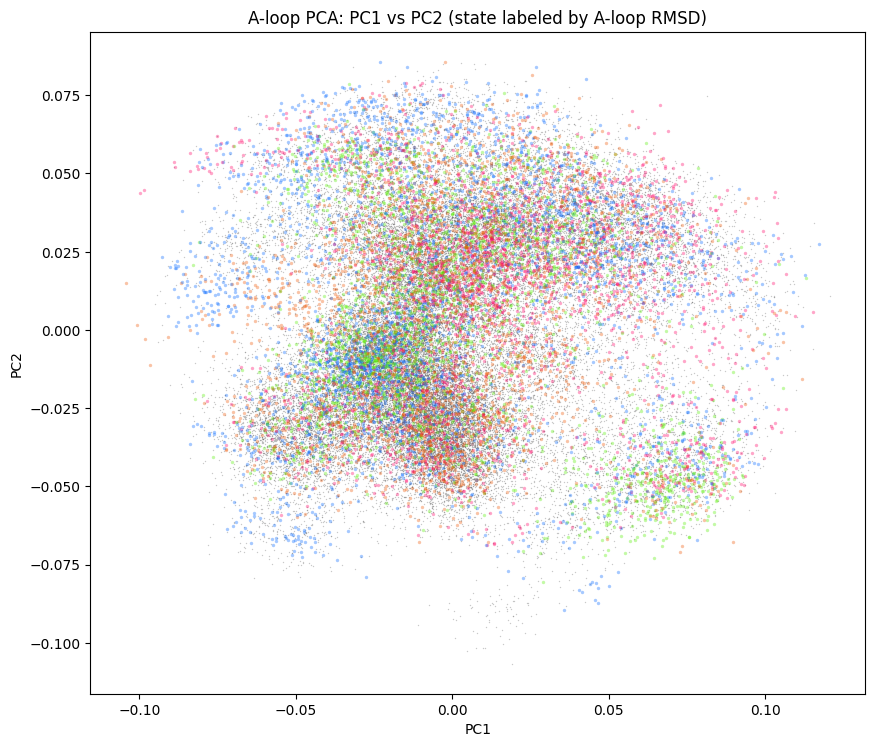

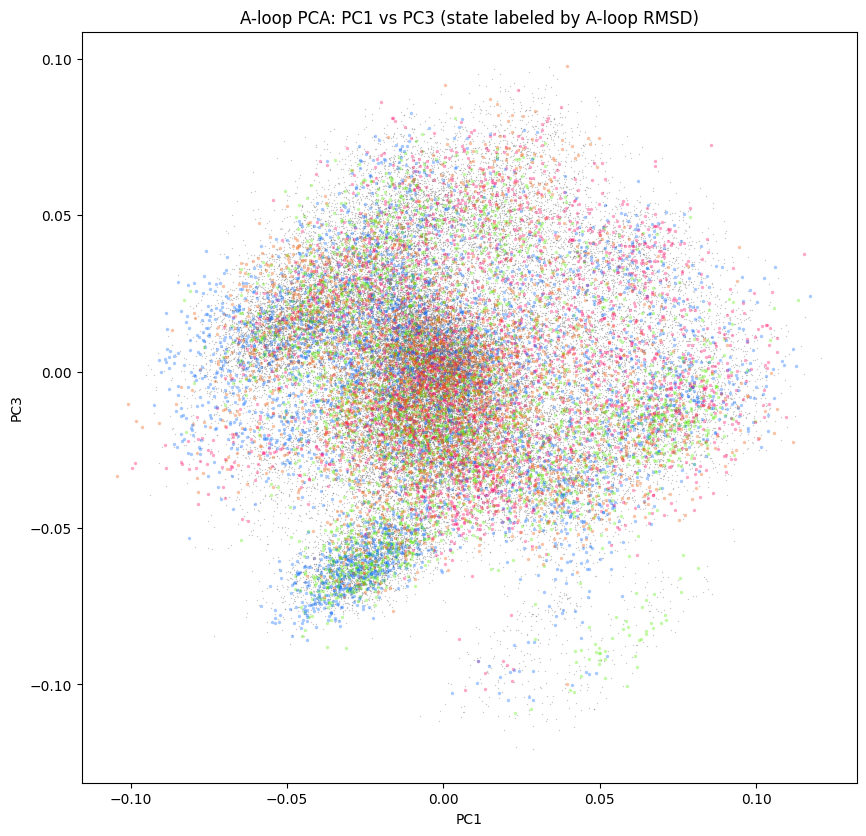

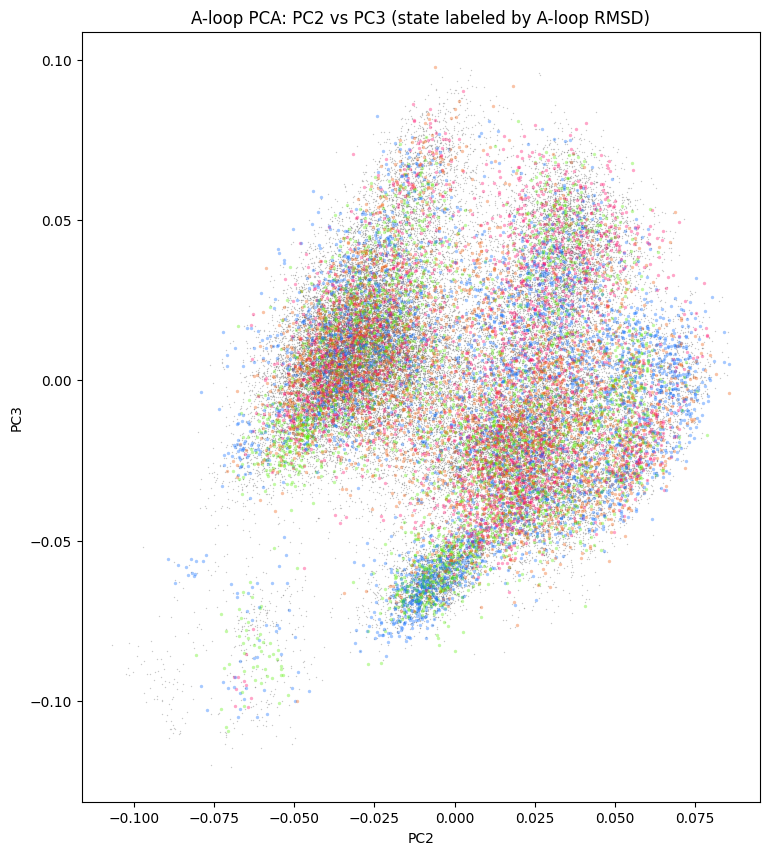

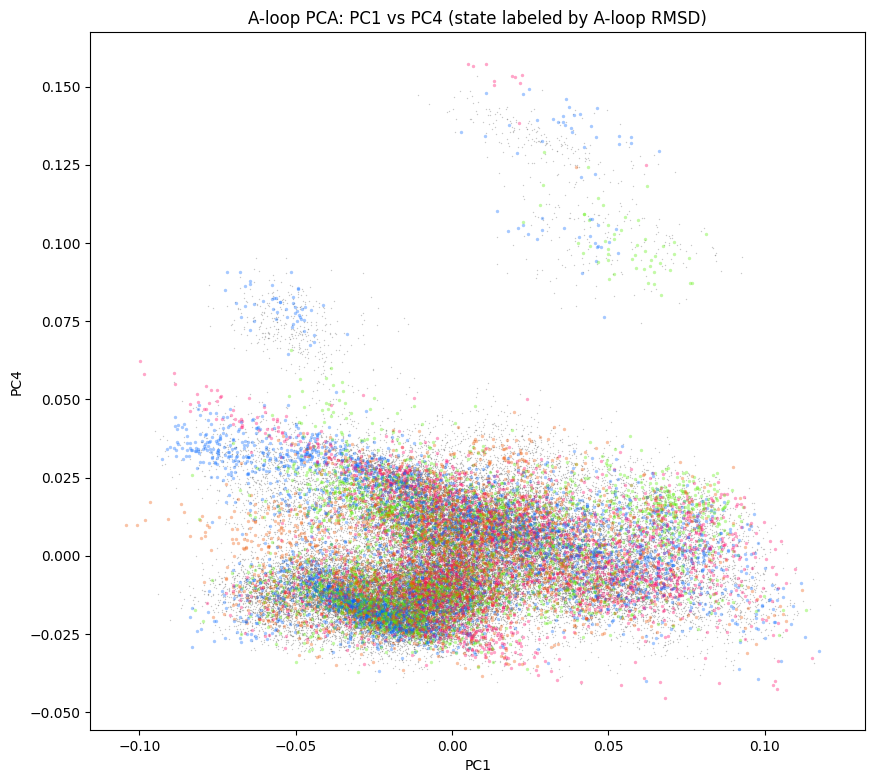

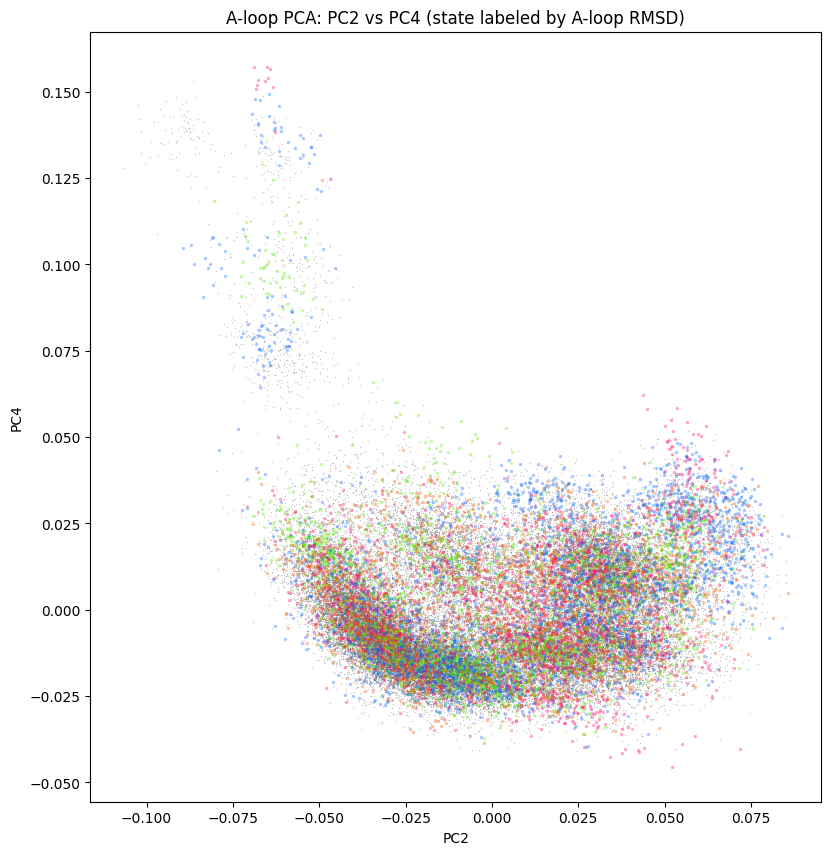

In [26]:
# ============================================================
# PCA on ACTIVATION LOOP ONLY (A-loop), with active/inactive labels
# ============================================================

# -------------------------------
# 0) Sanity + standard masks
# -------------------------------
assert "meta" in globals(), "meta missing"
assert "masks" in globals(), "masks missing - run the standard mask cell first"
assert "traj_aligned" in globals(), "traj_aligned missing"
assert "ref_centered" in globals(), "ref_centered missing"
assert "tim" in globals(), "tim missing"


ACT = masks["ACT"]
BB = masks["BB"]

sele_act = combine_masks(ACT, BB)
fit_act  = sele_act
ACT_idx = np.where(sele_act)[0].astype(int)


print("ACT atoms:", int(ACT.sum()))

if ACT_idx.size < 10:
    raise ValueError("ACT selection too small — check residue range / numbering / exists_all.")

ref_fit_act = ref_centered[fit_act]
ref_fit_act = ref_fit_act - ref_fit_act.mean(axis=0, keepdims=True)

with tim("A-loop: aligning all trajectories on ACT fit"):
    traj_act = [align_traj_to_ref_by_fit(xyz, fit_act, ref_fit_act) for xyz in traj_aligned]

# -------------------------------
# 2) Cloud plot (YZ) for ACT selection
# -------------------------------
with tim("A-loop: cloud plot (YZ)"):
    A = []
    for xyz in traj_act:
        a = xyz[:, sele_act, 1:].reshape((-1, 2)).astype(np.float32)  # YZ
        m = ~((np.abs(a[:, 0]) < 1e-6) & (np.abs(a[:, 1]) < 1e-6))
        A.append(a[m])
    A = np.vstack(A)

    y0, y1 = np.percentile(A[:, 0], [1, 99])
    z0, z1 = np.percentile(A[:, 1], [1, 99])

    plt.figure(figsize=(7, 6))
    plt.hist2d(A[:, 0], A[:, 1], bins=256, range=[[y0, y1], [z0, z1]])
    plt.gca().set_aspect("equal")
    plt.title("A-loop aligned density (YZ)")
    plt.xlabel("Y")
    plt.ylabel("Z")
    plt.show()

# -------------------------------
# 3) Vectorize deviations + build P/X per trajectory
# -------------------------------
with tim("A-loop: vectorizing deviations + building P/X"):
    all_frames = np.vstack([traj_frames_atoms(xyz, sele_act) for xyz in traj_act])
    mean_act = all_frames.mean(axis=0)
    d = mean_act.size

    P_list, X_list = [], []
    P_owner, X_owner = [], []
    P_state, X_state = [], []
    aloop_rmsd_list = []

    thr = 0.25  # nm threshold

    for ti, xyz in enumerate(traj_act):
        # A-loop RMSD per frame vs first frame (nm)
        act_xyz = xyz[:, ACT_idx, :]
        ref0 = act_xyz[0]
        diff = act_xyz - ref0[None, :, :]
        rmsd_nm = np.sqrt((diff ** 2).sum(axis=(1, 2)) / ACT_idx.size) / 10.0
        aloop_rmsd_list.append(rmsd_nm)

        # label state per frame
        state = (rmsd_nm > thr).astype(int)  # 0=active-like, 1=inactive-like

        # PCA dev vectors on ACT atoms
        dev = traj_frames_atoms(xyz, sele_act) - mean_act

        split_idx = int(0.8 * dev.shape[0])
        P_i, X_i = dev[:split_idx], dev[split_idx:]
        sP, sX = state[:split_idx], state[split_idx:]

        if P_i.shape[0]:
            P_list.append(P_i)
            P_owner.append(np.full(P_i.shape[0], ti, dtype=int))
            P_state.append(sP)
        if X_i.shape[0]:
            X_list.append(X_i)
            X_owner.append(np.full(X_i.shape[0], ti, dtype=int))
            X_state.append(sX)

    P = np.vstack(P_list) if len(P_list) else np.zeros((0, d))
    X = np.vstack(X_list) if len(X_list) else np.zeros((0, d))
    P_owner = np.concatenate(P_owner) if len(P_owner) else np.zeros((0,), dtype=int)
    X_owner = np.concatenate(X_owner) if len(X_owner) else np.zeros((0,), dtype=int)
    P_state = np.concatenate(P_state) if len(P_state) else np.zeros((0,), dtype=int)
    X_state = np.concatenate(X_state) if len(X_state) else np.zeros((0,), dtype=int)

print("A-loop X shape:", X.shape)

# quick sanity histogram of A-loop RMSD
plt.figure(figsize=(6, 4))
plt.hist(np.concatenate(aloop_rmsd_list), bins=100)
plt.xlabel("A-loop RMSD (nm)")
plt.ylabel("Counts")
plt.title("Activation-loop RMSD distribution")
plt.show()

print("Threshold (nm):", thr)
print("Fraction inactive-like (overall):", float(np.mean(np.concatenate([(r > thr).astype(int) for r in aloop_rmsd_list]))))

# -------------------------------
# 4) PCA diagonalization
# -------------------------------
with tim("A-loop: diagonalization"):
    C = X.T @ (X / len(X))
    evals, loadings = np.linalg.eigh(C)
    order = np.argsort(evals)[::-1]
    evals = evals[order]
    loadings = loadings[:, order]

plot_scree(evals, n=25, title="Scree (A-loop PCA)")


# -------------------------------
# 5) Projections + plotting
# -------------------------------
ncomponents = 10
scale = np.sqrt(mean_act.size)

with tim(f"A-loop: projections on first {ncomponents} PCs (scaled RMSD-like)"):
    pscores_flat = (P @ loadings[:, :ncomponents]) / scale
    scores_flat = (X @ loadings[:, :ncomponents]) / scale

ntraj = len(F)
traj_colors = np.repeat(np.array(colors), nrep, axis=0)
traj_colors = np.tile(traj_colors, int(np.ceil(ntraj / len(traj_colors))))[:ntraj]

stride = 5
pairs = [(0, 1), (0, 2), (1, 2), (0, 3), (1, 3)]

for a, b in pairs:
    fig, ax = plt.subplots(figsize=(10, 10))

    # Early P (grey), split by state
    m0 = (P_state == 0)
    m1 = (P_state == 1)
    ax.scatter(pscores_flat[m0][::stride, a], pscores_flat[m0][::stride, b],
               c="#666", s=1, alpha=0.35, linewidths=0)
    ax.scatter(pscores_flat[m1][::stride, a], pscores_flat[m1][::stride, b],
               c="#ccc", s=1, alpha=0.35, linewidths=0)

    # Production X (colored per trajectory), split by state
    for ti in range(ntraj):
        mt = (X_owner == ti)
        if not np.any(mt):
            continue

        Zi = scores_flat[mt]
        Si = X_state[mt]

        z0 = Zi[Si == 0]
        z1 = Zi[Si == 1]

        if z0.shape[0]:
            ax.scatter(z0[::stride, a], z0[::stride, b],
                       s=6, c=[traj_colors[ti]], alpha=0.35, linewidths=0)
        if z1.shape[0]:
            ax.scatter(z1[::stride, a], z1[::stride, b],
                       s=6, c=[traj_colors[ti]], alpha=0.35, linewidths=0)

    ax.set_aspect("equal", adjustable="box")
    ax.set_xlabel(f"PC{a+1}")
    ax.set_ylabel(f"PC{b+1}")
    ax.set_title(f"A-loop PCA: PC{a+1} vs PC{b+1} (state labeled by A-loop RMSD)")
    plt.show()

## DFG χ1 Labeling

The DFG motif is a key structural determinant of kinase activation state. In particular, the side-chain orientation of the phenylalanine residue provides a useful geometric marker of conformational state.

This section assigns DFG χ1-based labels in order to relate simulation frames to known kinase structural states and to compare how different mutants populate these conformations.

In [ ]:
# ============================================================
# DFG χ1 labeling (N-CA-CB-CG dihedral)
# ============================================================

# --------- SETTINGS ----------
DFG_F = 170   # DFG Phe residue ID in meta.resids numbering (NOT +1933)
use_median_threshold = True  # simple first pass
manual_thr_deg = None        # setting e.g. 0.0 for manual; otherwise keep None

# --------- 1) COMPUTE χ1 PER TRAJECTORY (variable length) ----------
chi1_deg_list = []
with tim("DFG χ1 (REAL) per-trajectory computation"):
    for d in F:
        pdb = f"{d}/md-prot.pdb"
        xtc = f"{d}/md-prot.xtc"
        chi1_deg_list.append(compute_chi1_deg_for_traj(pdb, xtc, DFG_F))

# --------- 2) HISTOGRAM (all frames pooled) ----------
all_vals = np.concatenate([v[np.isfinite(v)] for v in chi1_deg_list])
plt.figure(figsize=(7,4))
plt.hist(all_vals, bins=120)
plt.title(f"DFG-Phe χ1 distribution (resid {DFG_F})")
plt.xlabel("χ1 (deg)")
plt.ylabel("count")
plt.show()

# --------- 3) THRESHOLD -> 0/1 STATE ----------
if manual_thr_deg is not None:
    thr = float(manual_thr_deg)
else:
    # simple default: median (works even if distribution is bimodal;can later set manual_thr_deg)
    thr = float(np.nanmedian(all_vals))

dfg_state_list = [(v > thr).astype(int) for v in chi1_deg_list]

print("DFG χ1 threshold (deg):", thr)
print("Overall fraction state=1:", float(np.mean(np.concatenate(dfg_state_list))))

# ============================================================
# BRIDGE: Convert full-frame DFG labels -> subsampled DFG_state
# ============================================================

DFG_state = np.zeros((len(F), nframes_sub), dtype=np.int8)

for ti in range(len(F)):
    fi = frame_idx_list[ti]  # original frame indices used elsewhere (length nframes_sub)

    full = np.asarray(dfg_state_list[ti], dtype=np.int8)  # full-frame labels

    if fi.max() >= full.size:
        raise ValueError(
            f"[DFG BRIDGE] Traj {ti} ({F[ti]}): max(fi)={int(fi.max())} "
            f"but dfg_state_list length={full.size}. "
            "This means dfg_state_list was not computed on full frames."
        )

    DFG_state[ti] = full[fi][:nframes_sub]

print("[DFG BRIDGE] DFG_state shape:", DFG_state.shape,
      "| mean state=1:", float(DFG_state.mean()))

# ============================================================
# OPTIONAL A) COLOR ACT-OUT PCA 
# Requires these to exist:
#   pscores_flat_actout, scores_flat_actout, P_owner_actout, X_owner_actout
# and ALSO requires:
#   traj_actout (list of aligned xyz per traj)  
# ============================================================

if all(k in globals() for k in ["pscores_flat_actout", "scores_flat_actout", "P_owner_actout", "X_owner_actout"]):
    # Build flattened DFG labels that match the flattened ACT-OUT PCA rows
    dfg_flat_P = []
    dfg_flat_X = []

    for ti in range(len(F)):
        # how many rows in ACT-OUT PCA belong to this trajectory?
        nP = int(np.sum(P_owner_actout == ti))
        nX = int(np.sum(X_owner_actout == ti))

        # local frames (from DFG χ1 computation)
        n_local = int(len(dfg_state_list[ti]))
        split_idx = int(0.8 * n_local)  

        # take exactly as many labels as PCA rows for that traj
        dfgP = dfg_state_list[ti][:split_idx][:nP]
        dfgX = dfg_state_list[ti][split_idx:split_idx + nX]

        if len(dfgP) != nP or len(dfgX) != nX:
            print(f"[WARN] traj {ti} label count mismatch: want P={nP},X={nX} got P={len(dfgP)},X={len(dfgX)}")

        dfg_flat_P.append(dfgP)
        dfg_flat_X.append(dfgX)

    dfg_flat_P = np.concatenate(dfg_flat_P) if len(dfg_flat_P) else np.array([], dtype=int)
    dfg_flat_X = np.concatenate(dfg_flat_X) if len(dfg_flat_X) else np.array([], dtype=int)

    print("dfg_flat_P shape:", dfg_flat_P.shape, "matches pscores_flat_actout:", pscores_flat_actout.shape[0])
    print("dfg_flat_X shape:", dfg_flat_X.shape, "matches scores_flat_actout :", scores_flat_actout.shape[0])

    # --- PCA plots colored by DFG state (ACT-OUT PCA) ---
    pairs = [(0,1),(0,2),(1,2),(0,3),(1,3)]
    for a, b in pairs:
        fig, ax = plt.subplots(figsize=(10,10))

        # early P: grey shades by DFG state
        ax.scatter(pscores_flat_actout[dfg_flat_P==0, a],
                   pscores_flat_actout[dfg_flat_P==0, b],
                   c="#666", s=1, alpha=0.35, linewidths=0)
        ax.scatter(pscores_flat_actout[dfg_flat_P==1, a],
                   pscores_flat_actout[dfg_flat_P==1, b],
                   c="#ccc", s=1, alpha=0.35, linewidths=0)

        # production X: keep it simple (state colors)
        ax.scatter(scores_flat_actout[dfg_flat_X==0, a],
                   scores_flat_actout[dfg_flat_X==0, b],
                   c="#1f77b4", s=6, alpha=0.35, linewidths=0)
        ax.scatter(scores_flat_actout[dfg_flat_X==1, a],
                   scores_flat_actout[dfg_flat_X==1, b],
                   c="#d62728", s=6, alpha=0.35, linewidths=0)

        ax.set_aspect("equal", adjustable="box")
        ax.set_xlabel(f"PC{a+1}")
        ax.set_ylabel(f"PC{b+1}")
        ax.set_title(f"ACT-OUT PCA colored by REAL DFG χ1 state (thr={thr:.1f}°)")
        plt.show()

else:
    print("ACT-OUT PCA variables not found — computed only chi1_deg_list + dfg_state_list.")

## Whole-Kinase PCA after Alignment to the CTL (Activation Loop Excluded)

To emphasize inter-lobe motions, trajectories were aligned to the C-terminal lobe (CTL) before performing PCA on the kinase domain with the activation loop excluded.

This representation reduces contributions from global rotation and highly flexible loop motion, allowing clearer visualization of relative movements between the kinase lobes.

In [ ]:
# ============================================================
# PCA on whole kinase (~ACT) after fitting to CTL (~ACT)
# - alignment on CTL & ~ACT (fit_mask)
# - PCA on BODY & BB & ~ACT (sele_mask)
# - variable-length version using traj_aligned
# ============================================================

split = 1
ncomponents = 10

# --------- Preconditions ----------
need = ["traj_aligned", "F", "selection", "colors", "tim", "nrep", "masks", "ref_centered"]
missing = [v for v in need if v not in globals()]
if missing:
    raise NameError(f"Missing required variables: {missing}. Run setup cells first.")

nmut = len(traj_aligned)
natoms = traj_aligned[0].shape[1]
print("n trajectories:", nmut, "| natoms:", natoms)

meta = ensure_meta(
    meta=meta if "meta" in globals() else None,
    top=f"{F[0]}/md-prot.pdb",
    selection=selection,
    natoms=natoms
)

# --------- Standard masks from central setup ----------
BB = masks["BB"]
BODY = masks["BODY"]
ACT = masks["ACT"]
CTL = masks["CTL"]

fit_mask = combine_masks(BB, BODY, CTL, ~ACT)
sele_mask = combine_masks(BB, BODY, ~ACT)

print("FIT atoms:", int(fit_mask.sum()))
print("SELE atoms:", int(sele_mask.sum()))

if fit_mask.sum() < 50:
    raise ValueError("FIT mask too small — check CTL/ACT ranges or selection.")
if sele_mask.sum() < 50:
    raise ValueError("SELE mask too small — check ACT range or selection.")

# --------- Alignment ----------
ref_fit_ctl = ref_centered[fit_mask]
ref_fit_ctl = ref_fit_ctl - ref_fit_ctl.mean(axis=0, keepdims=True)

with tim("Alignment on FIT (robust, variable length)"):
    traj_ctlfit_actout = [
        align_traj_to_ref_by_fit(xyz, fit_mask, ref_fit_ctl)
        for xyz in traj_aligned
    ]

# --------- Vectorize deviations for PCA ----------
with tim("Vectorizing deviations for PCA"):
    all_frames = []
    for xyz in traj_ctlfit_actout:
        all_frames.append(traj_frames_atoms(xyz, sele_mask))
    all_frames = np.vstack(all_frames)

    mean = all_frames.mean(axis=0)
    d = mean.size

    P_list, X_list = [], []
    P_owner, X_owner = [], []

    for ti, xyz in enumerate(traj_ctlfit_actout):
        dev = traj_frames_atoms(xyz, sele_mask) - mean

        # preserve original section behavior: first frame = P, rest = X
        split_idx = min(split, dev.shape[0])

        P_i = dev[:split_idx]
        X_i = dev[split_idx:]

        if P_i.shape[0]:
            P_list.append(P_i)
            P_owner.append(np.full(P_i.shape[0], ti, dtype=int))
        if X_i.shape[0]:
            X_list.append(X_i)
            X_owner.append(np.full(X_i.shape[0], ti, dtype=int))

    P = np.vstack(P_list) if len(P_list) else np.zeros((0, d))
    X = np.vstack(X_list) if len(X_list) else np.zeros((0, d))
    P_owner = np.concatenate(P_owner) if len(P_owner) else np.zeros((0,), dtype=int)
    X_owner = np.concatenate(X_owner) if len(X_owner) else np.zeros((0,), dtype=int)

print("X shape:", X.shape, "| X finite:", bool(np.isfinite(X).all()))

# --------- PCA diagonalization ----------
with tim("PCA diagonalization"):
    C = (X.T @ (X / len(X))).astype(np.float64)
    evals, loadings = np.linalg.eigh(C)
    order = np.argsort(evals)[::-1]
    evals = evals[order]
    loadings = loadings[:, order]

plot_scree(evals, n=25, title="Scree (~ACT PCA, aligned on CTL)")

# --------- Scores ----------
scale = np.sqrt(mean.size)
scores_flat = (X @ loadings[:, :ncomponents]) / scale
pscores_flat = (P @ loadings[:, :ncomponents]) / scale

# keep per-trajectory list version for later use
scores_actout_ctlfit = [scores_flat[X_owner == ti].copy() for ti in range(nmut)]
pscores_actout_ctlfit = [pscores_flat[P_owner == ti].copy() for ti in range(nmut)]

# also save flat version + owners for variable-length clustering
scores_flat_actout_ctlfit = scores_flat.copy()
pscores_flat_actout_ctlfit = pscores_flat.copy()
X_owner_actout_ctlfit = X_owner.copy()
P_owner_actout_ctlfit = P_owner.copy()

print("Saved scores_actout_ctlfit:", [z.shape for z in scores_actout_ctlfit])

# --------- PCA plots ----------
traj_colors = np.repeat(np.array(colors), nrep, axis=0)
traj_colors = np.tile(traj_colors, int(np.ceil(nmut / len(traj_colors))))[:nmut]

# build 3D-like padded array only for helper plotting convenience
max_x = max((z.shape[0] for z in scores_actout_ctlfit), default=0)
scores_plot = np.full((nmut, max_x, ncomponents), np.nan, dtype=float)
for ti, z in enumerate(scores_actout_ctlfit):
    scores_plot[ti, :z.shape[0], :] = z

stride_plot = 20

plot_pca_scatter_zoom(
    scores_plot,
    pcx=0,
    pcy=1,
    stride=stride_plot,
    title="~ACT PCA (PC1 vs PC2) [stride]",
    colors=traj_colors,
    alpha=0.25,
    size=3,
    qlow=0.5,
    qhigh=99.5,
)

plot_pca_scatter_zoom(
    scores_plot,
    pcx=0,
    pcy=1,
    stride=20,
    title="~ACT PCA (PC1 vs PC2) [zoom 1–99%]",
    colors=None,
    alpha=0.25,
    size=3,
    qlow=1,
    qhigh=99,
)

plot_pca_scatter(
    scores_plot,
    pcx=0,
    pcy=2,
    stride=20,
    title="~ACT PCA (PC1 vs PC3)",
    colors=None,
    alpha=0.25,
    size=3,
)

In [ ]:
# ============================================================
# CTL-fit ACT-OUT clustering + occupancy + heatmap
# ============================================================

ACT_OUT_CTLFIT_CLUSTER = run_cluster_panel_varlen(
    scores_flat=scores_flat_actout_ctlfit,
    x_owner=X_owner_actout_ctlfit,
    F=F,
    prefix="actout_ctlfit",
    title_prefix="ACT-OUT (fit to CTL)",
    n_pcs=5,
    min_cluster_size=150,
    eps=0.8,
    min_samples=60,
    run_hdbscan=run_hdbscan,
    run_dbscan=run_dbscan,
    plot_occupancy_heatmap=plot_occupancy_heatmap,
    plot_cluster_population=plot_cluster_population,
    plot_pca_clusters=plot_pca_clusters,
    display_fn=display,
)

## Orientation PCA

Orientation PCA was performed on 12 engineered orientation features derived from the relative geometry between the N-terminal lobe (NTL) and C-terminal lobe (CTL) of the kinase domain.

These features describe inter-lobe orientation changes and capture domain rearrangements that may be relevant for kinase activation and inhibitor binding.

The scree plot shows that the first two principal components capture the majority of the variance, while higher components contribute only marginally.

Therefore clustering and visualization were performed using PC1 and PC2.

In [ ]:
# ============================================================
# Distance/Orientation PCA: NTL vs CTL (COM + principal axis)
# variable-length version using traj_aligned
# ============================================================

# -----------------------------
# 0) Inputs / sanity
# -----------------------------
assert "traj_aligned" in globals(), "traj_aligned missing"
assert "F" in globals() and isinstance(F, list) and isinstance(F[0], str), "F missing/corrupted"
assert "selection" in globals(), "selection missing"
assert "tim" in globals(), "tim missing"
assert "masks" in globals(), "masks missing - run the standard mask cell first"

nmut = len(traj_aligned)
natoms = traj_aligned[0].shape[1]

meta = ensure_meta(
    meta=meta if "meta" in globals() else None,
    top=f"{F[0]}/md-prot.pdb",
    selection=selection,
    natoms=natoms
)

# fallback if no state labels exist
if "fform_full" not in globals():
    fform_full = [np.zeros(xyz.shape[0], dtype=int) for xyz in traj_aligned]

traj_colors = plt.cm.tab20(np.linspace(0, 1, nmut))[:, :3]

# -----------------------------
# 1) Standard masks from central setup
# -----------------------------
CA = masks["CA"]
BODY = masks["BODY"]
ACT = masks["ACT"]
NTL = masks["NTL"]
CTL = masks["CTL"]

mask_ctl = combine_masks(CTL, BODY, CA, ~ACT)
mask_ntl = combine_masks(NTL, BODY, CA)

ctl_idx = np.where(mask_ctl)[0]
ntl_idx = np.where(mask_ntl)[0]

print("CTL CA atoms:", ctl_idx.size, "| NTL CA atoms:", ntl_idx.size)

if ctl_idx.size < 5 or ntl_idx.size < 5:
    raise ValueError("CTL/NTL CA selections are too small. Check residue ranges or masks.")

# -----------------------------
# 2) Build features per trajectory
# -----------------------------
with tim("FAST orientation features (NTL vs CTL)"):
    feats_list = []
    owner_list = []
    fform_list = []
    d_list = []

    for ti, xyz in enumerate(traj_aligned):
        ctl = xyz[:, ctl_idx, :]
        ntl = xyz[:, ntl_idx, :]

        ctl_com = ctl.mean(axis=1)
        ntl_com = ntl.mean(axis=1)

        v = ntl_com - ctl_com
        vnorm = np.linalg.norm(v, axis=1, keepdims=True) + 1e-12
        vhat = v / vnorm

        nf_i = xyz.shape[0]
        feats_i = np.zeros((nf_i, 12), dtype=np.float32)

        for fj in range(nf_i):
            ctl_c = ctl[fj] - ctl_com[fj]
            ntl_c = ntl[fj] - ntl_com[fj]

            a_ctl = principal_axis(ctl_c)
            a_ntl = principal_axis(ntl_c)

            feats_i[fj, 0:3] = vhat[fj]
            feats_i[fj, 3:6] = a_ctl
            feats_i[fj, 6:9] = a_ntl
            feats_i[fj, 9] = angle(vhat[fj], a_ctl)
            feats_i[fj, 10] = angle(vhat[fj], a_ntl)
            feats_i[fj, 11] = angle(a_ctl, a_ntl)

        feats_list.append(feats_i)
        owner_list.append(np.full(nf_i, ti, dtype=int))

        if isinstance(fform_full, list):
            fform_i = np.asarray(fform_full[ti], dtype=int)
        else:
            fform_i = np.asarray(fform_full[ti][:nf_i], dtype=int)
        fform_list.append(fform_i)

        dist = np.linalg.norm(ntl_com - ctl_com, axis=1) / 10.0
        d_i = np.exp(-5 * dist)
        d_list.append(d_i.astype(np.float32))

feats = np.vstack(feats_list)
X_owner_orient = np.concatenate(owner_list)
fform_flat = np.concatenate(fform_list)
d = np.concatenate(d_list)

d -= d.min() - 1e-6
d /= d.max()

# -----------------------------
# 3) PCA on 12D features
# -----------------------------
m = feats.mean(axis=0, keepdims=True)
Dc = feats - m

with tim("PCA on 12D features"):
    C = (Dc.T @ Dc) / len(Dc)
    evals, evecs = np.linalg.eigh(C)
    order = np.argsort(evals)[::-1]
    evals = evals[order]
    evecs = evecs[:, order]

yscores = Dc @ evecs[:, :3]

scores_orient_flat = yscores.copy()
scores_orient = [yscores[X_owner_orient == ti].copy() for ti in range(nmut)]

plot_scree(evals, n=len(evals), title="Orientation-PCA scree (12 features)")

var_ratio = evals / evals.sum()
print("Orientation PCA variance ratios (top 6):", np.round(var_ratio[:6], 4))
print("Orientation PCA cumulative variance (top 6):", np.round(np.cumsum(var_ratio[:6]), 4))

# -----------------------------
# 4) Global scatter
# -----------------------------
plt.figure(figsize=(7, 7))
plt.scatter(
    yscores[:, 0],
    yscores[:, 1],
    c=fform_flat,
    s=100 * d,
    alpha=0.6,
    linewidths=0
)
plt.gca().set_aspect("equal", adjustable="box")
plt.title("Orientation-PCA (NTL vs CTL)\ncolor=fform state, size=exp(-5*COMdist)")
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.show()

# -----------------------------
# 5) Per-trajectory view
# grey=all, yellow=state1, colored=last 20%
# -----------------------------
fig, ax = plt.subplots(figsize=(7, 7))

start = 0
for ti in range(nmut):
    nf_i = scores_orient[ti].shape[0]
    e_start = int((1 - 0.20) * nf_i)

    r = slice(start, start + nf_i)
    e = slice(start + e_start, start + nf_i)
    f = fform_flat[r].astype(bool)

    ax.scatter(yscores[r, 0], yscores[r, 1], c="#cccccc", s=100 * d[r], alpha=0.35, linewidths=0)
    ax.scatter(yscores[r, 0][f], yscores[r, 1][f], c="#999900", s=100 * d[r][f], alpha=0.7, linewidths=0)
    ax.scatter(yscores[e, 0], yscores[e, 1], c=traj_colors[ti], s=100 * d[e], alpha=0.85, linewidths=0, zorder=3)

    start += nf_i

ax.set_aspect("equal", adjustable="box")
ax.set_title("Orientation-PCA: per-trajectory view\n(grey=all, yellow=state1, colored=last 20%)")
ax.set_xlabel("PC1")
ax.set_ylabel("PC2")
plt.show()

In [ ]:
# ============================================================
# ORIENTATION clustering + occupancy + heatmap
# ============================================================
print("Orientation clustering uses PC1-PC2 only.")
print("HDBSCAN min_cluster_size=150 | DBSCAN eps=0.3 min_samples=100")

ORIENTATION_CLUSTER = run_cluster_panel_varlen(
    scores_flat=scores_orient_flat,
    x_owner=X_owner_orient,
    F=F,
    prefix="orientation",
    title_prefix="Orientation",
    n_pcs=2,
    min_cluster_size=150,
    eps=0.3,
    min_samples=100,
    run_hdbscan=run_hdbscan,
    run_dbscan=run_dbscan,
    plot_occupancy_heatmap=plot_occupancy_heatmap,
    plot_cluster_population=plot_cluster_population,
    plot_pca_clusters=plot_pca_clusters,
    display_fn=display,
)

## Activation Loop PCA

The activation loop (A-loop) is a key regulatory element of kinase activity.

A dedicated PCA analysis was performed on the activation loop to characterize its conformational variability across mutants.

In [ ]:
# ============================================================
# A-loop PCA (variable-length, aligned on A-loop)
# ============================================================

# --- sanity ---
assert "traj_aligned" in globals(), "traj_aligned missing"
assert "F" in globals() and isinstance(F, list) and isinstance(F[0], str), "F missing/corrupted"
assert "selection" in globals(), "selection missing"
assert "masks" in globals(), "masks missing - run the standard mask cell first"
assert "tim" in globals(), "tim missing"

nmut = len(traj_aligned)
natoms = traj_aligned[0].shape[1]

meta = ensure_meta(
    meta=meta if "meta" in globals() else None,
    top=f"{F[0]}/md-prot.pdb",
    selection=selection,
    natoms=natoms
)

ACT = masks["ACT"]
BB = masks["BB"]
exists_all = masks["exists_all"]

ACT_mask = combine_masks(ACT, BB)

sel_idx = np.where(ACT_mask)[0].astype(int)
n_sel = sel_idx.size

# save A-loop selection for later motion writing
sel_idx_act = sel_idx.copy()
sele_act = ACT_mask.copy()

print("[Aloop] saved sel_idx_act:", sel_idx_act.size)
print("[Aloop] ACT_mask atoms:", n_sel)

if n_sel < 20:
    raise ValueError("A-loop selection too small. Check residue window or selection.")

# ------------------------------------------------------------
# 0) Pick reference from traj 0 frame 0
# ------------------------------------------------------------
T0 = traj_aligned[0]
ref = T0[0, sel_idx, :].astype(np.float64)
if not np.isfinite(ref).all():
    raise ValueError("Reference (traj0 frame0) has non-finite ACT coords. Pick another ref frame.")
ref = ref - ref.mean(axis=0, keepdims=True)

thr_absurd = 1e5  # Å guard

# ------------------------------------------------------------
# 1) Align all frames on A-loop (Kabsch)
# ------------------------------------------------------------
with tim("[Aloop] Align all frames on A-loop (Kabsch)"):
    traj_act_al = []
    frame_ok_list = []

    for ti, T in enumerate(traj_aligned):
        X = T[:, sel_idx, :].astype(np.float64)   # (nframes_i, n_sel, 3)

        finite = np.isfinite(X).all(axis=(1, 2))
        absurd = (np.abs(X).max(axis=(1, 2)) > thr_absurd)
        ok = finite & (~absurd)

        M_i = np.empty((T.shape[0], n_sel, 3), dtype=np.float32)
        last_good = None

        for fi in range(T.shape[0]):
            if not ok[fi]:
                M_i[fi] = last_good if last_good is not None else 0.0
                continue

            P = X[fi] - X[fi].mean(axis=0, keepdims=True)
            R = kabsch_R(P, ref)
            Pal = (P @ R).astype(np.float32)
            M_i[fi] = Pal
            last_good = Pal

        traj_act_al.append(M_i)
        frame_ok_list.append(ok)

print("[Aloop] bad frames total:", int(sum((~ok).sum() for ok in frame_ok_list)))
print("[Aloop] number of trajectories:", len(traj_act_al))

# ------------------------------------------------------------
# 2) Vectorize deviations + PCA
# ------------------------------------------------------------
split = 1
ncomponents = 5

with tim("[Aloop] Vectorize deviations + PCA"):
    good_frames = []
    for ti, M_i in enumerate(traj_act_al):
        ok_i = frame_ok_list[ti]
        if ok_i.any():
            good_frames.append(M_i[ok_i])

    if not good_frames:
        raise ValueError("No valid A-loop frames found.")

    good_stack = np.vstack(good_frames)            # (n_good_total, n_sel, 3)
    mean_act = good_stack.mean(axis=0)             # (n_sel, 3)

    P_list, X_list = [], []
    P_owner, X_owner = [], []

    for ti, M_i in enumerate(traj_act_al):
        dev_i = (M_i - mean_act[None, :, :]).reshape(M_i.shape[0], -1)

        # preserve original section behavior: first frame = P, rest = X
        split_idx = min(split, dev_i.shape[0])

        P_i = dev_i[:split_idx]
        X_i = dev_i[split_idx:]

        if P_i.shape[0]:
            P_list.append(P_i.astype(np.float32))
            P_owner.append(np.full(P_i.shape[0], ti, dtype=int))
        if X_i.shape[0]:
            X_list.append(X_i.astype(np.float32))
            X_owner.append(np.full(X_i.shape[0], ti, dtype=int))

    d = mean_act.size
    P = np.vstack(P_list) if len(P_list) else np.zeros((0, d), dtype=np.float32)
    X = np.vstack(X_list) if len(X_list) else np.zeros((0, d), dtype=np.float32)
    P_owner = np.concatenate(P_owner) if len(P_owner) else np.zeros((0,), dtype=int)
    X_owner = np.concatenate(X_owner) if len(X_owner) else np.zeros((0,), dtype=int)

    Xc = X - X.mean(axis=0, keepdims=True)
    C = (Xc.T @ Xc) / len(Xc)
    evals, loadings = np.linalg.eigh(C)
    order = np.argsort(evals)[::-1]
    evals = evals[order]
    loadings = loadings[:, order]

# ---- SAVE A-loop PCA outputs for later motion writing ----
loadings_act = loadings.copy()
mean_act_vec = mean_act.reshape(-1).copy()

print("[Aloop] saved loadings_act:", loadings_act.shape)
print("[Aloop] saved mean_act_vec:", mean_act_vec.shape, "| expected:", 3 * len(sel_idx_act))

# Scree plot
plot_scree(evals, n=25, title="Scree (A-loop PCA)")

print("[Aloop] Top 10 variance ratios:", np.round(evals[:10] / evals.sum(), 4))

# Scores (RMSD-like scaling)
scale = np.sqrt(mean_act.size)
scores_flat_act = (X @ loadings[:, :ncomponents]) / scale
pscores_flat_act = (P @ loadings[:, :ncomponents]) / scale

print("[Aloop] scores_flat_act:", scores_flat_act.shape)
print("[Aloop] pscores_flat_act:", pscores_flat_act.shape)

# save both flat and per-trajectory versions
X_owner_act = X_owner.copy()
P_owner_act = P_owner.copy()

scores_act = [scores_flat_act[X_owner == ti].copy() for ti in range(nmut)]
pscores_act = [pscores_flat_act[P_owner == ti].copy() for ti in range(nmut)]

print("[Aloop] saved scores_act/pscores_act")

# Plot PC1 vs PC2
base_colors = np.array(colors) if "colors" in globals() else np.array(["#ee5500", "#55ee00", "#0066ff", "#ff0066"])
traj_colors = np.tile(base_colors, int(np.ceil(nmut / len(base_colors))))[:nmut]

plt.figure(figsize=(8,8))
for i in range(nmut):
    if len(pscores_act[i]):
        plt.scatter(pscores_act[i][:, 0], pscores_act[i][:, 1], s=6, c="#bbb", alpha=0.25, linewidths=0)
    if len(scores_act[i]):
        plt.scatter(scores_act[i][::10, 0], scores_act[i][::10, 1], s=3, c=[traj_colors[i]], alpha=0.25, linewidths=0)

plt.gca().set_aspect("equal", adjustable="box")
plt.xlabel("PC1 (A-loop)")
plt.ylabel("PC2 (A-loop)")
plt.title("A-loop-only PCA (aligned on A-loop)")
plt.show()

# --- residue contribution (PC1/PC2) ---
def pc_atom_contrib(loadings_pc, n_sel):
    L = loadings_pc.reshape((n_sel, 3))
    return np.sqrt((L**2).sum(axis=1))

pc1_atom = pc_atom_contrib(loadings[:, 0], n_sel)
pc2_atom = pc_atom_contrib(loadings[:, 1], n_sel)

sel_resids = meta.resids[sel_idx]
uniq = np.unique(sel_resids)

pc1_res = np.array([pc1_atom[sel_resids == r].sum() for r in uniq])
pc2_res = np.array([pc2_atom[sel_resids == r].sum() for r in uniq])

plt.figure(figsize=(10,3))
plt.plot(uniq, pc1_res, label="PC1 contrib")
plt.plot(uniq, pc2_res, label="PC2 contrib")
plt.xlabel("Residue id (meta.resids)")
plt.ylabel("Loading magnitude (sum)")
plt.title("A-loop PCA: residue contributions (PC1/PC2)")
plt.legend()
plt.show()

In [ ]:
# ============================================================
# A-loop clustering + occupancy + heatmap
# ============================================================

ALOOP_CLUSTER = run_cluster_panel_equal(
    scores_3d=scores_act,
    F=F,
    prefix="aloop",
    title_prefix="A-loop",
    n_pcs=3,
    min_cluster_size=120,
    eps=0.6,
    min_samples=50,
    run_hdbscan=run_hdbscan,
    run_dbscan=run_dbscan,
    occupancy_from_traj_labels=occupancy_from_traj_labels,
    plot_occupancy_heatmap=plot_occupancy_heatmap,
    plot_cluster_population=plot_cluster_population,
    plot_pca_clusters=plot_pca_clusters,
    display_fn=display,
)

labels_act = ALOOP_CLUSTER["labels_hdb"]
print("labels_act:", labels_act.shape)

## Distance PCA

In addition to coordinate-based PCA, a distance-based PCA was performed using inter-residue or inter-lobe distance features.

This complementary representation captures geometric relationships directly and can highlight conformational differences that are less obvious in Cartesian coordinate space.

In [ ]:
# ============================================================
# DISTANCE-PCA (NTL–CTL CA–CA distances)
# variable-length version using traj_aligned
# -> outputs: yscores_dist, d_dist, fform_flat_dist, traj_id_dist
# -> also saves X-matched subset for A-loop cluster coloring
# ============================================================

# ---- prerequisites ----
assert "traj_aligned" in globals(), "traj_aligned missing"
assert "masks" in globals(), "masks missing - run the standard mask cell first"
assert "F" in globals(), "F missing"
assert "selection" in globals(), "selection missing"

nmut = len(traj_aligned)

meta = ensure_meta(
    meta=meta if "meta" in globals() else None,
    top=f"{F[0]}/md-prot.pdb",
    selection=selection,
    natoms=traj_aligned[0].shape[1]
)

# ---- standard masks from central setup ----
CA = masks["CA"]
BODY = masks["BODY"]
ACT = masks["ACT"]
NTL = masks["NTL"]
CTL = masks["CTL"]

mask_ctl = combine_masks(CTL, BODY, CA, ~ACT)
mask_ntl = combine_masks(NTL, BODY, CA)

ctl_idx = np.where(mask_ctl)[0]
ntl_idx = np.where(mask_ntl)[0]

print("CTL CA:", len(ctl_idx), "NTL CA:", len(ntl_idx))

if len(ctl_idx) == 0 or len(ntl_idx) == 0:
    raise ValueError("CTL/NTL CA masks are empty. Check masks and residue ranges.")

# ---- compute distances per frame per traj ----
D_list = []
traj_id_list = []
fform_list = []
xmask_list = []

for ti, xyz in enumerate(traj_aligned):
    MCTL = xyz[:, ctl_idx, :]     # (nframes_i, n_ctl, 3)
    MNTL = xyz[:, ntl_idx, :]     # (nframes_i, n_ntl, 3)

    # pairwise CA-CA distances: (nframes_i, n_ctl, n_ntl)
    Dij = np.sqrt(((MCTL[:, :, None, :] - MNTL[:, None, :, :]) ** 2).sum(axis=-1))

    # flatten to features: (nframes_i, n_pairs)
    D_i = Dij.reshape(xyz.shape[0], -1).astype(np.float32)
    D_list.append(D_i)

    traj_id_list.append(np.full(xyz.shape[0], ti, dtype=int))

    if "fform_full" in globals():
        if isinstance(fform_full, list):
            fform_i = np.asarray(fform_full[ti], dtype=int)
        else:
            fform_i = np.asarray(fform_full[ti][:xyz.shape[0]], dtype=int)
    else:
        fform_i = np.zeros(xyz.shape[0], dtype=int)

    fform_list.append(fform_i)

    # ---- IMPORTANT ----
    # match the later A-loop clustering behavior:
    # first frame = P, remaining frames = X
    split_idx = min(1, xyz.shape[0])
    xmask_i = np.zeros(xyz.shape[0], dtype=bool)
    xmask_i[split_idx:] = True
    xmask_list.append(xmask_i)

D = np.vstack(D_list)  # (total_frames, n_pairs)
traj_id_dist = np.concatenate(traj_id_list)
fform_flat_dist = np.concatenate(fform_list)
xmask_dist = np.concatenate(xmask_list)

print("D:", D.shape)

# ---- PCA in distance-feature space ----
m = D.mean(axis=0, keepdims=True)
Dc = D - m
C = (Dc.T @ Dc) / len(Dc)

evals, evecs = np.linalg.eigh(C)
order = np.argsort(evals)[::-1]
evals = evals[order]
evecs = evecs[:, order]

plot_scree(evals, n=25, title="Scree (Distance PCA)")

yscores_dist = Dc @ evecs[:, :3]  # (nobs, 3)
print("yscores_dist:", yscores_dist.shape)

# ---- save flat outputs for possible later use ----
scores_flat_dist = yscores_dist.copy()
X_owner_dist = traj_id_dist.copy()

# ---- save X-matched subset for A-loop cluster overlay ----
yscores_dist_x = yscores_dist[xmask_dist]
traj_id_dist_x = traj_id_dist[xmask_dist]
fform_flat_dist_x = fform_flat_dist[xmask_dist]

print("yscores_dist_x:", yscores_dist_x.shape)

# ---- size scaling for plotting ----
d_dist = np.exp(-5 * D).sum(axis=1)
d_dist -= d_dist.min() - 1e-6
d_dist /= d_dist.max()

d_dist_x = d_dist[xmask_dist]

print("labels:", fform_flat_dist.shape, "sizes:", d_dist.shape, "traj_id:", traj_id_dist.shape)

# ---- quick plot ----
plt.figure(figsize=(7, 7))
plt.scatter(
    yscores_dist[:, 0],
    yscores_dist[:, 1],
    c=fform_flat_dist,
    s=80 * d_dist,
    alpha=0.5,
    linewidths=0
)
plt.gca().set_aspect("equal", adjustable="box")
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.title("Distance-PCA (variable-length trajectories)")
plt.show()

In [ ]:
print("labels_act:", labels_act.shape)
print("yscores_dist_x:", yscores_dist_x.shape)

assert len(labels_act) == yscores_dist_x.shape[0], \
    "A-loop labels and Distance-PCA X subset do not match."

plt.figure(figsize=(7, 7))
plt.scatter(
    yscores_dist_x[:, 0],
    yscores_dist_x[:, 1],
    c=labels_act,
    s=80 * d_dist_x,
    alpha=0.6,
    linewidths=0
)
plt.gca().set_aspect("equal", adjustable="box")
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.title("Distance PCA colored by A-loop clusters")
plt.show()

## Tyrosine Loop PCA

The tyrosine loop (Tyr-loop) forms part of the catalytic site and contributes to substrate recognition.

PCA of this loop was performed to examine mutation-dependent structural variability in the catalytic region.

In [ ]:
# ============================================================
# Tyrosine-loop PCA (170–190) — variable-length version
# aligned on BODY backbone
# ============================================================

# --- sanity ---
assert "traj_aligned" in globals(), "traj_aligned missing"
assert "F" in globals() and isinstance(F, list) and isinstance(F[0], str), "F missing/corrupted"
assert "selection" in globals(), "selection missing"
assert "tim" in globals(), "tim missing"
assert "masks" in globals(), "masks missing - run the standard mask cell first"

nmut = len(traj_aligned)
natoms = traj_aligned[0].shape[1]
print("n trajectories:", nmut, "| natoms:", natoms)

meta = ensure_meta(
    meta=meta if "meta" in globals() else None,
    top=f"{F[0]}/md-prot.pdb",
    selection=selection,
    natoms=natoms
)

exists_all = masks["exists_all"]
CA = masks["CA"]
BB = masks["BB"]
BODY = masks["BODY"]

# Tyrosine-loop residue window
LOOP_RES_RANGE = np.arange(170, 191)  # 170..190 inclusive

loop_atoms = np.isin(meta.resids, LOOP_RES_RANGE) & exists_all

loop_CA = combine_masks(loop_atoms, CA)
loop_BB = combine_masks(loop_atoms, BB)

# Fit mask for alignment: BODY backbone
fit_mask = combine_masks(BB, BODY)

print("loop_CA atoms:", int(loop_CA.sum()))
print("loop_BB atoms:", int(loop_BB.sum()))
print("fit_mask atoms:", int(fit_mask.sum()))

if loop_BB.sum() < 10:
    raise ValueError("loop_BB too small — check residue range or actual resids in meta.")
if fit_mask.sum() < 50:
    raise ValueError("fit_mask too small — check BODY/BB selection.")



with tim("[TYR] Alignment on BODY backbone (robust)"):
    ref_fit = ref_centered[fit_mask]
    ref_fit = ref_fit - ref_fit.mean(axis=0, keepdims=True)

    traj_tyr_al = [
        align_traj_to_ref_by_fit(xyz, fit_mask, ref_fit)
        for xyz in traj_aligned
    ]

# ------------------------------------------------------------
# PCA
# ------------------------------------------------------------
split_loop = 1
ncomponents = 10

with tim("[TYR] Vectorizing loop deviations"):
    all_frames = []
    for xyz in traj_tyr_al:
        all_frames.append(traj_frames_atoms(xyz, loop_BB))
    all_frames = np.vstack(all_frames)

    mean_loop = all_frames.mean(axis=0)
    d = mean_loop.size

    P_list, X_list = [], []
    P_owner, X_owner = [], []

    for ti, xyz in enumerate(traj_tyr_al):
        dev_i = traj_frames_atoms(xyz, loop_BB) - mean_loop

        # preserve original section behavior: first frame = P, rest = X
        split_idx = min(split_loop, dev_i.shape[0])

        P_i = dev_i[:split_idx]
        X_i = dev_i[split_idx:]

        if P_i.shape[0]:
            P_list.append(P_i.astype(np.float32))
            P_owner.append(np.full(P_i.shape[0], ti, dtype=int))
        if X_i.shape[0]:
            X_list.append(X_i.astype(np.float32))
            X_owner.append(np.full(X_i.shape[0], ti, dtype=int))

    P = np.vstack(P_list) if len(P_list) else np.zeros((0, d), dtype=np.float32)
    X = np.vstack(X_list) if len(X_list) else np.zeros((0, d), dtype=np.float32)
    P_owner = np.concatenate(P_owner) if len(P_owner) else np.zeros((0,), dtype=int)
    X_owner = np.concatenate(X_owner) if len(X_owner) else np.zeros((0,), dtype=int)

print("[TYR] X:", X.shape, "| finite:", bool(np.isfinite(X).all()))

with tim("[TYR] PCA diagonalization (feature-space)"):
    Xc = X - X.mean(axis=0, keepdims=True)
    C = (Xc.T @ Xc) / len(Xc)
    evals, loadings = np.linalg.eigh(C)
    order = np.argsort(evals)[::-1]
    evals = evals[order]
    loadings = loadings[:, order]

plot_scree(evals, n=25, title="Scree (Tyrosine-loop PCA 170–190)")
print("[TYR] Top 5 variance ratios:", np.round(evals[:5] / evals.sum(), 4))

scale = np.sqrt(mean_loop.size)  # RMSD-like scaling

scores_flat_tyr = (X @ loadings[:, :ncomponents]) / scale
pscores_flat_tyr = (P @ loadings[:, :ncomponents]) / scale

scores_tyr = [scores_flat_tyr[X_owner == ti].copy() for ti in range(nmut)]
pscores_tyr = [pscores_flat_tyr[P_owner == ti].copy() for ti in range(nmut)]
X_owner_tyr = X_owner.copy()
P_owner_tyr = P_owner.copy()

print("Saved scores_tyr:", [z.shape for z in scores_tyr])

# colors per trajectory
base_colors = np.array(colors) if "colors" in globals() else np.array(["#ee5500","#55ee00","#0066ff","#ff0066"])
traj_colors = np.tile(base_colors, int(np.ceil(nmut/len(base_colors))))[:nmut]

stride_plot = 10

plt.figure(figsize=(8,8))
for i in range(nmut):
    if len(pscores_tyr[i]):
        plt.scatter(pscores_tyr[i][:, 0], pscores_tyr[i][:, 1], s=6, c="#bbb", alpha=0.25, linewidths=0)
    if len(scores_tyr[i]):
        plt.scatter(scores_tyr[i][::stride_plot, 0], scores_tyr[i][::stride_plot, 1], s=3, c=[traj_colors[i]], alpha=0.25, linewidths=0)

plt.gca().set_aspect("equal", adjustable="box")
plt.xlabel("PC1 (loop)")
plt.ylabel("PC2 (loop)")
plt.title("Tyrosine-loop PCA (170–190) — aligned on BODY backbone")
plt.show()

In [ ]:
# ============================================================
# Tyr-loop clustering + occupancy + heatmap
# ============================================================

TYR_CLUSTER = run_cluster_panel_varlen(
    scores_flat=scores_flat_tyr,
    x_owner=X_owner_tyr,
    F=F,
    prefix="tyrloop",
    title_prefix="Tyrosine loop",
    n_pcs=3,
    min_cluster_size=120,
    eps=0.6,
    min_samples=50,
    run_hdbscan=run_hdbscan,
    run_dbscan=run_dbscan,
    plot_occupancy_heatmap=plot_occupancy_heatmap,
    plot_cluster_population=plot_cluster_population,
    plot_pca_clusters=plot_pca_clusters,
    display_fn=display,
)


## αC-helix analysis

The αC-helix is a central regulatory element in kinases. For ROS1, a useful first-pass analysis is:

- **Mobility** of the αC-helix (RMSF / RMSD-like spread)
- **αC-in / αC-out proxy** using the distance between the conserved β3 Lys and αC Glu
- **Per-mutant occupancy** of compact vs displaced αC states

In many kinases, the Lys–Glu ion-pair is a standard activation readout. Here we use it as a **proxy**, not as a definitive active/inactive label.


In [ ]:
# ============================================================
# Structural-region helpers for downstream metrics
# ============================================================

def get_abs_resids(meta):
    return np.asarray(meta.resids).astype(int) + 1933

REGIONS = {
    "alphaC": (1960, 1975),
    "hinge": (2011, 2016),
    "P_loop": (1978, 1987),
    "DFG": (2103, 2105),
}

print("Defined REGIONS:", REGIONS)

In [ ]:
# ============================================================
# αC-HELIX METRICS
# variable-length version using traj_aligned
# ============================================================

# --- prerequisites / coordinate extraction ---
assert "traj_aligned" in globals(), "traj_aligned missing"
assert "F" in globals(), "F missing"
assert "selection" in globals(), "selection missing"
assert "meta" in globals() or len(traj_aligned) > 0, "Need meta or traj_aligned"
assert "REGIONS" in globals(), "REGIONS missing"
assert "get_abs_resids" in globals(), "get_abs_resids missing"

natoms = traj_aligned[0].shape[1]

if "meta" not in globals() or len(meta) != natoms:
    meta = mda.Universe(f"{F[0]}/md-prot.pdb").select_atoms(selection)

resids_abs = get_abs_resids(meta)
names = np.asarray(meta.names)

ntraj = len(traj_aligned)
mut_names = np.array([os.path.basename(os.path.dirname(p.rstrip("/"))) for p in F])

# --- masks ---
mask_alphaC = (
    (resids_abs >= REGIONS["alphaC"][0]) &
    (resids_abs <= REGIONS["alphaC"][1]) &
    (names == "CA")
)

mask_pocket_anchor = (
    (resids_abs >= REGIONS["hinge"][0]) &
    (resids_abs <= REGIONS["hinge"][1]) &
    (names == "CA")
)

print("alphaC CA atoms:", int(mask_alphaC.sum()), "| hinge CA atoms:", int(mask_pocket_anchor.sum()))

if mask_alphaC.sum() == 0:
    raise ValueError("alphaC mask is empty. Check REGIONS['alphaC'] and atom names.")
if mask_pocket_anchor.sum() == 0:
    raise ValueError("hinge mask is empty. Check REGIONS['hinge'] and atom names.")

# --- helpers ---
def first_existing(mask):
    idx = np.where(mask)[0]
    return None if len(idx) == 0 else idx[0]

# prefer sidechain atoms if present; otherwise fall back to CA
idx_lys = first_existing((resids_abs == 1980) & np.isin(names, ["NZ", "CA"]))
idx_glu = first_existing((resids_abs == 1967) & np.isin(names, ["OE1", "OE2", "CA"]))

# --- per-trajectory metrics ---
alphaC_rmsf_mean_list = []
alphaC_hinge_mean_dist_list = []
alphaC_hinge_std_dist_list = []
alphaC_compact_frac_list = []

all_d_lys_glu = []

for xyz in traj_aligned:
    # xyz: (nframes_i, natoms, 3)

    alphaC_xyz = xyz[:, mask_alphaC, :]                  # (frame, atom, xyz)
    alphaC_mean = alphaC_xyz.mean(axis=0, keepdims=True)
    alphaC_rmsf = np.sqrt(((alphaC_xyz - alphaC_mean) ** 2).sum(axis=(0, 2)) / alphaC_xyz.shape[0])
    alphaC_rmsf_mean_list.append(alphaC_rmsf.mean())

    alphaC_com = alphaC_xyz.mean(axis=1)                 # (frame, 3)
    hinge_com = xyz[:, mask_pocket_anchor, :].mean(axis=1)
    alphaC_hinge_dist = np.linalg.norm(alphaC_com - hinge_com, axis=1)

    alphaC_hinge_mean_dist_list.append(alphaC_hinge_dist.mean())
    alphaC_hinge_std_dist_list.append(alphaC_hinge_dist.std())

    if idx_lys is not None and idx_glu is not None:
        d_i = np.linalg.norm(xyz[:, idx_lys, :] - xyz[:, idx_glu, :], axis=1)
        all_d_lys_glu.append(d_i)

# --- Lys1980 – Glu1967 proxy for αC-in / αC-out ---
if idx_lys is not None and idx_glu is not None:
    all_d_lys_glu_flat = np.concatenate(all_d_lys_glu)
    thr_alphaC = np.nanmedian(all_d_lys_glu_flat)

    for d_i in all_d_lys_glu:
        alphaC_state_i = (d_i <= thr_alphaC).astype(int)   # 1 = compact / αC-in-like
        alphaC_compact_frac_list.append(alphaC_state_i.mean())

    print(f"Lys1980-Glu1967 proxy threshold: {thr_alphaC:.3f} nm")
else:
    print("Could not build Lys-Glu αC proxy with current atom set; RMSF and COM metrics still available.")

# --- summary table ---
df_alphaC = pd.DataFrame({
    "trajectory": [p.replace('/Simulation_', ' / Sim ') for p in F],
    "mutant": mut_names,
    "alphaC_mean_RMSF": alphaC_rmsf_mean_list,
    "alphaC_hinge_mean_dist": alphaC_hinge_mean_dist_list,
    "alphaC_hinge_std_dist": alphaC_hinge_std_dist_list,
})

if idx_lys is not None and idx_glu is not None:
    df_alphaC["alphaC_compact_frac"] = alphaC_compact_frac_list

display(df_alphaC.sort_values(["mutant", "trajectory"]).head(12))

# --- mutant-level summary ---
agg_cols = [c for c in df_alphaC.columns if c not in ["trajectory", "mutant"]]
df_alphaC_mut = df_alphaC.groupby("mutant")[agg_cols].mean().sort_values("alphaC_mean_RMSF", ascending=False)
display(df_alphaC_mut)

# --- plots ---
fig, ax = plt.subplots(figsize=(11,4))
ax.bar(df_alphaC_mut.index, df_alphaC_mut["alphaC_mean_RMSF"])
ax.set_ylabel("mean αC RMSF-like value (nm)")
ax.set_title("Per-mutant αC-helix mobility")
ax.tick_params(axis='x', rotation=90)
plt.show()

fig, ax = plt.subplots(figsize=(11,4))
ax.bar(df_alphaC_mut.index, df_alphaC_mut["alphaC_hinge_mean_dist"])
ax.set_ylabel("mean αC-to-hinge COM distance (nm)")
ax.set_title("Per-mutant αC displacement relative to hinge")
ax.tick_params(axis='x', rotation=90)
plt.show()

if "alphaC_compact_frac" in df_alphaC_mut.columns:
    fig, ax = plt.subplots(figsize=(11,4))
    ax.bar(df_alphaC_mut.index, df_alphaC_mut["alphaC_compact_frac"])
    ax.set_ylabel("fraction αC-compact frames")
    ax.set_title("Per-mutant αC compact-state occupancy")
    ax.tick_params(axis='x', rotation=90)
    plt.show()


## ATP-binding pocket analysis

For the pocket, you do **not** want only one metric. A better story is to combine several simple geometric readouts:

1. **P-loop ↔ hinge distance**  
   A proxy for whether the front of the pocket is compressed or open.

2. **P-loop ↔ DFG distance**  
   A proxy for communication between the glycine-rich loop and the activation segment.

3. **Gatekeeper ↔ DFG-Phe distance**  
   A proxy for back-pocket accessibility near the gatekeeper region.

4. **Pocket state occupancy**  
   After computing these distances, you can cluster or threshold them and ask which mutants prefer which pocket geometry.

This section gives you a compact first-pass implementation.


In [ ]:
# ============================================================
# ATP-POCKET GEOMETRY METRICS
# variable-length version using traj_aligned
# ============================================================

assert "traj_aligned" in globals(), "traj_aligned missing"
assert "F" in globals(), "F missing"
assert "selection" in globals(), "selection missing"
assert "REGIONS" in globals(), "REGIONS missing"
assert "get_abs_resids" in globals(), "get_abs_resids missing"

natoms = traj_aligned[0].shape[1]

if "meta" not in globals() or len(meta) != natoms:
    meta = mda.Universe(f"{F[0]}/md-prot.pdb").select_atoms(selection)

resids_abs = get_abs_resids(meta)
names = np.asarray(meta.names)

mut_names = np.array([os.path.basename(os.path.dirname(p.rstrip("/"))) for p in F])

def first_existing(mask):
    idx = np.where(mask)[0]
    return None if len(idx) == 0 else idx[0]

# ---- masks ----
mask_ploop = (
    (resids_abs >= REGIONS["P_loop"][0]) &
    (resids_abs <= REGIONS["P_loop"][1]) &
    (names == "CA")
)
mask_hinge = (
    (resids_abs >= REGIONS["hinge"][0]) &
    (resids_abs <= REGIONS["hinge"][1]) &
    (names == "CA")
)
mask_dfg = (
    (resids_abs >= REGIONS["DFG"][0]) &
    (resids_abs <= REGIONS["DFG"][1]) &
    (names == "CA")
)

print("P-loop CA atoms:", int(mask_ploop.sum()))
print("hinge CA atoms:", int(mask_hinge.sum()))
print("DFG CA atoms:", int(mask_dfg.sum()))

if mask_ploop.sum() == 0:
    raise ValueError("P-loop mask is empty. Check REGIONS['P_loop'].")
if mask_hinge.sum() == 0:
    raise ValueError("hinge mask is empty. Check REGIONS['hinge'].")
if mask_dfg.sum() == 0:
    raise ValueError("DFG mask is empty. Check REGIONS['DFG'].")

# Gatekeeper-to-DFG-Phe (or nearest available DFG atom) distance
idx_gate = first_existing((resids_abs == 2026) & (names == "CA"))
idx_dfgF = first_existing((resids_abs == 2104) & np.isin(names, ["CZ", "CE1", "CE2", "CA"]))

# ---- per-trajectory metrics ----
pocket_front_mean = []
pocket_front_std = []
pocket_dfg_mean = []
pocket_dfg_std = []
pocket_open_frac = []
gate_dfgF_mean = []
gate_dfgF_std = []

all_front = []
all_back = []

per_traj_front = []
per_traj_back = []

for xyz in traj_aligned:
    # xyz: (nframes_i, natoms, 3)

    ploop_com = xyz[:, mask_ploop, :].mean(axis=1)
    hinge_com = xyz[:, mask_hinge, :].mean(axis=1)
    dfg_com   = xyz[:, mask_dfg, :].mean(axis=1)

    d_ploop_hinge_i = np.linalg.norm(ploop_com - hinge_com, axis=1)
    d_ploop_dfg_i   = np.linalg.norm(ploop_com - dfg_com, axis=1)

    per_traj_front.append(d_ploop_hinge_i)
    pocket_front_mean.append(d_ploop_hinge_i.mean())
    pocket_front_std.append(d_ploop_hinge_i.std())

    pocket_dfg_mean.append(d_ploop_dfg_i.mean())
    pocket_dfg_std.append(d_ploop_dfg_i.std())

    all_front.append(d_ploop_hinge_i)

    if idx_gate is not None and idx_dfgF is not None:
        d_gate_dfgF_i = np.linalg.norm(xyz[:, idx_gate, :] - xyz[:, idx_dfgF, :], axis=1)
        per_traj_back.append(d_gate_dfgF_i)
        all_back.append(d_gate_dfgF_i)
    else:
        per_traj_back.append(None)

# ---- global thresholds for open-state proxy ----
all_front_flat = np.concatenate(all_front)
thr_front = np.nanmedian(all_front_flat)

if idx_gate is not None and idx_dfgF is not None and len(all_back):
    all_back_flat = np.concatenate(all_back)
    thr_back = np.nanmedian(all_back_flat)
    print(f"Pocket front threshold: {thr_front:.3f} nm")
    print(f"Gatekeeper–DFG-Phe threshold: {thr_back:.3f} nm")
else:
    thr_back = np.nan
    print(f"Pocket front threshold: {thr_front:.3f} nm")
    print("Gatekeeper/DFG-Phe atom selection missing; skipping that metric.")

# ---- build per-trajectory open-state summaries ----
for i in range(len(traj_aligned)):
    front_open_i = (per_traj_front[i] >= thr_front).astype(int)

    if np.isfinite(thr_back) and per_traj_back[i] is not None:
        back_open_i = (per_traj_back[i] >= thr_back).astype(int)
        pocket_open_i = ((front_open_i + back_open_i) >= 1).astype(int)

        gate_dfgF_mean.append(np.nanmean(per_traj_back[i]))
        gate_dfgF_std.append(np.nanstd(per_traj_back[i]))
    else:
        pocket_open_i = front_open_i.copy()

    pocket_open_frac.append(pocket_open_i.mean())

# ---- summary table ----
df_pocket = pd.DataFrame({
    "trajectory": [p.replace('/Simulation_', ' / Sim ') for p in F],
    "mutant": mut_names,
    "pocket_front_mean": pocket_front_mean,
    "pocket_front_std": pocket_front_std,
    "pocket_dfg_mean": pocket_dfg_mean,
    "pocket_dfg_std": pocket_dfg_std,
    "pocket_open_frac": pocket_open_frac,
})

if np.isfinite(thr_back):
    df_pocket["gate_dfgF_mean"] = gate_dfgF_mean
    df_pocket["gate_dfgF_std"] = gate_dfgF_std

display(df_pocket.sort_values(["mutant", "trajectory"]).head(12))

df_pocket_mut = df_pocket.groupby("mutant").mean(numeric_only=True).sort_values("pocket_open_frac", ascending=False)
display(df_pocket_mut)

fig, ax = plt.subplots(figsize=(11,4))
ax.bar(df_pocket_mut.index, df_pocket_mut["pocket_front_mean"])
ax.set_ylabel("P-loop ↔ hinge distance (nm)")
ax.set_title("Per-mutant front-pocket opening")
ax.tick_params(axis='x', rotation=90)
plt.show()

fig, ax = plt.subplots(figsize=(11,4))
ax.bar(df_pocket_mut.index, df_pocket_mut["pocket_dfg_mean"])
ax.set_ylabel("P-loop ↔ DFG distance (nm)")
ax.set_title("Per-mutant pocket-to-activation-segment coupling")
ax.tick_params(axis='x', rotation=90)
plt.show()

fig, ax = plt.subplots(figsize=(11,4))
ax.bar(df_pocket_mut.index, df_pocket_mut["pocket_open_frac"])
ax.set_ylabel("fraction pocket-open frames")
ax.set_title("Per-mutant ATP-pocket open-state occupancy")
ax.tick_params(axis='x', rotation=90)
plt.show()

## Further Analysis

The following analyses provide additional interpretation of the PCA and clustering results.

These include sanity checks, basin decomposition, transition behavior, and simple interpretable structural metrics that help connect low-dimensional projections to physically meaningful conformational changes.

In [ ]:
# ============================================================
# SANITY + two-state basins + transitions + interpretable metric
# variable-length version
# ============================================================

# ----------------------------
# 0) Basic sanity checks
# ----------------------------
assert "traj_aligned" in globals(), "traj_aligned missing"
assert "F" in globals() and isinstance(F, list) and isinstance(F[0], str), "F is missing or corrupted (should be list of paths)"

ntraj = len(traj_aligned)
natoms = traj_aligned[0].shape[1]

print("ntraj:", ntraj, "| natoms:", natoms)
print("len(F):", len(F))

assert len(F) == ntraj, "len(F) must match number of trajectories"

# ACT/DFG shape checks (if they exist)
if "ACT_state" in globals():
    print("ACT_state lengths:", [len(x) for x in ACT_state[:5]], "...")
    print("ACT_state mean1:", float(np.mean(np.concatenate(ACT_state))))
else:
    print("ACT_state not found (ok if you haven't built it yet)")

if "DFG_state" in globals():
    print("DFG_state lengths:", [len(x) for x in DFG_state[:5]], "...")
    print("DFG_state mean1:", float(np.mean(np.concatenate(DFG_state))))
else:
    print("DFG_state not found (ok if you haven't bridged it yet)")

# ----------------------------
# 1) WT replica occupancies (ACT/DFG)
# ----------------------------
wt_idx = [i for i, p in enumerate(F) if p.startswith("WT/")]
print("\nWT indices:", wt_idx, "->", [F[i] for i in wt_idx])

def _occ(x01):
    return float(np.mean(x01))

if wt_idx and "ACT_state" in globals():
    print("\nWT ACT_state occupancies:")
    for i in wt_idx:
        print(F[i], "ACT_state=1 frac:", round(_occ(ACT_state[i]), 3))

if wt_idx and "DFG_state" in globals():
    print("\nWT DFG_state occupancies:")
    for i in wt_idx:
        print(F[i], "DFG_state=1 frac:", round(_occ(DFG_state[i]), 3))

# ----------------------------
# 2) Choose a PCA space for basins
# ----------------------------
scores_flat = None
x_owner = None
scores_name = None

if "scores_orient_flat" in globals() and "X_owner_orient" in globals():
    scores_flat = scores_orient_flat
    x_owner = X_owner_orient
    scores_name = "ORIENTATION PCA"
elif "yscores_dist" in globals() and "traj_id_dist" in globals():
    scores_flat = yscores_dist
    x_owner = traj_id_dist
    scores_name = "DISTANCE PCA"
elif "scores_flat_actout_ctlfit" in globals() and "X_owner_actout_ctlfit" in globals():
    scores_flat = scores_flat_actout_ctlfit
    x_owner = X_owner_actout_ctlfit
    scores_name = "ACT-OUT CTL-fit PCA"
else:
    raise NameError(
        "No compatible PCA scores found. Need one of:\n"
        "  (scores_orient_flat, X_owner_orient)\n"
        "  (yscores_dist, traj_id_dist)\n"
        "  (scores_flat_actout_ctlfit, X_owner_actout_ctlfit)"
    )

scores_flat = np.asarray(scores_flat)
x_owner = np.asarray(x_owner, dtype=int)

assert scores_flat.shape[0] == x_owner.shape[0], f"{scores_name}: score/owner length mismatch"

print(f"\nUsing basins from: {scores_name} | scores_flat shape: {scores_flat.shape}")

# ----------------------------
# 3) Two-state labeling from PC1 (median split)
# ----------------------------
pc1 = scores_flat[:, 0].astype(float)
thr = float(np.median(pc1))
basin_flat = (pc1 > thr).astype(np.int8)  # 1 = high-PC1 basin

basin = [basin_flat[x_owner == ti] for ti in range(len(F))]

print("[PC1 BASIN] threshold (median):", thr)
print("[PC1 BASIN] overall basin=1 fraction:", float(np.mean(basin_flat)))

plt.figure(figsize=(6,4))
plt.hist(pc1, bins=120)
plt.axvline(thr, ls="--")
plt.xlabel("PC1")
plt.ylabel("count")
plt.title(f"PC1 distribution ({scores_name}) + median split")
plt.show()

if wt_idx:
    print("\nWT PC1 basin occupancies:")
    for i in wt_idx:
        print(F[i], "basin1 frac:", round(float(np.mean(basin[i])), 3))

mutant_of = np.array([p.split("/")[0] for p in F], dtype=object)
uniq_mut = np.unique(mutant_of)

print("\nPC1 basin occupancy per mutant (avg over replicas):")
for mut in uniq_mut:
    idx = np.where(mutant_of == mut)[0]
    vals = [float(np.mean(basin[i])) for i in idx]
    print(mut, round(float(np.mean(vals)), 3))

# ----------------------------
# 4) Transition behavior: switch counts + dwell times
# ----------------------------
sw = np.array([switch_count(basin[i]) for i in range(len(F))], dtype=float)
dw = np.array([mean_dwell_frames(basin[i]) for i in range(len(F))], dtype=float)

print("\nTransitions (PC1 basins):")
print("WT switch counts:", [int(sw[i]) for i in wt_idx] if wt_idx else "WT not found")
print("WT mean dwell (frames):", [round(dw[i],1) for i in wt_idx] if wt_idx else "WT not found")

print("\nPer-mutant transition summary (mean over replicas):")
for mut in uniq_mut:
    idx = np.where(mutant_of == mut)[0]
    print(f"{mut:16s}  switches={sw[idx].mean():6.1f} ± {sw[idx].std():5.1f}   dwell(fr)={dw[idx].mean():6.1f} ± {dw[idx].std():5.1f}")

# ----------------------------
# 5) Interpretable metric: NTL–CTL COM distance per basin (nm)
# ----------------------------
if "ctl_idx" in globals() and "ntl_idx" in globals():
    print("\nComputing NTL–CTL COM distance per basin using existing ctl_idx/ntl_idx...")
    comdist_list = []

    for ti in range(len(F)):
        xyz = traj_aligned[ti]
        ctl_com = xyz[:, ctl_idx, :].mean(axis=1)
        ntl_com = xyz[:, ntl_idx, :].mean(axis=1)
        d_i = np.linalg.norm(ntl_com - ctl_com, axis=1) / 10.0
        comdist_list.append(d_i)

    dA = np.concatenate([comdist_list[i][basin[i] == 0] for i in range(len(F)) if len(basin[i])])
    dB = np.concatenate([comdist_list[i][basin[i] == 1] for i in range(len(F)) if len(basin[i])])

    print("COMdist nm: mean basin0 =", round(float(dA.mean()), 4), "| mean basin1 =", round(float(dB.mean()), 4))

    plt.figure(figsize=(6,4))
    plt.hist(dA, bins=80, alpha=0.6, label="basin0")
    plt.hist(dB, bins=80, alpha=0.6, label="basin1")
    plt.xlabel("NTL–CTL COM distance (nm)")
    plt.ylabel("count")
    plt.title("COM distance distributions by PC1 basin")
    plt.legend()
    plt.show()
else:
    print("\nSkipping COM-distance comparison (ctl_idx/ntl_idx not found in globals).")
    print("Run orientation selection cell that defines ctl_idx and ntl_idx first.")

## Linear Discriminant Analysis (LDA)

To complement the PCA-based exploration of conformational space, **Linear Discriminant Analysis (LDA)** was used to identify motions that best separate selected mutant groups.

Unlike PCA, which captures the largest sources of variance in the dataset without using class labels, LDA is a **supervised** dimensionality reduction method. It uses the known group identities of the trajectories to find directions in feature space that maximize the separation between mutants while minimizing variation within each group.

### What this section does

The LDA workflow in this notebook performs the following steps:

1. **Uses structural features derived from the aligned trajectories**
   - The analysis is based on structural coordinates/features extracted from the selected region.
   - These features come from the same preprocessed and aligned trajectory data used in the earlier PCA steps.

2. **Builds pairwise comparisons between mutants**
   - LDA is performed in a **pairwise** manner, meaning two mutant groups are compared at a time.
   - This makes it possible to identify which motions are most responsible for distinguishing one mutant from another.

3. **Finds discriminating directions in conformational space**
   - For each pairwise comparison, LDA computes a direction that best separates the two groups.
   - This discriminant axis can be interpreted as a motion or structural trend associated with the difference between the mutants.

4. **Projects trajectory frames onto the discriminant axis**
   - All frames from the compared mutants are projected onto the LDA axis.
   - This allows visual and quantitative assessment of how strongly the two systems overlap or separate.

5. **Quantifies separation between the compared systems**
   - Summary statistics are computed to evaluate the extent of separation between groups.
   - These values help assess whether the compared mutants populate clearly distinct conformational states or partially overlapping ones.

### Why pairwise LDA is useful here

Because several ROS1 mutants may differ only subtly, global unsupervised methods do not always isolate the structural features that distinguish one mutant from another. Pairwise LDA helps address this by focusing directly on the differences between two chosen systems.

This is especially useful for:

- comparing closely related mutants,
- highlighting discriminative motions that may be masked in PCA,
- identifying structural features potentially associated with altered dynamics or inhibitor response.

### Interpretation

A stronger separation along the LDA axis suggests that the two compared mutants occupy distinguishable conformational ensembles in the selected feature space. Partial overlap suggests that the mutants still share substantial conformational similarity, even if one or more directions of motion differ.

Overall, this section provides a supervised comparison of mutant-dependent conformational behavior and complements the unsupervised PCA analysis presented earlier.

In [ ]:
# ============================================================
# PART 1: LDA on trajectory means
#   1) use first few PCA scores as features
#   2) average over frames -> one feature vector per trajectory
#   3) apply LDA on trajectory means
# ============================================================

# -----------------------------
# 0) Pick PCA score source
# -----------------------------
assert "F" in globals(), "F missing"
assert isinstance(F, list), f"F should be a list of paths, got {type(F)}"
assert len(F) > 0, "F is empty"

ps_name = None

if "pscores_list" in globals():
    PS_list = [np.asarray(z) for z in pscores_list]
    ps_name = "pscores_list"
elif "pscores" in globals() and isinstance(pscores, np.ndarray) and pscores.ndim == 3:
    PS_list = [pscores[i] for i in range(pscores.shape[0])]
    ps_name = "pscores"
elif "scores_actout_ctlfit" in globals():
    PS_list = [np.asarray(z) for z in scores_actout_ctlfit]
    ps_name = "scores_actout_ctlfit"
elif "scores_tyr" in globals():
    PS_list = [np.asarray(z) for z in scores_tyr]
    ps_name = "scores_tyr"
elif "scores_act" in globals():
    PS_list = [np.asarray(z) for z in scores_act]
    ps_name = "scores_act"
elif "scores_orient" in globals() and isinstance(scores_orient, np.ndarray) and scores_orient.ndim == 3:
    PS_list = [scores_orient[i] for i in range(scores_orient.shape[0])]
    ps_name = "scores_orient"
else:
    raise NameError("Need a compatible PCA score source for LDA.")

ntraj = len(PS_list)
traj_mut = np.array([p.split("/")[0] for p in F], dtype=object)

nPC = min(z.shape[1] for z in PS_list if z.shape[1] >= 1)
k_use = min(6, nPC)

# one feature vector per trajectory = mean over frames
X_traj = np.vstack([z[:, :k_use].mean(axis=0, keepdims=True) for z in PS_list])

print(f"[OK] Using {ps_name} as PCA source, ntraj={ntraj}, k_use={k_use}")

# -----------------------------
# 1) Q2022P family subset
# -----------------------------
q_family = ["Q2022P", "Q2022P_S1986F", "Q2022P_S1986Y"]
mask_q = np.isin(traj_mut, q_family)

Xq = X_traj[mask_q]
namesq = traj_mut[mask_q]
uniq_sys = np.unique(namesq)

print("\n[Q2022P LDA] systems in subset:", uniq_sys.tolist())
print("[Q2022P LDA] counts:", {u: int((namesq == u).sum()) for u in uniq_sys})

if uniq_sys.size < 2:
    raise RuntimeError("Q2022P subset has <2 systems in the data. Check naming / F folders.")

# -----------------------------
# 2) MULTI-CLASS LDA
# -----------------------------
label_map = {m: i for i, m in enumerate(uniq_sys)}
yq = np.array([label_map[m] for m in namesq], dtype=int)

W, evals = lda_multiclass(Xq, yq, eps=1e-8)
ndim = min(len(uniq_sys) - 1, k_use)
Z = Xq @ W[:, :ndim]

print("[Q2022P LDA] top eigenvalues:", np.round(evals[:min(5, len(evals))], 6))

plt.figure(figsize=(7, 3))
for m in uniq_sys:
    c = label_map[m]
    zz = Z[yq == c, 0]
    plt.scatter(zz, np.zeros_like(zz), s=80, alpha=0.85, label=f"{m} (n={zz.size})")
plt.xlabel("LD1")
plt.yticks([])
plt.title("Multi-class LDA on Q2022P family (per-trajectory means)")
plt.legend(fontsize=8, frameon=False)
plt.show()

print("\n[Q2022P LDA] LD1 weights on PCs:")
for i, val in enumerate(W[:k_use, 0]):
    print(f"  PC{i+1:02d}: {val:+.4f}")

# -----------------------------
# 3) Pairwise 2-class LDA
# -----------------------------
pairs = [
    ("Q2022P", "Q2022P_S1986F"),
    ("Q2022P", "Q2022P_S1986Y"),
    ("Q2022P_S1986F", "Q2022P_S1986Y"),
]

pairwise_results = {}

for A, B in pairs:
    pair_mask = np.isin(namesq, [A, B])
    Xpair = Xq[pair_mask]
    npair = namesq[pair_mask]
    y01 = (npair == B).astype(int)

    if (y01 == 0).sum() < 2 or (y01 == 1).sum() < 2:
        print(f"\n[PAIRWISE LDA] Skipping {A} vs {B} (need >=2 samples per class)")
        continue

    w = lda_2class_direction(Xpair, y01)
    ld1_traj = Xpair @ w

    pairwise_results[(A, B)] = {"w": w, "ld1_traj": ld1_traj, "y01": y01, "names": npair}

    pairwise_ld1_scatter(ld1_traj, y01, A, B)

    print(f"\n[PAIRWISE LDA] {A} vs {B}")
    print("  mean(LD1) A:", float(ld1_traj[y01 == 0].mean()), "| B:", float(ld1_traj[y01 == 1].mean()))
    print("  std(LD1)  A:", float(ld1_traj[y01 == 0].std()),  "| B:", float(ld1_traj[y01 == 1].std()))
    print("  w (PC weights):", np.round(w, 4))

In [ ]:
# ============================================================
# PART 2: Project all frames onto learned LD1 + optional motion PDBs
#   learn LD1 from trajectory means
#   project all frames onto that direction
# ============================================================

assert "pairwise_results" in globals(), "pairwise_results missing. Run PART 1 first."
assert "F" in globals() and isinstance(F, list)
assert "k_use" in globals()
assert "PS_list" in globals()

traj_mut = np.array([p.split("/")[0] for p in F], dtype=object)

q_family = ["Q2022P", "Q2022P_S1986F", "Q2022P_S1986Y"]
mask_q = np.isin(traj_mut, q_family)

if mask_q.sum() == 0:
    raise RuntimeError("No Q2022P-family trajectories found. Check traj_mut names.")

# frame-level PCA features from each trajectory
X_frames_q = [PS_list[i][:, :k_use] for i in range(len(F)) if mask_q[i]]
names_q = traj_mut[mask_q]
uniq_sys = np.unique(names_q)

print("[Frames] Q-family trajectories:", len(X_frames_q), "k_use:", k_use)
print("[Frames] Systems:", uniq_sys.tolist())

# -----------------------------
# Pairwise frame-level projections
# -----------------------------
for (A, B), R in pairwise_results.items():
    w = np.asarray(R["w"], float)
    if w.shape[0] != k_use:
        print(f"[WARN] {A} vs {B}: w has len={w.shape[0]} but k_use={k_use}. Skipping.")
        continue

    pair_mask = np.isin(names_q, [A, B])
    Xp = [X_frames_q[i] for i in range(len(X_frames_q)) if pair_mask[i]]
    npair = names_q[pair_mask]

    ld1_frames = [z @ w for z in Xp]

    plt.figure(figsize=(8, 3))
    plt.hist(np.concatenate([ld1_frames[i] for i in range(len(npair)) if npair[i] == A]),
             bins=60, alpha=0.55, label=A, density=True)
    plt.hist(np.concatenate([ld1_frames[i] for i in range(len(npair)) if npair[i] == B]),
             bins=60, alpha=0.55, label=B, density=True)
    plt.xlabel("LD1 (frame-level projection)")
    plt.ylabel("density")
    plt.title(f"Frame-level overlap: {A} vs {B}  (LDA learned on traj means)")
    plt.legend()
    plt.show()

    stats = summarize_pair(A, B, ld1_frames, npair)
    print(f"\n[VAR vs SEP] {A} vs {B}")
    print("  frame mean(A), mean(B):", round(stats["meanA"], 4), round(stats["meanB"], 4))
    print("  within-traj std(A), std(B):", round(stats["stdA_within_traj"], 4), round(stats["stdB_within_traj"], 4))
    print("  separation / within:", round(stats["sep_over_within"], 3), "  (bigger = cleaner separation)")
    print("  Cohen's d:", round(stats["cohens_d"], 3))

# -----------------------------
# Optional multi-class frame-level LD1
# -----------------------------
if "W" in globals():
    W_use = np.asarray(W, float)
    if W_use.shape[0] >= k_use:
        w_mc = W_use[:k_use, 0]
        w_mc = w_mc / (np.linalg.norm(w_mc) + 1e-12)

        ld1_mc_frames = [z @ w_mc for z in X_frames_q]

        plt.figure(figsize=(9, 3))
        for sys in uniq_sys:
            vals = np.concatenate([ld1_mc_frames[i] for i in range(len(names_q)) if names_q[i] == sys])
            plt.hist(vals, bins=60, alpha=0.45, density=True, label=sys)
        plt.xlabel("LD1 (frame-level projection)")
        plt.ylabel("density")
        plt.title("Multi-class LDA LD1: frame-level overlap across Q2022P family")
        plt.legend(fontsize=8)
        plt.show()
    else:
        print("[NOTE] W exists but shape doesn't match k_use; skipping multi-class frame projection.")
else:
    print("[NOTE] Multi-class W not found in globals; skipping multi-class frame projection.")

# -----------------------------
# Optional motion-writing
# -----------------------------
mean_candidates = []
for nm in ["mean", "mean_xyz", "mean_vec", "mean_actout", "mean_ctl", "mean_loop", "mean_act_vec"]:
    if nm in globals():
        nA = _mean_atom_count(globals()[nm])
        if nA is not None:
            mean_candidates.append((nm, nA))

load_candidates = []
for nm in ["loadings_actout", "loadings_ctl", "loadings_act", "loadings"]:
    if nm in globals():
        try:
            nA = _infer_n_atoms_from_loadings(globals()[nm])
            load_candidates.append((nm, nA))
        except Exception:
            pass

preferred_atoms = [984, 862, 84]
picked = None
for target in preferred_atoms:
    m_ok = [m for m in mean_candidates if m[1] == target]
    l_ok = [l for l in load_candidates if l[1] == target]
    if m_ok and l_ok:
        m_ok.sort(key=lambda x: (x[0] != "mean", x[0] != "mean_xyz", x[0]))
        l_ok.sort(key=lambda x: (x[0] != "loadings_actout", x[0] != "loadings_ctl", x[0] != "loadings_act", x[0] != "loadings", x[0]))
        picked = (m_ok[0][0], l_ok[0][0], target)
        break

if picked is None:
    print("\n[NOTE] Skipping PDB mode writing: no matched mean+loadings pair found.")
else:
    mean_name, load_name, n_atoms_used = picked
    mean_obj = np.asarray(globals()[mean_name])
    loadings_use = np.asarray(globals()[load_name])

    mean_xyz = _as_mean_xyz(mean_obj, n_atoms_used)

    if "sel_idx" in globals() and np.asarray(sel_idx).size == n_atoms_used:
        sel_idx_use = np.asarray(sel_idx, dtype=int)
    elif "sele" in globals() and np.where(sele)[0].size == n_atoms_used:
        sel_idx_use = np.where(sele)[0].astype(int)
    else:
        sel_idx_use = _resolve_sel_idx(globals(), n_atoms_used)

    if sel_idx_use is None:
        print("[NOTE] Could not resolve matching sel_idx/sele for motion writing. Skipping.")
    else:
        template_pdb = f"{F[0]}/md-prot.pdb"
        for (A, B), R in pairwise_results.items():
            w_pair = R["w"]
            mode_atomic = (loadings_use[:, :k_use] @ w_pair).reshape(n_atoms_used, 3)
            out = f"LDA_mode_{load_name}_{A}_vs_{B}.pdb"
            write_mode_movie_pdb(template_pdb, sel_idx_use, mean_xyz, mode_atomic, out_pdb=out, alpha=2.0, nsteps=21)

In [ ]:
# # -------------------------
# # (7) WRITE PCA motions
# # -------------------------
# template_pdb = f"{F[0]}/md-prot.pdb"

# # GLOBAL_KINASE
# if "mean" in globals() and "loadings_actout" in globals() and "sele_actout" in globals():
#     try:
#         write_pc_motions(
#             tag="GLOBAL_KINASE",
#             mean_name="mean",
#             loadings_name="loadings_actout",
#             pcs=(1,2,3,4,5),
#             alpha=2.0,
#             nsteps=21,
#             template_pdb=template_pdb,
#             sele_name="sele_actout",
#         )
#     except Exception as e:
#         print("[GLOBAL_KINASE] write failed:", repr(e))
# else:
#     print("[GLOBAL_KINASE] missing one of: mean, loadings_actout, sele_actout")

# # TYR_LOOP
# if "mean_loop" in globals() and "loadings" in globals():
#     n_atoms_loop = _infer_n_atoms_from_loadings(globals()["loadings"])

#     # ============================
#     # FIX ADDED HERE (ONLY THIS)
#     # Bridge sel_idx_loop from loop_BB if missing
#     # ============================
#     if "sel_idx_loop" not in globals():
#         if "loop_BB" in globals():
#             try:
#                 idx = np.where(np.asarray(loop_BB).astype(bool))[0].astype(int)
#                 if idx.size == n_atoms_loop:
#                     globals()["sel_idx_loop"] = idx
#                     print("[BRIDGE] sel_idx_loop created from loop_BB size=", idx.size)
#             except Exception as e:
#                 print("[BRIDGE] sel_idx_loop bridge failed:", repr(e))

#     if "sel_idx_loop" in globals():
#         try:
#             write_pc_motions(
#                 tag="TYR_LOOP",
#                 mean_name="mean_loop",
#                 loadings_name="loadings",
#                 pcs=(1,2,3,4,5),
#                 alpha=2.0,
#                 nsteps=21,
#                 template_pdb=template_pdb,
#                 sel_idx_name="sel_idx_loop",
#             )
#         except Exception as e:
#             print("[TYR_LOOP] write failed:", repr(e))
#     else:
#         print("[TYR_LOOP] missing sel_idx_loop (must have size 84).")
# else:
#     print("[TYR_LOOP] missing mean_loop or loadings")


# # ACT_LOOP (NOW uses the aliases we created)
# if ("mean_act_vec" in globals()) and ("loadings_act" in globals()) and ("sel_idx_act" in globals()):
#     try:
#         write_pc_motions(
#             tag="ACT_LOOP",
#             mean_name="mean_act_vec",
#             loadings_name="loadings_act",
#             pcs=(1,2,3,4,5),
#             alpha=2.0,
#             nsteps=21,
#             template_pdb=template_pdb,
#             sel_idx_name="sel_idx_act",
#         )
#     except Exception as e:
#         print("[ACT_LOOP] write failed:", repr(e))
# else:
#     print("[ACT_LOOP] missing one of: mean_act_vec, loadings_act, sel_idx_act ")

# # -------------------------
# # (8) WRITE LDA motions (GLOBAL)
# # -------------------------
# if "mean" in globals() and "loadings_actout" in globals() and "sele_actout" in globals():
#     try:
#         Lg = np.asarray(loadings_actout)
#         n_atoms_g = _infer_n_atoms_from_loadings(Lg)
#         mean_xyz_g = _as_mean_xyz(mean, n_atoms_g)
#         sel_idx_g = _get_sel_idx_from_mask(sele_actout)

#         if sel_idx_g.size != n_atoms_g:
#             raise ValueError(f"sele_actout -> sel_idx size {sel_idx_g.size} != expected {n_atoms_g}")

#         for (A, B), R in pairwise.items():
#             w = R["w"]
#             mode = (Lg[:, :k_use] @ w).reshape(n_atoms_g, 3)
#             out = f"GLOBAL_KINASE_LDA_{A}_vs_{B}.pdb"
#             write_mode_movie_pdb(template_pdb, sel_idx_g, mean_xyz_g, mode, out_pdb=out, alpha=2.0, nsteps=21)

#     except Exception as e:
#         print("[LDA WRITE] failed:", repr(e))
# else:
#     print("[LDA WRITE] Need mean + loadings_actout + sele_actout")

# print("\nDONE. Clearly named files like:")
# print("  GLOBAL_KINASE_PC01.pdb ... PC05")
# print("  TYR_LOOP_PC01.pdb ... PC05")
# print("  ACT_LOOP_PC01.pdb ... PC05")
# print("  GLOBAL_KINASE_LDA_Q2022P_vs_Q2022P_S1986F.pdb (etc)")